# Notebook: Portfolio Insurance

คำอธิบายและสมการต่อไปนี้มาจากบทเรียนเดียวกับเว็บไซต์ **Portfolio Management Toolkit Notes** ใช้ Python 3 และ standard library สำหรับคำนวณ เลือก **Run All** ได้โดยไม่ต้องดาวน์โหลดข้อมูลหรือติดตั้งแพ็กเกจคำนวณ กราฟ SVG ฝังอยู่ในไฟล์และใช้ IPython เพื่อแสดงผลเมื่อมีให้ใช้

เซลล์ตั้งต้นเก็บฟังก์ชันร่วม ส่วนเซลล์ทดลองอยู่ถัดจากเนื้อหาที่เกี่ยวข้อง ปรับค่าตัวแปรแล้วรันตามลำดับ ตัวเลขทั้งหมดในห้องทดลองเป็นตัวอย่างสมมติ ไม่ใช่ข้อมูลตลาดหรือการทำซ้ำวิทยานิพนธ์

ลิงก์ไปหน้าอื่นใช้ไฟล์ในชุดเว็บไซต์ที่อยู่ระดับเหนือโฟลเดอร์ `notebooks/`; การคำนวณใน Notebook ทำงานได้แม้แยกไฟล์นี้ออกมา

In [1]:
import csv
import html
import io
import math

# The same illustrative monthly paths as the website, copied into this file.
SCENARIOS = {
    "rally": [
        0.03,
        0.02,
        0.04,
        0.01,
        0.035,
        0.02,
        0.03,
        -0.01,
        0.04,
        0.02,
        0.03,
        0.015
    ],
    "crash": [
        0.03,
        0.02,
        0.04,
        -0.4,
        0.08,
        0.06,
        0.05,
        0.04,
        0.06,
        0.03,
        0.04,
        0.03
    ],
    "whipsaw": [
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1
    ],
    "recovery": [
        -0.12,
        -0.08,
        -0.1,
        0.15,
        0.12,
        0.1,
        0.08,
        0.06,
        0.05,
        0.04,
        0.03,
        0.02
    ]
}

def close(actual, expected, tolerance=1e-9):
    assert math.isclose(actual, expected, rel_tol=tolerance, abs_tol=tolerance), (actual, expected)

def number_in_range(name, value, minimum, maximum=math.inf, exclusive=False):
    if (isinstance(value, bool) or not isinstance(value, (int, float))
            or not math.isfinite(value) or value > maximum
            or (value <= minimum if exclusive else value < minimum)):
        raise ValueError(f"Invalid {name}: {value!r}")

def allocate(value, floor, multiplier):
    cushion = value - floor
    exposure = min(value, max(0, multiplier * cushion))
    return dict(cushion=cushion, exposure=exposure, safe=value-exposure,
                weight=exposure/value if value > 0 else 0)

def calculate_allocation(initial=100, floor_pct=90, multiplier=3):
    number_in_range("initial", initial, 0, exclusive=True)
    number_in_range("floor_pct", floor_pct, 0, 100)
    number_in_range("multiplier", multiplier, 0)
    return allocate(initial, initial * (floor_pct / 100), multiplier)

def summarize(rows, key, initial):
    peak, drawdown = initial, 0
    for row in rows:
        peak = max(peak, row[key])
        drawdown = max(drawdown, 100 * (peak-row[key]) / peak)
    final = rows[-1][key]
    return dict(final=final, returnPct=(final/initial-1)*100,
                maxDrawdownPct=drawdown, minValue=min(row[key] for row in rows))

def simulate(initial=100, floor_pct=90, multiplier=3, scenario="crash", rate=0, returns=None):
    """One year; rebalance at 0 and after months 1–11, using observed values only.

    rate: annual continuously compounded decimal, supported from -1 to +1.
    floor_pct: terminal floor as a percentage of initial wealth.
    exposure in row 12: illustrative target only; no maturity trade is counted.
    """
    calculate_allocation(initial, floor_pct, multiplier)  # Validate inputs.
    number_in_range("rate", rate, -1, 1)
    if returns is None and scenario not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario}")
    path = SCENARIOS[scenario][:] if returns is None else list(returns)
    if len(path) != 12:
        raise ValueError("Exactly 12 monthly returns are required.")
    for monthly_return in path:
        number_in_range("monthly return", monthly_return, -1)
    terminal_floor = initial * (floor_pct / 100)
    floor_at = lambda month: terminal_floor * math.exp(-rate * (1-month/12))
    safe_growth = math.exp(rate/12)
    cppi = buy_hold = constant_mix = initial
    asset = 100
    allocation = allocate(cppi, floor_at(0), multiplier)
    rows = [dict(month=0, asset=asset, cppi=cppi, buyHold=buy_hold,
                 constantMix=constant_mix, floor=floor_at(0), **allocation,
                 riskyReturn=None, turnover=0)]
    total_turnover = 0
    for month, monthly_return in enumerate(path, start=1):
        held_risky = allocation["exposure"] * (1+monthly_return)
        cppi = held_risky + allocation["safe"] * safe_growth
        asset *= 1+monthly_return
        buy_hold *= 1+monthly_return
        constant_mix *= 0.60 * (1+monthly_return) + 0.40 * safe_growth
        floor = floor_at(month)
        allocation = allocate(cppi, floor, multiplier)
        turnover = abs(allocation["exposure"]-held_risky) if month < 12 else 0
        total_turnover += turnover
        row = dict(month=month, asset=asset, cppi=cppi, buyHold=buy_hold,
                   constantMix=constant_mix, floor=floor, **allocation,
                   riskyReturn=monthly_return, turnover=turnover)
        if not all(math.isfinite(v) for v in row.values() if isinstance(v, (int, float))):
            raise ValueError("Inputs exceed the supported numerical range.")
        rows.append(row)
    metrics = summarize(rows, "cppi", initial)
    metrics.update(floorBreached=any(row["cppi"] < row["floor"]-initial*1e-10 for row in rows),
                   totalTurnover=total_turnover,
                   locked=multiplier > 0 and any(row["cushion"] <= 0 for row in rows[:-1]))
    return dict(rows=rows, metrics=metrics,
                benchmarkMetrics={key: summarize(rows, key, initial) for key in ("buyHold", "constantMix")},
                parameters=dict(initial=initial, floorPct=floor_pct, multiplier=multiplier,
                                rate=rate, scenario=scenario if returns is None else "custom", months=12))

def protective_put(spot=100, strike=90, premium=4, terminal=80, quantity=1):
    """Stock plus a matching European put held to expiry; no dividends or costs.

    The supplied premium is an assumption, not an option-pricing model.
    """
    for name, value in (("spot", spot), ("quantity", quantity)):
        number_in_range(name, value, 0, exclusive=True)
    for name, value in (("strike", strike), ("premium", premium), ("terminal", terminal)):
        number_in_range(name, value, 0)
    stock_terminal = quantity * terminal
    payoff = quantity * max(strike-terminal, 0)
    wealth = stock_terminal + payoff
    cost = quantity * (spot+premium)
    profit = wealth-cost
    result = dict(stockTerminal=stock_terminal, putPayoff=payoff, terminalWealth=wealth,
                  initialCost=cost, profit=profit, returnPct=profit/cost*100)
    if not all(math.isfinite(v) for v in result.values()):
        raise ValueError("Inputs exceed the supported numerical range.")
    return result

def cppi_csv(result):
    """Return CSV text without writing a file or sending any data anywhere."""
    out = io.StringIO(newline="")
    writer = csv.writer(out)
    names = ["month", "riskyReturn", "asset", "cppi", "buyHold", "constantMix",
             "floor", "exposure", "cushion", "safe", "turnover"]
    parameters = result["parameters"]
    writer.writerow([*parameters, *names])
    for row in result["rows"]:
        writer.writerow([*parameters.values(), *(row[name] for name in names)])
    return out.getvalue()

print("Python standard library models ready. All paths are illustrative, not market data.")
print("No borrowing, no shorting, fractional units allowed; monthly observations; zero trading costs.")

Python standard library models ready. All paths are illustrative, not market data.
No borrowing, no shorting, fractional units allowed; monthly observations; zero trading costs.


In [2]:
def chart_svg(rows, series, x_key="month", title="CPPI experiment", x_label="Month"):
    """Render observed values as SVG; lines connect observations, not hidden data."""
    width, height = 800, 420
    left, right, top, bottom = 66, 24, 64, 108
    values = [row[key] for row in rows for key, label, color, dash in series]
    lo = math.floor((min(values)-5)/10)*10
    hi = math.ceil((max(values)+5)/10)*10
    xs = [row[x_key] for row in rows]
    x = lambda value: left+(value-min(xs))/(max(xs)-min(xs))*(width-left-right)
    y = lambda value: top+(hi-value)/(hi-lo)*(height-top-bottom)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="800" height="420" viewBox="0 0 800 420" role="img" aria-label="{html.escape(title)}">',
             f'<title>{html.escape(title)}</title>',
             '<rect width="800" height="420" fill="#FFFFFF"/>',
             '<g font-family="Roboto, Arial, sans-serif" fill="#212121">',
             f'<text x="{left}" y="26" font-size="20" font-weight="600">{html.escape(title)}</text>',
             f'<text x="{left}" y="48" font-size="13">Value in units · {len(rows)} observations · illustrative only</text>']
    for index in range(5):
        value = lo+(hi-lo)*index/4
        parts.append(f'<line x1="{left}" x2="{width-right}" y1="{y(value):.3f}" y2="{y(value):.3f}" stroke="#DEDEDE"/>')
        parts.append(f'<text x="{left-12}" y="{y(value)+5:.3f}" font-size="14" text-anchor="end">{value:g}</text>')
    for index in (0, len(rows)//3, 2*len(rows)//3, len(rows)-1):
        value = xs[index]
        parts.append(f'<text x="{x(value):.3f}" y="{height-bottom+25}" font-size="14" text-anchor="middle">{value:g}</text>')
    for key, label, color, dash in series:
        points = " ".join(f'{x(row[x_key]):.3f},{y(row[key]):.3f}' for row in rows)
        parts.append(f'<polyline points="{points}" fill="none" stroke="{color}" stroke-width="2.8" stroke-dasharray="{dash}"/>')
    parts.append(f'<text x="{width-right}" y="{height-bottom+47}" font-size="14" text-anchor="end">{html.escape(x_label)}</text>')
    for index, (key, label, color, dash) in enumerate(series):
        column, row = index % 2, index // 2
        lx, ly = left+column*345, height-40+row*24
        parts.append(f'<line x1="{lx}" x2="{lx+30}" y1="{ly-4}" y2="{ly-4}" stroke="{color}" stroke-width="3" stroke-dasharray="{dash}"/>')
        parts.append(f'<text x="{lx+40}" y="{ly}" font-size="14">{html.escape(label)}</text>')
    return "".join(parts)+"</g></svg>"

def show_svg(svg):
    # The generator captures rich output; an ordinary notebook uses IPython.
    capture = globals().get("_portfolio_svg_capture")
    if capture is not None:
        capture(svg)
        return
    try:
        from IPython.display import SVG, display
    except ImportError:
        print("SVG chart available in the returned string; numerical tables are shown below.")
    else:
        display(SVG(svg))

CPPI_SERIES = [("cppi", "CPPI", "#6200EE", ""),
               ("buyHold", "Buy & hold (100% risky)", "#008577", "8 5"),
               ("constantMix", "Constant mix (60/40)", "#555555", "2 4"),
               ("floor", "Target floor", "#B00020", "6 4")]
print("Deterministic SVG charts ready; no image or chart service is called.")

Deterministic SVG charts ready; no image or chart service is called.


# Portfolio Insurance Strategies: Friend or Foe?

ถ้าอยากให้พอร์ตเติบโต แต่ไม่อยากให้มูลค่าลดลงเกินระดับหนึ่ง เราต้องแลกอะไรบ้าง

ลองเริ่มจากเงินลงทุน 100 หน่วย เราอยากให้เงินก้อนนี้เติบโต และอยากเหลืออย่างน้อย 90 หน่วยเมื่อครบหนึ่งปีด้วย จากตรงนี้ต้องคิดต่อแล้วว่า เมื่อหุ้นลงเราจะลดพอร์ตตอนไหน ถ้าราคาลงผ่านจุดที่ตั้งใจขายไปก่อนจะทำอย่างไร และหลังขายไปแล้ว หากตลาดฟื้น เราจะยังได้ประโยชน์จากการฟื้นนั้นมากแค่ไหน

นี่คือโจทย์ของ **[Portfolio Insurance](../glossary.html#portfolio-insurance)** เราอาจซื้อสิทธิผ่าน Option หรือใช้กฎย้ายเงินระหว่างสินทรัพย์เสี่ยงกับสินทรัพย์ปลอดความเสี่ยง วิธีที่เลือกจะกำหนดทั้งเงินที่ต้องจ่าย โอกาสเติบโตที่ยังเหลือ และเงื่อนไขที่พอร์ตจะรักษาระดับป้องกันไว้ได้

บทนี้เรียบเรียงใหม่จากวิทยานิพนธ์ *Portfolio Insurance Strategies: Friend or Foe?* ของ **Paulo José Martins Jorge da Silva (2018)** เราจะเริ่มจากกลไกที่คำนวณตามได้ แล้วค่อยอ่านผลวิจัยเรื่องความชอบของผู้ลงทุนและการประเมินความเสี่ยงผ่าน Robo-advisors [ข้อมูลต้นฉบับและเลขหน้า](#references)

**สิ่งที่จะได้จากบทนี้**

แยก Payoff ออกจากกำไร · จัดงบซื้อการป้องกัน · คำนวณ Floor, Cushion และเงินลงทุนเสี่ยงของ CPPI · อธิบาย Gap risk และ Cash lock · เปรียบเทียบ CPPI กับ TIPP · อ่านผลวิจัย EUT/CPT ภายใต้สมมติฐานที่ใช้

ก่อนเริ่ม ให้มองเส้นเรื่องเป็นสี่ช่วง: **หัวข้อ 1–3** ตั้งเป้าหมายและจัดงบซื้อความคุ้มครอง, **หัวข้อ 4–8** ตามเงินทุกครั้งที่ปรับพอร์ต, **หัวข้อ 9–11** อ่านวิธีทดลองและความชอบของผู้ลงทุน แล้วใช้ **หัวข้อ 12** ฝึกวัดผลและตอบโจทย์ด้วยตนเอง ส่วนพิสูจน์ด้วย Stochastic Calculus ในหัวข้อ 4 เป็นเนื้อหาอ่านเสริม สามารถกลับมาอ่านหลังเข้าใจตัวอย่างการปรับพอร์ตแล้วได้

เวลาไล่ตัวอย่าง ลองรวมเงินทั้งพอร์ตก่อน แล้วค่อยหา Cushion จากนั้นดูว่าเราถืออะไรอยู่และต้องซื้อขายเท่าไรเพื่อไปถึงเป้าหมายใหม่ ตัวเลขในตารางมีให้คำนวณซ้ำด้วย Python ใน Notebook จึงลองทำเองแล้วเทียบคำตอบได้ทีละส่วน

ตัวเลขที่ใช้สอนและเครื่องมือในหน้าเป็น **ตัวอย่างสมมติ** หน่วยเงินเป็นหน่วยทั่วไป ไม่ใช่ราคาตลาดจริง ตัวอย่าง CPPI เริ่มด้วยพอร์ต 100, Floor 90, Multiplier 3 และดอกเบี้ย 0% ส่วนตัวอย่างหุ้นหนึ่งหน่วยบวก Put จะมีต้นทุนรวม **104 หน่วย** ซึ่งเราจะแยกให้ชัดก่อนเปรียบเทียบพอร์ต

<a id="floor-and-cushion"></a>

## 1. ก่อนป้องกัน ต้องรู้ว่าปกป้องเท่าไรและเมื่อไร

ก่อนเลือกวิธีป้องกัน เราต้องตกลงให้ได้ว่าเงิน 90 หน่วยนี้ต้องอยู่กับเรา **เมื่อไร** ถ้าต้องการอย่างน้อย 90 หน่วยตอนครบหนึ่งปี เราอาจยอมให้พอร์ตแกว่งระหว่างทางได้ แต่ถ้าต้องการให้มีอย่างน้อย 90 หน่วยทุกวัน กฎต้องดูแลมูลค่าตลอดช่วงด้วย ส่วนการป้องกันไม่ให้พอร์ตลดลงมากจากจุดสูงสุด ก็เป็นอีกเป้าหมายหนึ่งที่ต้องกำหนดแยกกัน

ระดับมูลค่าที่มุ่งป้องกันเรียกว่า **[Floor](../glossary.html#floor)** ให้ $F_T$ เป็น Floor เมื่อครบกำหนด $T$ และ $F_t$ เป็นมูลค่าของเป้าหมายนี้ ณ เวลา $t$ ถ้าสามารถลงทุนในสินทรัพย์ปลอดความเสี่ยงที่ให้อัตราดอกเบี้ยทบต้นต่อเนื่อง $r$ ต่อปี จะได้

$$
F_t=F_Te^{-r(T-t)}.
$$

เงิน $F_t$ วันนี้จะโตเป็น $F_T$ ในเวลาที่เหลือ เมื่อ $r=0$ การคิดลดไม่มีผล Floor วันนี้จึงเท่ากับ Floor ปลายทาง แต่เมื่อดอกเบี้ยเป็นบวก เงินที่ต้องกันไว้วันนี้อาจน้อยกว่าเป้าหมายปลายทางได้

| สัญลักษณ์ | ความหมายและหน่วย |
|---|---|
| $V_t$ | มูลค่าพอร์ต ณ เวลา $t$ หน่วยเงิน |
| $F_T$ | มูลค่าขั้นต่ำที่ตั้งเป้าเมื่อครบกำหนด หน่วยเงิน |
| $F_t$ | มูลค่าปัจจุบันของ Floor ปลายทาง หน่วยเงิน |
| $r$ | อัตราดอกเบี้ยทบต้นต่อเนื่องต่อปี เขียนเป็นทศนิยม |
| $T-t$ | เวลาที่เหลือจนถึงวันครบกำหนด หน่วยปี |

### เริ่มจากวันที่ต้องใช้เงิน แล้วย้อนกลับมาหาเงินวันนี้

สูตร Floor มาจากการเติบโตของเงินปลอดความเสี่ยง ถ้าใส่เงินจำนวน $x$ ณ เวลา $t$ เงินปลายทางจะเท่ากับ $xe^{r(T-t)}$ ต้องการให้เงินก้อนนั้นเป็น $F_T$ จึงตั้งสมการ

$$
xe^{r(T-t)}=F_T
\quad\Longrightarrow\quad
x=F_Te^{-r(T-t)}=F_t.
$$

ตัวอย่างสมมติที่มีดอกเบี้ยช่วยให้เห็นความหมายของการคิดลด สมมติเงินตั้งต้น 100 หน่วย เป้าหมายปลายปี 90 หน่วย และอัตราดอกเบี้ยทบต้นต่อเนื่อง 5% ต่อปี วันนี้ต้องใช้เงิน

$$
F_0=90e^{-0.05}\approx85.6106.
$$

หากลงทุนเงิน 85.6106 ในสินทรัพย์ปลอดความเสี่ยงตามสมมติฐาน เมื่อครบปีจะได้ $85.6106e^{0.05}\approx90$ ดังนั้นเงินส่วนที่เหลือสำหรับจัดสรรให้โอกาสเติบโตมีประมาณ $100-85.6106=14.3894$ หน่วย

เมื่อผ่านไปครึ่งปี เป้าหมายปลายทางยังเป็น 90 เท่าเดิม แต่เวลาที่เหลือให้ดอกเบี้ยทำงานสั้นลง Floor ณ เวลานั้นจึงเป็น

$$
F_{0.5}=90e^{-0.05(0.5)}\approx87.7779.
$$

Floor ที่เพิ่มจาก 85.6106 เป็น 87.7779 ในตัวอย่างนี้เกิดจาก **เวลาที่เหลือสั้นลง** ไม่ใช่การเพิ่มเป้าหมายปลายปี และไม่ใช่การล็อกกำไรจากราคาหุ้นที่ปรับขึ้น การแยกสองเหตุผลนี้จะช่วยให้เข้าใจ TIPP ในภายหลัง

### เป้าหมายที่ต้องเลือกก่อนเลือกกลยุทธ์

| คำถาม | ตัวอย่างข้อกำหนด | ผลต่อการอ่านกราฟ |
|---|---|---|
| ป้องกันเงินเท่าไร | ต้องการเงินปลายปีอย่างน้อย 90 จากเงินเริ่มต้น 100 | ต้องเทียบ 90 กับมูลค่าพอร์ตปลายปี |
| ป้องกันเมื่อไร | วันครบกำหนดหนึ่งปี | ไม่ได้แปลว่ามูลค่าขายออกก่อนกำหนดต้องไม่น้อยกว่า 90 |
| วัดจากฐานใด | เงินเริ่มต้น 100 หรือมูลค่าสูงสุดระหว่างทาง | Floor จากเงินเริ่มต้นกับการป้องกันจากจุดสูงสุดเป็นคนละข้อกำหนด |
| เงิน 90 หมายถึงอะไร | จำนวนเงินตามตัวเลข โดยยังไม่ปรับเงินเฟ้อ | รักษาจำนวนเงินได้ ไม่ได้แปลว่ารักษากำลังซื้อได้เท่าเดิม |

อีกจุดที่ควรตรวจคืองบเพียงพอหรือไม่ ถ้า $V_0<F_Te^{-rT}$ เงินเริ่มต้นยังไม่พอซื้อสินทรัพย์ปลอดความเสี่ยงให้ถึงเป้าหมาย การตั้ง Floor สูงขึ้นในสูตรไม่ได้เติมเงินที่ขาดให้พอร์ต ส่วนกรณี $V_0=F_Te^{-rT}$ เงินทั้งหมดต้องใช้รองรับเป้าหมาย จึงไม่เหลืองบในโครงสร้าง “กัน Floor แล้วซื้อโอกาสเติบโต” ที่กำลังพิจารณา

พื้นฐานเรื่องมูลค่าปัจจุบันของ Floor และการจัดสรรจากส่วนเผื่ออยู่ในต้นฉบับ [พิมพ์ น. 13–15 / PDF 40–42](#references) ตัวอย่างดอกเบี้ย 5% ข้างต้นเพิ่มขึ้นเพื่อให้คำนวณตามได้ ไม่ใช่ข้อมูลผลตอบแทนตลาด

จากตรงนี้เราจะเจอแนวคิดเรื่องการกันเงินรองรับเป้าหมาย แล้วใช้ส่วนที่เหลือหาโอกาสเติบโตอยู่บ่อย ๆ เวลาอ่านต้องดูด้วยว่า พอร์ตถือสินทรัพย์ปลอดความเสี่ยงไว้จริงเท่าไร และส่วนไหนเป็นเพียงตัวเลขที่ใช้กำหนดการซื้อขาย ความคุ้มครองที่ได้ขึ้นอยู่กับเงินและสินทรัพย์ที่ถืออยู่ด้วย

**Floor เป็นเป้าหมายของกลยุทธ์ ไม่ได้สร้างผู้รับประกันขึ้นมาโดยตัวมันเอง** การรักษาเป้าหมายได้จริงขึ้นกับสินทรัพย์ สัญญา สภาพคล่อง และเวลาที่ปรับพอร์ต แนวคิด Floor และกลยุทธ์ที่ใช้จะพบในบท 2 ของต้นฉบับ [พิมพ์ น. 9–16 / PDF 36–43](#references)

In [3]:
initial, terminal_floor, annual_rate = 100, 90, 0
for month in [0, 6, 12]:
    floor = terminal_floor * math.exp(-annual_rate*(1-month/12))
    print(f"Month {month:>2}: discounted floor={floor:.2f}")
print(f"Initial cushion={initial-terminal_floor*math.exp(-annual_rate):.2f}")

# Discount the same terminal target; do not confuse time decay with a ratchet.
floor_target, annual_rate = 90, 0.05
floor_today = floor_target * math.exp(-annual_rate)
floor_half_year = floor_target * math.exp(-annual_rate * 0.5)
close(floor_today, 85.61064820506427)
close(floor_half_year, 87.77789208254994)
close(floor_today * math.exp(annual_rate), floor_target)
print(f"5% continuous rate: floor today={floor_today:.6f}, in six months={floor_half_year:.6f}, at maturity={floor_target:.6f}")
print(f"Initial cushion={100-floor_today:.6f}; investing 90 today instead gives {90*math.exp(annual_rate):.6f} at maturity.")


Month  0: discounted floor=90.00
Month  6: discounted floor=90.00
Month 12: discounted floor=90.00
Initial cushion=10.00
5% continuous rate: floor today=85.610648, in six months=87.777892, at maturity=90.000000
Initial cushion=14.389352; investing 90 today instead gives 94.614399 at maturity.


<a id="protective-put"></a>

## 2. เริ่มจากหุ้นหนึ่งหน่วยและสิทธิที่จะขาย

เริ่มจากวิธีที่มองเห็นผลได้ชัดก่อน: เราถือสินทรัพย์เสี่ยง แล้วซื้อ **Put option** ไว้ด้วย Put ให้สิทธิขายสินทรัพย์อ้างอิงที่ราคาใช้สิทธิ $K$ ตัวอย่างนี้ใช้ European Put ซึ่งใช้สิทธิเมื่อหมดอายุ และจับคู่สินทรัพย์หนึ่งหน่วยกับ Put ที่อ้างอิงหนึ่งหน่วยพอดี

ให้ $S_T$ เป็นราคาสินทรัพย์เมื่อหมดอายุ Put มี [Payoff](../glossary.html#payoff) เท่ากับ

$$
P_T=\max(K-S_T,0).
$$

ถ้าราคาปลายทางต่ำกว่า $K$ Put จ่ายชดเชยส่วนต่าง ถ้าราคาสูงกว่า $K$ สิทธินี้ไม่มีมูลค่าเมื่อหมดอายุ เมื่อนำมารวมกับสินทรัพย์ที่ถืออยู่ มูลค่าปลายทางจึงเป็น

$$
S_T+P_T=S_T+\max(K-S_T,0)=\max(S_T,K).
$$

ตอนนี้เรารู้แล้วว่าภายใต้เงื่อนไขของสัญญา มูลค่ารวมปลายทางจะมีพื้นอยู่ที่ $K$ ส่วนจะกำไรหรือขาดทุนเท่าไร ต้องกลับไปดูด้วยว่าวันนี้เราจ่ายค่าซื้อสินทรัพย์และ Put รวมกันเท่าไร

### ลองใส่ตัวเลขก่อนดูกราฟ

ให้สินทรัพย์วันนี้ราคา 100, ราคาใช้สิทธิ 90 และจ่ายค่า Put หรือ Premium 4 หน่วย ต้นทุนรวมคือ **104 หน่วย** สมมติดอกเบี้ย 0% ไม่มีเงินปันผล ค่าธรรมเนียมหรือภาษี และคู่สัญญาปฏิบัติตามสัญญาได้ครบ

| ราคาสินทรัพย์เมื่อหมดอายุ | มูลค่าสินทรัพย์ | Put payoff | มูลค่ารวมปลายทาง | กำไร/ขาดทุนจากต้นทุน 104 |
|---|---:|---:|---:|---:|
| 80 | 80 | 10 | 90 | −14 |
| 100 | 100 | 0 | 100 | −4 |
| 120 | 120 | 0 | 120 | 16 |

แม้สินทรัพย์ลงไปถึง 80 มูลค่ารวมยังอยู่ที่ 90 แต่ผู้ซื้อขาดทุน 14 จากเงินที่จ่ายไป 104 หรือประมาณ 13.46% จึงไม่ใช่ “คุ้มครองให้ขาดทุนได้ไม่เกิน 10% ของเงินทั้งหมด” ถ้าสินทรัพย์จบที่ 100 เท่าราคาเริ่มต้น ผู้ซื้อก็ยังขาดทุนค่า Put 4 หน่วย

### เงิน 10 ที่ Put จ่าย มาจากไหนและชดเชยอะไร

ถ้าราคาปลายทางเหลือ 80 การคำนวณควรแยกเป็นสามชั้น

1. **สินทรัพย์เสี่ยง:** ซื้อมา 100 เหลือ 80 จึงขาดทุน 20 หน่วย
2. **Put:** จ่าย Premium 4 วันนี้ ได้ Payoff 10 วันหมดอายุ จึงมีกำไรจากสัญญา Put เพียง $10-4=6$ หน่วย
3. **พอร์ตรวม:** ขาดทุนสินทรัพย์ 20 บวกกำไร Put 6 เท่ากับขาดทุนสุทธิ 14 หน่วย

ดังนั้นข้อความว่า “Put ได้ 10” บอกกระแสเงินรับจากสิทธิ ไม่ได้บอกกำไรของ Put และยิ่งไม่ได้บอกกำไรของพอร์ตรวม เมื่อดอกเบี้ยเป็นศูนย์ เราสามารถเขียนความสัมพันธ์นี้ได้ตรง ๆ ว่า

$$
\underbrace{(S_T-S_0)}_{\text{กำไรจากสินทรัพย์}}
+\underbrace{\left[\max(K-S_T,0)-P_0\right]}_{\text{กำไรจาก Put}}
=\underbrace{\max(S_T,K)-(S_0+P_0)}_{\text{กำไรรวม}}.
$$

$P_0$ คือ Premium ของ Put ณ วันเริ่มต้น ส่วน $P_T$ ที่ใช้ก่อนหน้านี้คือ Payoff ณ วันหมดอายุ ทั้งสองจำนวนวัดมูลค่าของสัญญาคนละเวลา

### จุดคุ้มทุนและขาดทุนสูงสุดอ่านจากสูตรเดียวกัน

ในตัวอย่าง $S_0=100$, $K=90$ และ $P_0=4$ กำไรรวมเป็น

$$
\Pi_T=
\begin{cases}
-14,& S_T\le90,\\
S_T-104,& S_T>90.
\end{cases}
$$

เมื่อสินทรัพย์จบต่ำกว่าหรือเท่ากับ 90 พอร์ตได้กลับมา 90 เท่ากัน จึงขาดทุนสูงสุด 14 หน่วยภายใต้สมมติฐานนี้ เมื่อจบสูงกว่า 90 กำไรจะเพิ่มตามราคาสินทรัพย์ และ **จุดคุ้มทุนคือ 104** ไม่ใช่ราคาใช้สิทธิ 90 และไม่ใช่ราคาเริ่มต้น 100

เราจ่าย Premium เพื่อให้ผลลัพธ์ตอนสินทรัพย์ลงเปลี่ยนไป ค่าใช้จ่ายนี้ทำให้ต้องรอราคาขึ้นมากกว่าเดิมจึงจะคุ้มทุน ดังนั้นเวลาประเมิน Put ต้องดูทั้งต้นทุนที่จ่ายและขาดทุนที่มันช่วยรองรับ การที่สัญญาหมดอายุโดยไม่มี Payoff บอกผลที่เกิดขึ้นในครั้งนั้น แต่ยังไม่ได้บอกว่าความคุ้มครองที่ซื้อมาตั้งแต่ต้นมีประโยชน์เพียงใด

### ถ้าขายก่อนหมดอายุ จะใช้ตารางนี้ได้หรือไม่

สมการ $S_T+\max(K-S_T,0)$ เป็นมูลค่า **ณ วันหมดอายุ** ก่อนวันนั้น มูลค่าของพอร์ตคือ $S_t+P_t$ โดย $P_t$ เป็นราคาของ Put ที่ยังเหลืออายุ ไม่ใช่เพียงส่วนต่าง $\max(K-S_t,0)$ ราคา Option ก่อนหมดอายุยังขึ้นกับเวลาที่เหลือ ความผันผวน และเงื่อนไขอื่นของแบบจำลองหรือสัญญา

ตารางในบทนี้จึงไม่ได้ตีราคา Option ระหว่างทาง แต่ยังมีขอบเขตจาก No-arbitrage: ภายใต้สินทรัพย์ไม่มีเงินปันผล สัญญา European ที่อ้างอิงและจำนวนหน่วยตรงกัน และตลาดไม่มีต้นทุนซื้อขาย มูลค่าสินทรัพย์บวก Put ต้องไม่น้อยกว่ามูลค่าปัจจุบันของราคาใช้สิทธิ

$$
S_t+P_t\ge Ke^{-r(T-t)}.
$$

เมื่อดอกเบี้ยเป็นศูนย์ตามเครื่องมือ ขอบเขตนี้เท่ากับ $K=90$ ตลอดอายุภายใต้สมมติฐานดังกล่าว ส่วนเมื่อดอกเบี้ยเป็นบวก ขอบเขตก่อนหมดอายุเป็นมูลค่าคิดลดซึ่งต่ำกว่า 90 ได้ ความต่างที่ต้องจำคือ **ขอบเขตขั้นต่ำยังไม่ใช่ราคาจริงของพอร์ตระหว่างทาง** และไม่ใช่กำไรสุทธิหลังหักเงินต้น หากหุ้นที่ถือกับสินทรัพย์อ้างอิงของ Put ต่างกัน จำนวนหน่วยไม่ตรงกัน หรือสัญญามีเงื่อนไขชำระต่างออกไป ต้องกลับไปตรวจเอกลักษณ์และขอบเขตจากของที่ถือจริง

การเปรียบเทียบในหัวข้อนี้ใช้ดอกเบี้ย 0% หากต้องการวัดผลเทียบกับการนำเงินตั้งต้นทั้งหมดไปลงทุนที่อัตราปลอดความเสี่ยง $r$ เป็นเวลา $T$ ปี ตัวตั้งเปรียบเทียบจะกลายเป็น $(S_0+P_0)e^{rT}$ ส่วนต่างเหนือเกณฑ์นี้คือ $\max(S_T,K)-(S_0+P_0)e^{rT}$ ซึ่งต้องแยกจากกำไรแบบหักเงินต้นเฉย ๆ ที่เครื่องมือแสดง

แนวคิด Stock + Put, การใช้ Call และความไม่ตรงกันระหว่างสินทรัพย์ที่ป้องกันกับสินทรัพย์อ้างอิงของ Option อธิบายในต้นฉบับ [พิมพ์ น. 10–13 / PDF 37–40](#references) การแจกแจงกำไรและจุดคุ้มทุนข้างต้นเป็นการคำนวณจากตัวอย่างในบทเรียน

### ทดลองแยก Payoff ออกจากกำไร

เครื่องมือด้านล่างเริ่มจากสินทรัพย์หนึ่งหน่วยราคา 100, Put หนึ่งหน่วย, $K=90$, Premium 4 และราคาปลายทาง 80 ลองขยับราคาปลายทางก่อน แล้วค่อยเปลี่ยนค่า Premium จะเห็นว่ามูลค่าที่ได้รับกับกำไรเปลี่ยนคนละทาง

Put payoff          : 10.000000
Terminal wealth     : 90.000000
Initial cost        : 104.000000
Profit / loss       : -14.000000
Return (%)          : -13.461538


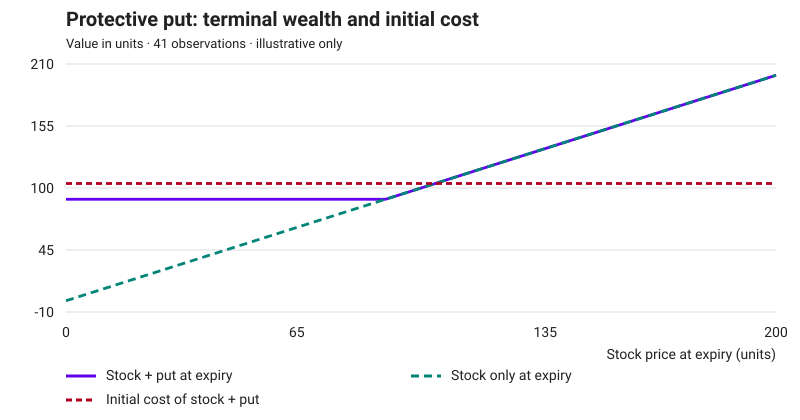

This is a payoff diagram across terminal prices, not a time-series path.


In [4]:
# Change these assumptions, then run this cell again.
spot, strike, premium, terminal = 100, 90, 4, 80
put_result = protective_put(spot=spot, strike=strike, premium=premium, terminal=terminal)
if premium < max(strike-spot, 0):
    print("This assumed premium violates the zero-interest no-arbitrage lower bound.")
    print("Read the result only as arithmetic for that hypothetical input, not a tradable price.")
for key, label in [("putPayoff", "Put payoff"), ("terminalWealth", "Terminal wealth"),
                   ("initialCost", "Initial cost"), ("profit", "Profit / loss"), ("returnPct", "Return (%)")]:
    print(f"{label:<20}: {put_result[key]:.6f}")
put_rows = []
for price in range(0, 201, 5):
    item = protective_put(spot=spot, strike=strike, premium=premium, terminal=price)
    put_rows.append(dict(price=price, wealth=item["terminalWealth"], cost=item["initialCost"], stock=price))
show_svg(chart_svg(put_rows, [("wealth", "Stock + put at expiry", "#6200EE", ""),
                            ("stock", "Stock only at expiry", "#008577", "8 5"),
                            ("cost", "Initial cost of stock + put", "#B00020", "6 4")],
                   x_key="price", title="Protective put: terminal wealth and initial cost",
                   x_label="Stock price at expiry (units)"))
print("This is a payoff diagram across terminal prices, not a time-series path.")

เครื่องมือถือสัญญาจนหมดอายุ ใช้ดอกเบี้ย 0% และไม่คิดเงินปันผล ค่าซื้อขาย ภาษี หรือการผิดนัด ค่า Premium เป็นค่าที่ผู้เรียนกำหนด **ไม่ได้คำนวณราคายุติธรรมของ Option** กราฟแกนนอนเป็นราคาที่อาจเกิด ณ วันหมดอายุ ไม่ใช่เส้นทางราคาตามเวลา

การถือสินทรัพย์กับ Put เป็นรูปแบบหนึ่งของ **[Option Based Portfolio Insurance หรือ OBPI](../glossary.html#obpi)** ซึ่งต้นฉบับอธิบายไว้ในบท 2 [พิมพ์ น. 10–13 / PDF 37–40](#references)

<a id="option-budget"></a>

## 3. ถ้ามีงบเพียง 100 ต้องลดอะไรลง

ถึงตรงนี้มีเรื่องงบที่ต้องกลับมาจัดให้ตรงกัน ตัวอย่างก่อนจ่ายไป 104 แต่เราเริ่มบทด้วยเงินเพียง 100 ถ้าจะเทียบกับพอร์ตที่ลงทุนในสินทรัพย์เสี่ยงด้วยเงิน 100 หน่วย เราต้องรวมค่าป้องกันไว้ในงบเดียวกันให้ได้ก่อน

เราจัด OBPI เป็น **สินทรัพย์ปลอดความเสี่ยงบวก Call** ได้ โดยกันเงินส่วนแรกไว้ให้โตถึง Floor เมื่อครบกำหนด แล้วใช้เงินที่เหลือซื้อ Call พอร์ตจึงมีเงินรองรับเป้าหมาย และยังรับการขึ้นของสินทรัพย์เหนือราคาใช้สิทธิผ่าน Call ได้

ให้ $C_0$ เป็นราคา Call หนึ่งหน่วย และ $n$ เป็นจำนวนหน่วย Call ที่ซื้อได้ งบเริ่มต้นต้องสอดคล้องกับ

$$
V_0=F_Te^{-rT}+nC_0,
\qquad
n=\frac{V_0-F_Te^{-rT}}{C_0}.
$$

เมื่อ Call มีราคาใช้สิทธิ $K$ และครบกำหนดเดียวกับส่วนปลอดความเสี่ยง มูลค่าพอร์ตปลายทางคือ

$$
V_T=F_T+n\max(S_T-K,0).
$$

สูตรนี้ต้องมีงบเหลือไม่ติดลบและราคา Call มากกว่าศูนย์ หากต้องใช้เงินทั้งหมดกันไว้ให้ถึง Floor ก็จะไม่เหลืองบซื้อ Call การเพิ่มระดับป้องกันจึงลดเงินสำหรับรับโอกาสเติบโตเมื่อเงื่อนไขอื่นเท่าเดิม

### เชื่อมกับตัวอย่าง Put เดิม

ภายใต้สินทรัพย์ไม่มีเงินปันผล Option เป็น European ที่ราคาใช้สิทธิและวันหมดอายุเดียวกัน ดอกเบี้ย 0% และเงื่อนไขซื้อขายที่ไม่มีโอกาส Arbitrage ความสัมพันธ์ [Put–call parity](../glossary.html#put-call-parity) ให้

$$
C_0=S_0+P_0-K=100+4-90=14.
$$

### ทำไมหุ้นบวก Put จึงเชื่อมกับเงินปลอดความเสี่ยงบวก Call

เราสามารถเริ่มจากผลลัพธ์วันหมดอายุ โดยยังไม่ต้องเลือกแบบจำลองความผันผวน

$$
S_T+\max(K-S_T,0)=K+\max(S_T-K,0).
$$

ทางซ้ายคือสินทรัพย์หนึ่งหน่วยบวก Put ทางขวาคือเงินสด $K$ ณ วันหมดอายุบวก Call หนึ่งหน่วย

| สภาวะปลายทาง | สินทรัพย์ + Put | เงินสด $K$ + Call |
|---|---|---|
| $S_T<K$ | $S_T+(K-S_T)=K$ | $K+0=K$ |
| $S_T\ge K$ | $S_T+0=S_T$ | $K+(S_T-K)=S_T$ |

ทั้งสองพอร์ตจ่ายเท่ากันในทุกกรณี ภายใต้สมมติฐานไม่มี Arbitrage และไม่มีความต่างของกระแสเงินระหว่างทาง ต้นทุนวันนี้จึงต้องเท่ากันด้วย สำหรับสินทรัพย์ไม่มีเงินปันผลและดอกเบี้ยทบต้นต่อเนื่องที่คงที่ จะได้

$$
S_0+P_0=Ke^{-rT}+C_0.
$$

จุดที่ต้องคิดลดคือเงิน $K$ ซึ่งจะใช้ในอนาคต ส่วน $S_0$, $P_0$ และ $C_0$ เป็นราคาวันนี้อยู่แล้ว เมื่อ $r=0$ จึงเหลือสูตร $C_0=S_0+P_0-K$ ที่ใช้ในตัวอย่าง

ความเท่ากันนี้เป็นการจับคู่ **จำนวนหน่วยหนึ่งต่อหนึ่ง** ถ้าต้องการ Floor $F_T$ และซื้อ Call $n$ หน่วย โครงสร้างทั่วไป $F_T+n\max(S_T-K,0)$ ยังใช้งานได้ แต่จะเหมือนหุ้น $n$ หน่วยบวก Put $n$ หน่วยพอดีก็ต่อเมื่อส่วนเงินปลอดความเสี่ยงที่ครบกำหนดเท่ากับ $nK$ หากกันเงินมากกว่านั้นก็มีส่วนเงินปลอดความเสี่ยงเพิ่มเติมในพอร์ต

นี่เป็นราคาที่สอดคล้องกับ **Premium สมมติ 4** ในตัวอย่าง ไม่ใช่ราคาตลาดที่สืบค้นมา ถ้ามีงบ 100 และต้องการ Floor 90 ให้กันเงิน 90 แล้วซื้อ Call ได้ $10/14=5/7$ หน่วย โดยสมมติว่าซื้อเศษหน่วยได้

$$
V_T=90+\frac{5}{7}\max(S_T-90,0).
$$

ถ้าสินทรัพย์จบที่ 80 พอร์ตนี้เหลือ 90 ถ้าจบที่ 120 พอร์ตมีประมาณ 111.43 หน่วย ได้กำไรประมาณ 11.43 หน่วยจากเงินเริ่มต้น 100 การคุ้มครองยังเปิดรับขาขึ้น แต่การเข้าร่วมขาขึ้นมีขนาดตามจำนวน Call ที่ซื้อได้

### ใช้งบเท่ากันแล้ว การลดขนาดกับการรักษา Floor ให้ผลต่างกัน

วิธีหนึ่งที่จะลดต้นทุน 104 ให้เหลือ 100 คือซื้อหุ้นและ Put เพียง $100/104=25/26$ หน่วยทั้งคู่ แต่เมื่อลดจำนวนหน่วย พื้นปลายทางจะลดลงเหลือ

$$
\frac{25}{26}\times90\approx86.5385.
$$

วิธีนี้ใช้งบ 100 จริง แต่ไม่ได้รักษา Floor 90 ไว้ ถ้าต้องการทั้งงบเริ่มต้น 100 และ Floor 90 ตัวอย่างเงินปลอดความเสี่ยงบวก Call ก่อนหน้าจึงกันเงิน 90 แล้วใช้ 10 ซื้อ Call $5/7$ หน่วย ผลลัพธ์ทั้งสองแบบเทียบกันได้ดังนี้

| โครงสร้าง | เงินเริ่มต้น | เงินปลายทางถ้า $S_T=80$ | ถ้า $S_T=100$ | ถ้า $S_T=120$ |
|---|---:|---:|---:|---:|
| หุ้น 1 หน่วย + Put 1 หน่วย | 104 | 90.00 | 100.00 | 120.00 |
| หุ้นและ Put อย่างละ $25/26$ หน่วย | 100 | 86.54 | 96.15 | 115.38 |
| เงินปลอดความเสี่ยง 90 + Call $5/7$ หน่วย | 100 | 90.00 | 97.14 | 111.43 |

ตารางแสดงมูลค่าปลายทาง จึงต้องลบเงินเริ่มต้นของแต่ละแถวเองหากต้องการกำไร แถวแรกใช้เงินมากกว่าอีกสองแถว ส่วนแถวสุดท้ายป้องกันระดับสูงกว่าแถวกลาง แต่ร่วมรับการขึ้นน้อยกว่าเมื่อราคาจบที่ 120 การบอกว่าแบบใดได้มูลค่าปลายทางมากกว่า โดยไม่ระบุเงินต้นและ Floor จึงทำให้เปรียบเทียบผิดโจทย์ได้

สำหรับแถวสุดท้าย เมื่อ $S_T>K$ ราคาสินทรัพย์ที่เพิ่มขึ้นอีก 1 หน่วยทำให้มูลค่าพอร์ตเพิ่ม $5/7$ หน่วย นี่คือความชันของ Payoff หรือขนาดการมีส่วนร่วมกับการขึ้นในช่วงนั้น **ไม่ได้แปลว่าผลตอบแทนพอร์ตเท่ากับ $5/7$ ของผลตอบแทนหุ้นเสมอ** เพราะพอร์ตยังมีเงินปลอดความเสี่ยง 90 และ Payoff เริ่มทำงานจากราคาใช้สิทธิ 90

ที่ $S_T=100$ หุ้นมีผลตอบแทน 0% แต่พอร์ตงบ 100 นี้เหลือ 97.1429 จึงมีผลตอบแทนประมาณ −2.8571% ขณะที่จุดคุ้มทุนหาได้จาก

$$
90+\frac57(S_T-90)=100
\quad\Longrightarrow\quad S_T=104.
$$

ต้นทุนการป้องกันจึงปรากฏผ่านการจัดงบและขนาดการมีส่วนร่วม แม้โครงสร้างจะไม่ได้เขียนรายการจ่ายค่า Put แยกตรง ๆ แล้วก็ตาม

**ลองคำนวณ:** ถ้าราคา Call เปลี่ยนจาก 14 เป็น 20 โดยคงงบเริ่มต้น 100, $S_0=100$, $K=90$, Floor 90 และดอกเบี้ย 0% จะซื้อ Call ได้ $10/20=0.5$ หน่วย ถ้าสินทรัพย์จบที่ 120 มูลค่าปลายทางเป็น $90+0.5(120-90)=105$ หน่วย ในชุดราคานี้ Put–call parity กำหนดให้ราคา Put ต้องเป็น $20-100+90=10$ หน่วยด้วย จึงไม่ได้คง Premium ของ Put ไว้ที่ 4 เหมือนตัวอย่างก่อน ตัวอย่างนี้แยกให้เห็นผลของราคา Call ต่อจำนวนหน่วยที่ซื้อได้ ยังไม่ได้ระบุว่าสาเหตุทางตลาดใดทำให้ Option แพงขึ้น

วิทยานิพนธ์อภิปรายการรวมต้นทุน Option ไว้ในน้ำหนักพอร์ตเพื่อให้กลยุทธ์ใช้เงินภายในงบ และเงื่อนไขของโครงสร้างที่ใช้ในการจำลอง [พิมพ์ น. 13 และ 50–52 / PDF 40 และ 77–79](#references) ตัวอย่างเปรียบเทียบสามงบข้างต้นสร้างเพื่อการสอนจาก Payoff และ Put–call parity

### ซื้อ Option จริงกับสร้าง Option สังเคราะห์

เมื่อซื้อ Option เราถือสิทธิตามสัญญาโดยตรง แต่เรายังสร้างพอร์ตให้เลียนแบบผลของ Option ได้ด้วยการปรับสินทรัพย์เสี่ยงกับเงินปลอดความเสี่ยง วิธีหลังเรียกว่า **Synthetic option** ผลที่ได้จะขึ้นอยู่กับแบบจำลองที่ใช้และการปรับพอร์ตให้ตามทัน

การจำลองหลักในวิทยานิพนธ์ใช้ **Synthetic OBPI** เวลาอ่านผลจึงต้องจำไว้ว่าเป็นพอร์ตที่ปรับเพื่อเลียนแบบ Option การซื้อ Put จริงอาจให้ผลต่างออกไป โดยเฉพาะเมื่อราคาขยับเร็วหรือเราซื้อขายได้เพียงบางเวลา [โครงสร้าง OBPI: พิมพ์ น. 10–13 / PDF 37–40; วิธีจำลอง: พิมพ์ น. 50–52 / PDF 77–79](#references)

In [5]:
# Same strike and expiry, zero interest and dividends: stock + put = bond + call.
spot, strike, assumed_put_premium = 100, 90, 4
implied_call_premium = spot + assumed_put_premium - strike
print(f"Parity-implied Call premium={implied_call_premium:.2f}; full stock+put cost=104.00")
budget, floor = 100, 90
call_units = (budget-floor)/implied_call_premium
print(f"With budget {budget}, reserve {floor} and buy {call_units:.6f} Call units, not one whole Call.")
for terminal_price in [80, 90, 120]:
    call_payoff = max(terminal_price-strike, 0)
    same_quantity = strike + call_payoff
    protected_budget = floor + call_units*call_payoff
    close(same_quantity, protective_put(terminal=terminal_price)["terminalWealth"])
    print(f"S_T={terminal_price}: full-parity wealth={same_quantity:.2f}; fixed-budget wealth={protected_budget:.2f}")

# Match both the initial budget and the desired floor before comparing.
scaled_units = 100 / 104
expected_values = [
    (80, 90, 86.53846153846153, 90),
    (100, 100, 96.15384615384616, 97.14285714285714),
    (120, 120, 115.38461538461539, 111.42857142857143),
]
print("Terminal stock | full stock+put (cost 104) | scaled (cost 100) | fixed-floor OBPI (cost 100)")
for terminal_stock, full_expected, scaled_expected, obpi_expected in expected_values:
    full = max(terminal_stock, 90)
    scaled = scaled_units * full
    fixed_floor = 90 + (10/14) * max(terminal_stock-90, 0)
    close(full, full_expected); close(scaled, scaled_expected); close(fixed_floor, obpi_expected)
    print(f"{terminal_stock:>14} {full:>27.6f} {scaled:>19.6f} {fixed_floor:>27.6f}")
close(90 + (10/14)*(104-90), 100)
new_call_premium = 20
parity_put_premium = new_call_premium - 100 + 90
close(parity_put_premium, 10)
close(90 + (10/new_call_premium)*(120-90), 105)
print("Call premium 20 implies Put premium 10 at the same spot/strike/rate, not the former Put premium 4.")


Parity-implied Call premium=14.00; full stock+put cost=104.00
With budget 100, reserve 90 and buy 0.714286 Call units, not one whole Call.
S_T=80: full-parity wealth=90.00; fixed-budget wealth=90.00
S_T=90: full-parity wealth=90.00; fixed-budget wealth=90.00
S_T=120: full-parity wealth=120.00; fixed-budget wealth=111.43
Terminal stock | full stock+put (cost 104) | scaled (cost 100) | fixed-floor OBPI (cost 100)
            80                   90.000000           86.538462                   90.000000
           100                  100.000000           96.153846                   97.142857
           120                  120.000000          115.384615                  111.428571
Call premium 20 implies Put premium 10 at the same spot/strike/rate, not the former Put premium 4.


<a id="cppi-rule"></a>

## 4. CPPI ใช้ระยะห่างจาก Floor เป็นตัวกำหนดความเสี่ยง

คราวนี้ลองเริ่มจากเงินในพอร์ต: **เรายังมีส่วนเผื่อเหนือ Floor เท่าไร** CPPI ใช้ส่วนเผื่อนี้เป็นตัวตั้งในการเลือกเงินลงทุนเสี่ยง เราเรียกมันว่า [Cushion](../glossary.html#cushion) ซึ่งคำนวณได้จาก

$$
C_t=V_t-F_t.
$$

ขอแยกสัญลักษณ์ก่อนเดินต่อ: $C_t$ ในส่วนนี้คือ Cushion ส่วน $C_0$ ที่ใช้ในหัวข้อ OBPI ก่อนหน้าคือราคา Call ตั้งแต่ตรงนี้ไป เมื่อพูดถึง $C_t$ เราจะหมายถึง Cushion

กลยุทธ์ **[Constant Proportion Portfolio Insurance หรือ CPPI](../glossary.html#cppi)** กำหนดจำนวนเงินลงทุนในสินทรัพย์เสี่ยงจาก Cushion คูณด้วยค่าคงที่ $m$ ที่เรียกว่า [Multiplier](../glossary.html#multiplier)

$$
E_t=mC_t.
$$

$E_t$ คือจำนวนเงินเสี่ยง ไม่ใช่จำนวนหุ้นหรือสัดส่วนร้อยละ ส่วน $m$ ไม่มีหน่วย ตัวอย่างเช่น Cushion 10 และ $m=3$ ให้เงินลงทุนเสี่ยง 30 หน่วย ไม่ใช่ 300% ของพอร์ต

ในบทนี้ใช้รุ่น **ไม่กู้เงินและไม่ขายชอร์ต** จึงจำกัดเงินเสี่ยงไม่ให้ต่ำกว่าศูนย์หรือเกินมูลค่าพอร์ต

$$
E_t=\min\left(V_t,\max(0,mC_t)\right),
\qquad B_t=V_t-E_t.
$$

$B_t$ เป็นเงินในสินทรัพย์ปลอดความเสี่ยง เมื่อราคาหรือมูลค่าพอร์ตเปลี่ยน เราคำนวณ $C_t$ ใหม่ แล้วซื้อขายเพื่อให้ $E_t$ กลับมาตรงกฎ การทำเช่นนี้เรียกว่า [Rebalancing](../glossary.html#rebalancing) [กลไก CPPI: พิมพ์ น. 13–15 / PDF 40–42; กฎจำกัดเงินเสี่ยงในสมการ 4.27: พิมพ์ น. 52–53 / PDF 79–80](#references)

**Multiplier สูงไม่ได้สร้างการคุ้มครองมากขึ้น** แต่เปิดรับความเสี่ยงมากขึ้นจาก Cushion เท่ากัน ยิ่งลงทุนเสี่ยงมาก การเคลื่อนที่ของตลาดก็ยิ่งส่งผลต่อส่วนเผื่อได้มาก

### Floor 90 ไม่ได้แปลว่า CPPI ถือเงินปลอดความเสี่ยง 90

กลับมาที่ $V_t=100$, $F_t=90$, $C_t=10$ และ $m=3$ กฎให้ถือเงินเสี่ยง 30 กับเงินปลอดความเสี่ยง 70 เงินปลอดความเสี่ยงจึงต่ำกว่า Floor 20 หน่วย สิ่งที่ทำให้พอร์ตมีโอกาสรักษา Floor คือกฎลด Exposure เมื่อ Cushion หดลง ซึ่งต้องพึ่งการซื้อขายให้ทันเวลา

<a id="figure-cppi-anatomy"></a>



ภาพ 1 — ซ้ายแบ่งตามเป้าหมาย ขวาแบ่งตามสินทรัพย์ที่ถือจริง แท่งทั้งคู่สูงเท่ากันเพราะเป็นเงิน 100 ก้อนเดียวกัน เส้นประคือ Floor 90 ส่วน C คือ Cushion และ E, B คือเงินในสินทรัพย์เสี่ยงและปลอดความเสี่ยงตามลำดับ Cushion ไม่ใช่สินทรัพย์ก้อนที่สาม ภาพใช้หน่วยเงินสมมติ ดอกเบี้ย 0% ไม่มีต้นทุน ไม่กู้และไม่ขายชอร์ต

หากไม่มีข้อจำกัดทำงาน สมการ

$$
B_t=V_t-mC_t=(F_t+C_t)-mC_t=F_t-(m-1)C_t
$$

ทำให้เห็นโครงสร้างทันที เมื่อ $m=1$ จะได้ $B_t=F_t$ แต่เมื่อ $m>1$ และ Cushion เป็นบวก จะได้ $B_t<F_t$ ดังนั้น CPPI ที่ใช้ $m=3$ ไม่เหมือนโครงสร้างซึ่งซื้อสินทรัพย์ปลอดความเสี่ยงให้ครบ Floor แล้วนำเงินส่วนที่เหลือไปซื้อ Call

### Multiplier, จำนวนเงินเสี่ยง และน้ำหนักพอร์ตเป็นคนละค่า

น้ำหนักสินทรัพย์เสี่ยงคือ $w_t=E_t/V_t$ ภายใต้ $V_t>0$ จึงเขียนกฎที่มีข้อจำกัดได้เป็น

$$
w_t=\min\left(1,\max\left(0,m\left(1-\frac{F_t}{V_t}\right)\right)\right).
$$

พอร์ต 100 กับ Floor 90 มี Cushion เท่ากับ 10% ของพอร์ต เมื่อ $m=3$ จึงเสี่ยง 30% แต่ถ้าพอร์ตโตเป็น 120 และ Floor ยังเท่าเดิม Cushion เป็น 30 หรือ 25% ของพอร์ต กฎเดียวกันจึงให้เสี่ยง 75% นี่คือเหตุผลที่คำว่า Constant Proportion อ้างถึง **สัดส่วน Exposure ต่อ Cushion** ในส่วนที่ไม่ติดข้อจำกัด ไม่ใช่การคงน้ำหนักหุ้นไว้ที่ 30% ตลอดเวลา

| มูลค่าพอร์ต $V_t$ | Floor $F_t$ | Cushion | เป้าหมาย $3C_t$ | เงินเสี่ยงที่ใช้หลังจำกัด | น้ำหนักเสี่ยง |
|---|---:|---:|---:|---:|---:|
| 100 | 90 | 10 | 30 | 30 | 30% |
| 120 | 90 | 30 | 90 | 90 | 75% |
| 150 | 90 | 60 | 180 | 150 | 100% |
| 88 | 90 | −2 | −6 | 0 | 0% |

แถวที่พอร์ตมี 150 แสดงผลของเพดาน หากใช้สูตร $E_t=3C_t$ โดยไม่จำกัด จะลงทุนเสี่ยง 180 และมี $B_t=-30$ ซึ่งหมายถึงกู้เงิน 30 มาลงทุนเพิ่ม แต่เครื่องมือบทนี้จำกัดเงินเสี่ยงที่ 150 จึงไม่กู้เงิน การใช้ Multiplier มากกว่า 1 จึง **มีโอกาสนำไปสู่การกู้ในสูตรที่ไม่จำกัด** แต่ไม่ได้หมายความว่าทุกพอร์ตที่ตั้ง $m>1$ กู้เงินอยู่แล้ว

### ลำดับเวลา: ดูมูลค่าปัจจุบัน แล้วจัดพอร์ตให้รอบถัดไป

ให้ $t$ เป็นจุดหลังจัดพอร์ตเสร็จ, $R_{t+1}$ เป็นผลตอบแทนสินทรัพย์เสี่ยงที่จะเกิดในช่วงถัดไป และ $\Delta t$ เป็นความยาวของช่วงนั้นในหน่วยปี กำหนด $g=e^{r\Delta t}$ เป็นตัวคูณการเติบโตของเงินปลอดความเสี่ยง

1. ณ เวลา $t$ เรารู้ $V_t$ และ $F_t$ จึงคำนวณ $C_t$, $E_t$ และ $B_t$ ได้
2. ถือสินทรัพย์จำนวนเดิมผ่านช่วงถัดไป เงินเสี่ยงเปลี่ยนเป็น $E_t(1+R_{t+1})$ และเงินปลอดความเสี่ยงเปลี่ยนเป็น $B_tg$
3. เมื่อถึงเวลาถัดไปจึงสังเกตผลตอบแทนที่เกิดจริง แล้วรวมเงินก่อนซื้อขายได้เป็น

$$
V_{t+1}^{-}=E_t(1+R_{t+1})+B_tg.
$$

4. คำนวณ Floor และ Cushion ใหม่ จากนั้นหาเป้าหมาย $E_{t+1}$ ตามกฎ จำนวนเงินที่ต้องซื้อหรือขายคือ

$$
\Delta E_{t+1}=E_{t+1}-E_t(1+R_{t+1}).
$$

$\Delta E>0$ หมายถึงซื้อเพิ่มโดยนำเงินออกจากส่วนปลอดความเสี่ยง ส่วน $\Delta E<0$ หมายถึงขายแล้วนำเงินกลับเข้าไปในส่วนปลอดความเสี่ยง เราเทียบเป้าหมายกับ **มูลค่าของสินทรัพย์ที่ถืออยู่หลังราคาเปลี่ยน** ไม่ใช่เทียบกับ $E_t$ ที่ราคาเก่า

เครื่องหมายลบยกกำลังใน $V_{t+1}^{-}$ หมายถึง “ก่อนปรับพอร์ต” และใช้ $V_{t+1}^{+}$ สำหรับ “หลังปรับพอร์ต” ไม่ใช่เครื่องหมายว่ามูลค่าติดลบ เมื่อไม่มีต้นทุนหรือเงินเติมเข้าออก การสลับสินทรัพย์เพียงอย่างเดียวให้

$$
V_{t+1}^{+}=V_{t+1}^{-}.
$$

นี่คือความหมายของ **[Self-financing](../glossary.html#self-financing)** ในตัวอย่าง: เงินซื้อสินทรัพย์ด้านหนึ่งมาจากการลดอีกด้าน การปรับพอร์ตไม่สร้างผลกำไรขึ้นทันที และไม่เติมส่วนที่ขาดจาก Floor ให้อัตโนมัติ ถ้ารวมค่าซื้อขาย $k_{t+1}$ มูลค่าหลังซื้อขายจะลดลงเป็น $V_{t+1}^{-}-k_{t+1}$ ซึ่งต้องนำไปพิจารณาใน Cushion และกฎจัดสรรด้วย เครื่องมือปัจจุบันกำหนดต้นทุนส่วนนี้เป็นศูนย์

ตัวอย่างเวลาและสมการก่อน/หลังซื้อขายนี้เป็นการขยายจากกฎ CPPI และข้อจำกัด Exposure ในต้นฉบับ [พิมพ์ น. 13–15 และ 52–53 / PDF 40–42 และ 79–80](#references) โดยเปลี่ยนมาแสดงเป็นช่วงเพื่อให้ตรวจการใช้ข้อมูลและคำนวณตามได้

### อ่านเสริม: ทำไม CPPI จึงป้องกัน Floor ได้ในแบบจำลองอุดมคติ

หัวใจของ CPPI คือยิ่งเข้าใกล้ Floor ยิ่งลดจำนวนเงินที่ยังรับความเสี่ยง หาก **ราคาเคลื่อนที่ต่อเนื่องและปรับพอร์ตได้ต่อเนื่อง** กฎมีโอกาสลด Exposure ตลอดทางก่อน Cushion ข้ามศูนย์ นี่คือที่มาของคุณสมบัติป้องกันในทฤษฎี ต้นฉบับกล่าวถึงความต่างระหว่างกรณี Geometric Brownian diffusion กับตลาดที่มีการกระโดดของราคา [พิมพ์ น. 39 / PDF 66](#references)

สำหรับผู้อ่านที่คุ้นกับ Stochastic Calculus เราพิสูจน์ได้ภายใต้แบบจำลองที่ชัดเจน ให้สินทรัพย์เสี่ยงเป็น $dS_t/S_t=\mu\,dt+\sigma\,dW_t$ โดย $\mu$ เป็น Drift ต่อปี, $\sigma$ เป็นความผันผวนต่อรากปี และ $W_t$ เป็น Brownian motion สมมติ $r$, $\mu$, $\sigma$ และ $m$ คงที่ ไม่มีต้นทุนหรือเงินเติมเข้าออก ฝากและกู้ที่อัตรา $r$ เดียวกันได้ตามจำนวนที่สูตรต้องใช้ และกำหนด $E_t=mC_t$ โดยยังไม่ใส่เพดาน Exposure

สมการ Self-financing และ Floor ที่โตตามเงินปลอดความเสี่ยงให้

$$
dV_t=E_t\frac{dS_t}{S_t}+(V_t-E_t)r\,dt,
\qquad dF_t=rF_t\,dt.
$$

นำสองสมการมาลบกัน แล้วใช้ $C_t=V_t-F_t$ และ $E_t=mC_t$ จะได้

$$
\frac{dC_t}{C_t}=[r+m(\mu-r)]\,dt+m\sigma\,dW_t.
$$

เมื่อ $C_0>0$ คำตอบคือ

$$
C_t=C_0\exp\left(\left[r+m(\mu-r)-\frac12m^2\sigma^2\right]t+m\sigma W_t\right)>0.
$$

Exponential เป็นบวก จึงทำให้ $V_t=F_t+C_t$ อยู่เหนือ Floor ในช่วงเวลาจำกัดภายใต้แบบจำลองนี้ ส่วน $-\tfrac12m^2\sigma^2$ มาจาก Itô correction ในการแปลงเป็นลอการิทึม ไม่ใช่ค่าธรรมเนียม และคุณสมบัติที่ Cushion เป็นบวกไม่ได้แปลว่าผลตอบแทนพอร์ตจะเป็นบวก

สมการชุดนี้แสดงเหตุผลของการป้องกันใน **แบบจำลองต่อเนื่องที่ไม่จำกัด Exposure** ซึ่งอาจอนุญาตการกู้เงินเมื่อ $mC_t>V_t$ จึงไม่ใช่สูตรที่ใช้แทนห้องทดลองรายเดือนของบทนี้ เมื่อตรวจและซื้อขายเป็นรอบ พอร์ตต้องรับผลตอบแทนทั้งช่วงด้วยจำนวนหน่วยเดิมก่อนลด Exposure ได้ และเมื่อราคากระโดด สมมติฐานราคาต่อเนื่องก็ไม่ถืออีกต่อไป หัวข้อ Gap risk จึงต้องกลับไปตรวจเงินก่อนซื้อขายในแต่ละช่วง แทนการใช้คำตอบ Exponential นี้เป็นหลักประกัน

ส่วนพิสูจน์นี้เราเพิ่มเพื่อให้เห็นเหตุผลทางคณิตศาสตร์ที่อยู่เบื้องหลังคำอธิบายในต้นฉบับ จึงต้องอ่านแยกจากผลการทดลองของวิทยานิพนธ์และผลของห้องทดลองในหน้าเว็บ

In [6]:
# Optional continuous, unconstrained CPPI: not the capped monthly simulator.
def continuous_cushion(cushion0, rate, drift, sigma, multiplier, time, brownian_endpoint):
    growth = (rate + multiplier*(drift-rate) - 0.5*multiplier**2*sigma**2)*time
    return cushion0 * math.exp(growth + multiplier*sigma*brownian_endpoint)

print("Illustrative Brownian endpoints at t=1 (not sampled scenarios or probabilities):")
for endpoint in [-1, 0, 0.25, 1]:
    cushion = continuous_cushion(10, 0.05, 0.08, 0.20, 3, 1, endpoint)
    assert cushion > 0
    print(f"W_1={endpoint:>5}: C_1={cushion:.6f}")
close(continuous_cushion(10, 0.05, 0.08, 0.20, 3, 1, 0.25), 11.162780704588712)
# When m=1, the cushion is simply the initial risky holding's value.
close(continuous_cushion(10, 0.05, 0.08, 0.20, 1, 1, 0.25),
      10*math.exp((0.08-0.5*0.2**2) + 0.2*0.25))
print("This result assumes continuous trading/prices, no costs, and unconstrained exposure. It does not validate the discrete simulator's floor.")


Illustrative Brownian endpoints at t=1 (not sampled scenarios or probabilities):
W_1=   -1: C_1=5.272924
W_1=    0: C_1=9.607894
W_1= 0.25: C_1=11.162781
W_1=    1: C_1=17.506725
This result assumes continuous trading/prices, no costs, and unconstrained exposure. It does not validate the discrete simulator's floor.


<a id="cppi-example"></a>

## 5. คำนวณการปรับพอร์ตหนึ่งรอบด้วยตนเอง

กลับมาที่พอร์ตเริ่มต้น **100 หน่วย, Floor 90, $m=3$, ดอกเบี้ย 0%** สมมติไม่มีต้นทุนและถือสินทรัพย์เป็นเศษหน่วยได้ ที่จุดเริ่มต้นเรามี

$$
C_0=100-90=10,
\qquad E_0=3(10)=30,
\qquad B_0=100-30=70.
$$

ถ้าสินทรัพย์เสี่ยงลดลง 10% ก่อนรอบปรับพอร์ตครั้งถัดไป เงินเสี่ยง 30 จะเหลือ 27 ส่วนเงินปลอดความเสี่ยงยังอยู่ที่ 70 พอร์ตจึงมีมูลค่า

$$
V_1=30(1-0.10)+70=97.
$$

Cushion ใหม่เท่ากับ $97-90=7$ กฎต้องการเงินเสี่ยงเพียง $3(7)=21$ หน่วย แต่เรายังถืออยู่ 27 หน่วย จึงต้อง **ขายออก 6 หน่วย** แล้วไปเพิ่มเงินปลอดความเสี่ยง

| จุดคำนวณ | มูลค่าพอร์ต | Floor | Cushion | เงินเสี่ยง | เงินปลอดความเสี่ยง |
|---|---:|---:|---:|---:|---:|
| เริ่มต้น หลังจัดพอร์ต | 100 | 90 | 10 | 30 | 70 |
| หลังสินทรัพย์เสี่ยงลง 10% ก่อนปรับ | 97 | 90 | 7 | 27 | 70 |
| หลังปรับตามกฎ | 97 | 90 | 7 | 21 | 76 |

หลังซื้อขาย เงินรวมยังเป็น 97 เท่าเดิม เราเพียงย้ายเงินระหว่างสินทรัพย์ สิ่งที่เปลี่ยนคือรอบต่อไปจะมีเงิน 21 หน่วยรับผลจากสินทรัพย์เสี่ยง จากเดิมที่ถืออยู่ 27 หน่วย

<a id="figure-cppi-rebalance"></a>



ภาพ 2 — สีม่วงคือเงินเสี่ยง E สีเทาคือเงินปลอดความเสี่ยง B ความกว้างใช้สเกลเดียวกันทุกแถว หลังราคาลงพอร์ตเหลือ 97 และหลังขายก็ยังเป็น 97 แต่เงินที่รับความเสี่ยงรอบต่อไปลดจาก 27 เป็น 21 หน่วย ตัวอย่างสมมติ Floor 90, m = 3, ดอกเบี้ย 0% ไม่มีต้นทุน ไม่กู้และไม่ขายชอร์ต

ถ้าสินทรัพย์ขึ้น 10% จากจุดเริ่มต้นแทน มูลค่าพอร์ตจะเป็น $30(1.10)+70=103$ Cushion เท่ากับ 13 และกฎต้องการเงินเสี่ยง 39 หน่วย เทียบกับเงินเสี่ยงที่โตมาเป็น 33 จึง **ซื้อเพิ่ม 6 หน่วย**

### ต่ออีกสามรอบ เพื่อเห็นว่ากฎจำสิ่งที่เกิดขึ้นอย่างไร

ใช้ตัวอย่างขาลงเดิมเป็นรอบแรก แล้วให้สินทรัพย์เสี่ยงมีผลตอบแทนในรอบต่อไปเป็น +20%, −10% และ +10% ตามลำดับ ตารางนี้แสดง **สี่รอบแรกของพอร์ตที่ยังไม่ครบกำหนด** จึงมีการซื้อขายหลังรอบที่สี่ด้วย Floor คงที่ 90 ดอกเบี้ย 0% และ $m=3$ ตลอดทั้งตัวอย่าง

| รอบที่เพิ่งจบ | ผลตอบแทนสินทรัพย์ | เงินเสี่ยงก่อนปรับ | มูลค่าพอร์ต | Cushion | เป้าหมายเงินเสี่ยงใหม่ | ซื้อเพิ่ม (+) / ขาย (−) | เงินปลอดความเสี่ยงหลังปรับ |
|---|---:|---:|---:|---:|---:|---:|---:|
| เริ่มต้น | — | — | 100.000 | 10.000 | 30.000 | จัดพอร์ตเริ่มต้น | 70.000 |
| 1 | −10% | 27.000 | 97.000 | 7.000 | 21.000 | −6.000 | 76.000 |
| 2 | +20% | 25.200 | 101.200 | 11.200 | 33.600 | +8.400 | 67.600 |
| 3 | −10% | 30.240 | 97.840 | 7.840 | 23.520 | −6.720 | 74.320 |
| 4 | +10% | 25.872 | 100.192 | 10.192 | 30.576 | +4.704 | 69.616 |

ดูรอบที่สองอย่างละเอียด หลังจบรอบแรกเราถือเงินเสี่ยง 21 กับเงินปลอดความเสี่ยง 76 เมื่อสินทรัพย์ขึ้น 20% เงินเสี่ยงโตเป็น $21(1.20)=25.2$ พอร์ตรวมจึงเป็น $25.2+76=101.2$ ทำให้ Cushion เท่ากับ 11.2 และเป้าหมายใหม่เท่ากับ $3(11.2)=33.6$ ต้องซื้อเพิ่ม $33.6-25.2=8.4$ หน่วยเงินจากส่วนปลอดความเสี่ยง

ถ้าสินทรัพย์เริ่มราคา 100 ราคาหลังสองรอบเป็น $100(0.90)(1.20)=108$ หลังปรับพอร์ตรอบแรก เงินเสี่ยง 21 ที่ราคา 90 หมายถึงถือ $21/90\approx0.233333$ หน่วย เมื่อราคาขึ้นเป็น 108 จำนวนหน่วยยังเท่าเดิมจึงมีมูลค่า 25.2 การซื้อเพิ่ม 8.4 ทำให้มีจำนวนหน่วยใหม่ $33.6/108\approx0.311111$ หน่วย ตัวอย่างนี้แยก **จำนวนหน่วยที่ถือ** ออกจาก **มูลค่า Exposure** ซึ่งเปลี่ยนได้ทั้งเพราะราคาและการซื้อขาย

ยอดซื้อขายสะสมสี่รอบนี้เท่ากับ $6+8.4+6.72+4.704=25.824$ หน่วยเงิน โดยไม่นับการจัดพอร์ตครั้งแรก ตัวเลขนี้ไม่ได้แปลว่าจ่ายค่าธรรมเนียม 25.824 และไม่ได้แปลว่าเงินหายออกจากพอร์ตเท่าจำนวนนั้น แต่บอกขนาดรวมของการเปลี่ยนสินทรัพย์เสี่ยงทั้งฝั่งซื้อและขาย

### ราคาเริ่มต้นกับราคาสุดท้ายยังบอกผล CPPI ไม่ครบ

เปรียบเทียบสองเส้นทางที่สินทรัพย์เริ่ม 100 และจบ 100 เหมือนกันภายใต้ Floor 90, $m=3$ และดอกเบี้ย 0%

| เส้นทางสินทรัพย์ | สิ่งที่เกิดกับ CPPI | เงินปลายทาง |
|---|---|---:|
| 100 → 100 → 100 | สินทรัพย์ไม่เปลี่ยนราคา จึงไม่มีผลจากการปรับ Exposure | 100.0000 |
| 100 → 110 → 100 | หลังขึ้น 10% พอร์ตเป็น 103 และเพิ่ม Exposure เป็น 39; รอบถัดไปสินทรัพย์ลดลง $10/110\approx9.0909\%$ | 99.4545 |

ในเส้นทางที่สอง การคำนวณรอบสุดท้ายคือ $39(100/110)+64\approx99.4545$ แม้ราคาสินทรัพย์กลับมาที่เดิม พอร์ตไม่กลับมาที่ 100 เพราะกฎเพิ่มจำนวนเงินเสี่ยงหลังราคาขึ้นแล้วจึงรับการลดลงด้วย Exposure ที่สูงกว่าเดิม ตัวอย่างนี้เป็นผลจากการจัดสรรตามเส้นทาง แม้ยังไม่คิดค่าซื้อขาย และ Cushion ยังเป็นบวกจึงยังไม่ใช่ Cash lock

ข้อสรุปที่ใช้ได้คือ **ผลตอบแทนสะสมของสินทรัพย์อย่างเดียวไม่พอ** จะทราบผล CPPI ต้องรู้ผลตอบแทนระหว่างจุดปรับพอร์ตและกฎที่ใช้ด้วย อย่างไรก็ตาม ไม่ควรเหมารวมว่าการสลับลำดับชุดผลตอบแทนเดิมจะทำให้มูลค่าปลายทางต่างกันทุกครั้ง เพราะบางกรณีที่ Floor คงที่ ไม่มีข้อจำกัดทำงาน และ Cushion ไม่หมด สมการให้ผลปลายทางเหมือนกันได้

### ตรวจคำตอบโดยไม่ต้องเชื่อเครื่องมือ

ลองปิดตารางส่วนรอบที่สาม แล้วคำนวณด้วยลำดับต่อไปนี้: เงินเสี่ยงหลังราคาลง → มูลค่าพอร์ตรวม → Cushion → เป้าหมายเงินเสี่ยง → จำนวนเงินที่ต้องซื้อหรือขาย ถ้าคำตอบถูก จะได้พอร์ต 97.84, Exposure เป้าหมาย 23.52 และขาย 6.72 หน่วยเงิน ตรวจอีกครั้งว่าเงินเสี่ยงหลังปรับ 23.52 บวกเงินปลอดความเสี่ยง 74.32 เท่ากับพอร์ต 97.84 พอดี

### ทดลองเปลี่ยนทีละค่า

เครื่องมือนี้แสดงการจัดสรร ณ จุดเริ่มต้นจากพอร์ต 100 หน่วยและดอกเบี้ย 0% ค่าเริ่มต้นคือ Floor 90% และ $m=3$ ลองคง Multiplier ไว้แล้วเพิ่ม Floor จากนั้นคืน Floor เดิมและเพิ่ม Multiplier สังเกตว่าจำนวนเงินเสี่ยงเปลี่ยนด้วยเหตุผลใด

In [7]:
# Worked allocation: initial 100, floor 90, multiplier 3, zero interest.
initial, floor_pct, multiplier = 100, 90, 3
first = calculate_allocation(initial, floor_pct, multiplier)
monthly_return = -0.10
held_risky_after_return = first["exposure"] * (1+monthly_return)
next_value = held_risky_after_return + first["safe"]
second = allocate(next_value, initial*floor_pct/100, multiplier)
print(f"Initial: cushion={first['cushion']:.2f}; risky={first['exposure']:.2f}; safe={first['safe']:.2f}")
print(f"After a 10% risky-asset fall: wealth={next_value:.2f}; risky before trade={held_risky_after_return:.2f}")
print(f"New risky target={second['exposure']:.2f}; sell={held_risky_after_return-second['exposure']:.2f}; safe={second['safe']:.2f}")
close(next_value, 97); close(second["exposure"], 21)
print("No future return was used to choose the preceding month's allocation.")

Initial: cushion=10.00; risky=30.00; safe=70.00
After a 10% risky-asset fall: wealth=97.00; risky before trade=27.00
New risky target=21.00; sell=6.00; safe=76.00
No future return was used to choose the preceding month's allocation.


เครื่องมือใช้กฎจำกัดเงินเสี่ยงที่ 0–100% ของพอร์ต จึงอาจเห็นเงินเสี่ยงหยุดเพิ่มเมื่อถึงเพดาน แม้เพิ่ม Multiplier ต่อ การคำนวณนี้ยังเป็นภาพ ณ เวลาเดียว ไม่ได้แสดงว่าพอร์ตจะรักษา Floor ได้ตลอดเส้นทาง

### กรณี $m=1$ ช่วยให้เห็นโครงสร้าง

ถ้า $m=1$ เงินเสี่ยงเท่ากับ Cushion และเงินปลอดความเสี่ยงเท่ากับ Floor เมื่อดอกเบี้ยและ Floor สอดคล้องกัน ไม่มีต้นทุน และราคาสินทรัพย์เสี่ยงไม่ติดลบ โครงสร้างนี้เสมือนกันส่วนปลอดความเสี่ยงไว้แล้วลงทุนส่วนที่เหลือในสินทรัพย์เสี่ยง ต้นฉบับจัดกรณีนี้เป็นกลยุทธ์ง่ายหรือ Naïve strategy [พิมพ์ น. 15 / PDF 42](#references)

ลองตรวจ $m=1$ ด้วยตัวเลขเริ่มต้นเดียวกัน จะถือเงินเสี่ยง 10 กับเงินปลอดความเสี่ยง 90 ถ้าสินทรัพย์ลง 10% เงินเสี่ยงเหลือ 9 พอร์ตเป็น 99 และ Cushion ใหม่เป็น 9 เป้าหมาย $1\times9=9$ ตรงกับของที่ถืออยู่ จึงไม่ต้องขายเพิ่ม ถ้าต่อมาสินทรัพย์ขึ้น 20% เงินเสี่ยงโตเป็น 10.8 พอร์ตรวมเป็น 100.8 และ Cushion ก็เป็น 10.8 อีกครั้ง

เหตุผลที่ไม่ต้องปรับในกรณีนี้คือส่วนปลอดความเสี่ยงและ Floor เติบโตด้วยตัวคูณเดียวกัน ส่วนสินทรัพย์เสี่ยงที่ถืออยู่จึงเท่ากับ Cushion ใหม่โดยอัตโนมัติ ภายใต้สมมติฐานเดิม กรณี $m=1$ ช่วยให้เห็นความต่างระหว่างการกันเงินสำหรับ Floor จริง ๆ กับการใช้ $m>1$ ซึ่งอาศัยการปรับ Exposure ตามราคา

In [8]:
# Four rebalancing periods, all before maturity.
returns = [-0.10, 0.20, -0.10, 0.10]
value, floor, multiplier, turnover = 100, 90, 3, 0
positions = allocate(value, floor, multiplier)
expected = [
    (27, 97, 7, 21, -6, 76),
    (25.2, 101.2, 11.2, 33.6, 8.4, 67.6),
    (30.24, 97.84, 7.84, 23.52, -6.72, 74.32),
    (25.872, 100.192, 10.192, 30.576, 4.704, 69.616),
]
print("Period | held risky | wealth | cushion | new risky | trade | new safe")
for step, (asset_return, answer) in enumerate(zip(returns, expected), 1):
    held_risky = positions["exposure"]*(1+asset_return)
    value = held_risky + positions["safe"]
    positions = allocate(value, floor, multiplier)
    trade = positions["exposure"]-held_risky
    turnover += abs(trade)
    values = (held_risky, value, positions["cushion"], positions["exposure"], trade, positions["safe"])
    for actual, target in zip(values, answer):
        close(actual, target)
    close(positions["exposure"]+positions["safe"], value)
    print(step, " | ".join(f"{number:.3f}" for number in values))
close(turnover, 25.824)
print(f"Turnover excluding initial allocation={turnover:.3f} monetary units, not fees.")
# Cross-check the same four steps in the chapter's monthly simulator.
same_steps = simulate(returns=returns+[0]*8)
for row, answer in zip(same_steps["rows"][1:5], expected):
    close(row["cppi"], answer[1]); close(row["exposure"], answer[3])
flat_path = simulate(returns=[0]*12)
round_trip = simulate(returns=[0.10, -1/11]+[0]*10)
close(round_trip["rows"][2]["asset"], 100)
close(round_trip["rows"][2]["cppi"], 99.45454545454545)
close(flat_path["rows"][2]["cppi"], 100)
print("Stock ends at 100 in both paths; flat CPPI=100, round-trip CPPI=99.454545.")


Period | held risky | wealth | cushion | new risky | trade | new safe
1 27.000 | 97.000 | 7.000 | 21.000 | -6.000 | 76.000
2 25.200 | 101.200 | 11.200 | 33.600 | 8.400 | 67.600
3 30.240 | 97.840 | 7.840 | 23.520 | -6.720 | 74.320
4 25.872 | 100.192 | 10.192 | 30.576 | 4.704 | 69.616
Turnover excluding initial allocation=25.824 monetary units, not fees.
Stock ends at 100 in both paths; flat CPPI=100, round-trip CPPI=99.454545.


<a id="gap-risk"></a>

## 6. เมื่อราคาลงเร็วกว่าที่จะปรับพอร์ต

จากตัวอย่างก่อน CPPI ลดเงินเสี่ยงตาม Cushion ได้เมื่อเราลงมือซื้อขาย ระหว่างที่ยังไม่ได้ปรับพอร์ต เราต้องถือสินทรัพย์ชุดเดิมต่อไป หากราคาลงแรงในช่วงนั้น มูลค่าพอร์ตอาจผ่าน Floor ไปแล้วก่อนที่เราจะขายทัน

ใช้จุดเริ่มต้นเดิม: เงินเสี่ยง 30, เงินปลอดความเสี่ยง 70, Floor 90 หากสินทรัพย์เสี่ยง **กระโดดลง 40% ในช่วงที่ยังปรับพอร์ตไม่ได้** มูลค่าพอร์ตจะเหลือ

$$
V_1=30(1-0.40)+70=88.
$$

พอร์ตต่ำกว่า Floor 90 ไปแล้ว เมื่อคำนวณ Cushion จะได้ $88-90=-2$ กฎที่จำกัดเงินเสี่ยงไม่ให้ติดลบจึงตั้งเป้าเงินเสี่ยงเป็นศูนย์ การขายหลังจากนั้นไม่สามารถทำให้มูลค่า 88 ย้อนกลับเป็น 90 ได้

<a id="figure-cppi-gap"></a>



ภาพ 3 — เมื่อสินทรัพย์เสี่ยงลง 40% ก่อนปรับ เงินเสี่ยง 30 เหลือ 18 รวมกับส่วนปลอดความเสี่ยง 70 ได้เพียง 88 แท่งจึงสั้นกว่าเส้น Floor 90 แม้ขาย E ทั้งหมดก็ได้ B เพียง 88 การขายหยุดรับความเสี่ยงรอบต่อไป แต่ไม่ได้คืนเงินที่เสียไป ตัวอย่างสมมติ ดอกเบี้ย 0% ไม่มีต้นทุน ไม่กู้และไม่ขายชอร์ต

นี่คือ **[Gap risk](../glossary.html#gap-risk)** ความเสี่ยงที่การเคลื่อนที่ของราคาทำให้พอร์ตผ่านระดับป้องกันก่อนปรับได้ทัน ประเด็นนี้อภิปรายในวิทยานิพนธ์ รวมถึงความยากเมื่อความสัมพันธ์ของสินทรัพย์เปลี่ยนในช่วงตลาดตึงตัว [พิมพ์ น. 32–33 / PDF 59–60](#references)

### Multiplier เชื่อมกับความไวต่อการร่วงอย่างไร

สมมติยังไม่ติดเพดานเงินเสี่ยง $E_t=mC_t$, Cushion เป็นบวก, ดอกเบี้ย 0% และไม่มีต้นทุน ถ้าสินทรัพย์เสี่ยงลดลงเป็นสัดส่วน $d$ ในหนึ่งช่วง มูลค่าที่หายไปคือ $mC_td$ ดังนั้น Cushion ที่เหลือคือ

$$
C_{t+1}=C_t-mC_td=C_t(1-md).
$$

เมื่อ $d>1/m$ Cushion จะติดลบ สำหรับ $m=3$ จุดนี้อยู่ที่การลดลงมากกว่าประมาณ 33.33% ในช่วงเดียว สูตรนี้เป็นข้อสังเกตภายใต้เงื่อนไขที่เพิ่งระบุ ไม่ใช่เกณฑ์สากลของทุกผลิตภัณฑ์ เมื่อเงินเสี่ยงติดเพดานหรือ Floor เปลี่ยน ต้องกลับไปคำนวณจากเงินจริงอีกครั้ง

### แยก “แตะ Floor” ออกจาก “หลุด Floor”

ที่จุดเริ่มต้นเดิม เมื่อสินทรัพย์ลดลงพอดี $1/3$ เงินเสี่ยง 30 เหลือ 20 พอร์ตรวมเป็น $20+70=90$ และ Cushion เท่ากับศูนย์ พอร์ต **แตะ Floor** แต่ยังไม่ต่ำกว่า Floor กฎจะหยุดถือสินทรัพย์เสี่ยง ส่วนการลดลงมากกว่า $1/3$ ทำให้ Cushion เป็นลบและเกิดการหลุด Floor

| Multiplier | เงินเสี่ยงเริ่มต้น เมื่อพอร์ต 100 และ Floor 90 | การลดลงที่ใช้ Cushion หมด เมื่อไม่ติดเพดานและดอกเบี้ย 0% |
|---|---:|---:|
| 1 | 10 | 100% |
| 2 | 20 | 50% |
| 3 | 30 | 33.3333% |
| 5 | 50 | 20% |

ตารางเป็นการวัด **ขนาดผลตอบแทนในช่วงที่ยังปรับพอร์ตไม่ได้** ไม่ใช่ความน่าจะเป็นที่เหตุการณ์นั้นจะเกิด และไม่ใช่ขาดทุนสูงสุดต่อปีที่รับรองได้ ตลาดอาจขยับผ่านเกณฑ์ระหว่างวันหรือช่วงตลาดปิดได้ ขึ้นกับเวลาที่กลยุทธ์มีโอกาสซื้อขายจริง

### ถ้ามีดอกเบี้ย ต้องให้ Floor เดินไปพร้อมกับเวลา

ให้ $R$ เป็นผลตอบแทนสินทรัพย์เสี่ยงในหนึ่งช่วง, $g=e^{r\Delta t}$ เป็นตัวคูณเงินปลอดความเสี่ยง และ $R_f=g-1$ เป็นผลตอบแทนปลอดความเสี่ยงของ **ช่วงเดียวกัน** ถ้าเป้าหมายปลายทางไม่เปลี่ยน Floor ต้องเพิ่มจาก $F_t$ เป็น $F_{t+1}=gF_t$

เริ่มจากสมการมูลค่าพอร์ตจริงก่อนปรับครั้งใหม่

$$
\begin{aligned}
C_{t+1}
&=E_t(1+R)+B_tg-F_tg\\
&=gC_t+E_t[(1+R)-g].
\end{aligned}
$$

หาก Cushion เป็นบวกและยังใช้ $E_t=mC_t$ ได้โดยไม่ติดข้อจำกัด จะได้

$$
C_{t+1}=C_t\left[1+mR-(m-1)R_f\right].
$$

สำหรับ $m>0$ จึงหลุด Floor เมื่อ

$$
R<-\frac{1}{m}+\frac{m-1}{m}R_f.
$$

เมื่อ $R_f=0$ สูตรกลับมาเป็น $R<-1/m$ ตามเดิม ส่วนกรณี $m=3$ และดอกเบี้ยทบต้นต่อเนื่อง 6% ต่อปี ถ้าช่วงระหว่างการปรับยาวหนึ่งเดือน จะมี $R_f=e^{0.06/12}-1\approx0.00501252$ หรือ 0.501252% ต่อเดือน เกณฑ์จึงเป็น

$$
R<-\frac13+\frac23(0.00501252)
\approx-0.32999165.
$$

นั่นคือสินทรัพย์ลดลงมากกว่าประมาณ **32.9992% ในเดือนนั้น** ก็เพียงพอให้หลุด Floor ภายใต้เงื่อนไขนี้ ไม่ใช่ต้องรอให้ลดลงเกิน 33.3333% เหตุผลคือส่วนเงินปลอดความเสี่ยงที่ถือจริงน้อยกว่า Floor เมื่อ $m>1$ ดังนั้นการเติบโตของเงินปลอดความเสี่ยงจึงชดเชยการเพิ่มขึ้นของ Floor ได้ไม่ครบทุกหน่วย

ตรวจด้วยตัวเลขของช่วงเดียว: สมมติ ณ จุดที่กำลังวัดมี $V_t=100$, $F_t=90$, $E_t=30$ และ $B_t=70$ ถ้าราคาสินทรัพย์ลดลง 33% พอร์ตปลายช่วงเป็น $30(0.67)+70e^{0.005}\approx90.450876$ ขณะที่ Floor ใหม่เป็น $90e^{0.005}\approx90.451127$ จึงหลุด Floor เล็กน้อยประมาณ 0.000250 หน่วย ตัวอย่างนี้กำหนด **Floor ณ จุดเริ่มของช่วงเป็น 90** เพื่อดูเกณฑ์หนึ่งช่วง ไม่ได้ใช้ 90 เป็น Floor ปลายปีของตัวอย่างดอกเบี้ย 5% ในหัวข้อ 1

### เมื่อ Exposure ติดเพดาน ต้องใช้ Exposure ที่ถือจริง

สูตรทั่วไปก่อนหน้ายังใช้ได้แม้เป้าหมาย $mC_t$ ถูกจำกัด แต่แทน $E_t$ ด้วยจำนวนเงินเสี่ยงที่ถือจริง สำหรับ $C_t>0$ และ $E_t>0$ เกณฑ์หนึ่งช่วงเป็น

$$
R<g-1-g\frac{C_t}{E_t}.
$$

เมื่อดอกเบี้ยเป็นศูนย์ เกณฑ์ลดรูปเป็น $R<-C_t/E_t$ ตัวอย่างพอร์ต 100, Floor 50 และ $m=3$ มี Cushion 50 สูตรที่ยังไม่จำกัดอยากลงทุนเสี่ยง 150 แต่เครื่องมืออนุญาตเพียง 100 จึงต้องใช้ $E_t=100$ เกณฑ์จริงของช่วงนั้นคือการลดลงเกิน $50/100=50\%$ ไม่ใช่ $1/3$ การอ่าน Multiplier โดยไม่ดูเพดานและจำนวนเงินที่ถืออยู่จึงทำให้ประเมิน Cushion ผิดได้

ถ้าไม่มีสินทรัพย์เสี่ยงเลย จะหารด้วย $E_t$ ไม่ได้ ต้องคำนวณการเติบโตของเงินปลอดความเสี่ยงเทียบกับ Floor โดยตรง และหาก Cushion ติดลบอยู่แล้ว ก็เป็นกรณีที่หลุด Floor ไปก่อนเริ่มช่วง ไม่ใช่การหาเกณฑ์ครั้งใหม่จาก Cushion บวก

สมการเกณฑ์ในส่วนนี้เป็นการอนุมานจากบัญชีมูลค่าพอร์ตของบทเรียน เพื่อขยายความหมายของ Gap risk ที่ต้นฉบับอภิปราย [พิมพ์ น. 32–33 / PDF 59–60](#references) ไม่ใช่สูตรรับรองผลิตภัณฑ์หรือค่าความน่าจะเป็นจากผลวิจัย

### Cash lock: ตลาดฟื้น แต่พอร์ตไม่ตาม

หาก Cushion หมดก่อนครบกำหนดจนกฎให้เงินเสี่ยงเป็นศูนย์ พอร์ตอาจอยู่ในสินทรัพย์ปลอดความเสี่ยงต่อไปโดยไม่มีส่วนร่วมกับการฟื้นตัว เรียกว่า **[Cash lock](../glossary.html#cash-lock)** ในตัวอย่างดอกเบี้ย 0% หลังพอร์ตลดเหลือ 88 แล้วขายสินทรัพย์เสี่ยงทั้งหมด แม้สินทรัพย์อ้างอิงขึ้นภายหลัง พอร์ตก็ยังอยู่ที่ 88 [แนวคิด Cash lock: พิมพ์ น. 14 / PDF 41](#references)

ไม่ใช่ทุกการลดความเสี่ยงจะกลายเป็น Cash lock หากยังมี Cushion บวกและยังถือสินทรัพย์เสี่ยง พอร์ตอาจกลับมาเพิ่มเงินเสี่ยงได้ การที่ Multiplier เป็นศูนย์ตั้งแต่ต้นก็เป็นการเลือกไม่รับความเสี่ยง ไม่ใช่ Cushion ถูกใช้จนหมด

### ตลาดต้องฟื้นเท่าไร และพอร์ตยังถือสิทธิร่วมฟื้นหรือไม่

สินทรัพย์ที่ลดจาก 100 เหลือ 60 ไม่ได้กลับมาที่ 100 เมื่อขึ้นอีก 40% เพราะ $60(1.40)=84$ ต้องขึ้น $100/60-1=66.6667\%$ จึงกลับมาที่เดิม แต่สำหรับ CPPI ที่ขายสินทรัพย์เสี่ยงหมดหลังพอร์ตเหลือ 88 แม้สินทรัพย์จะกลับจาก 60 ไป 100 ได้จริง พอร์ตก็ยังเป็น 88 ในตัวอย่างดอกเบี้ย 0% เพราะไม่มีจำนวนหน่วยของสินทรัพย์เสี่ยงเหลือให้รับการฟื้นตัว

ถ้าดอกเบี้ยเป็นบวก เงินปลอดความเสี่ยงอาจเพิ่มตามเวลา จึงไม่ควรอธิบาย Cash lock ว่ามูลค่าพอร์ตต้องหยุดนิ่งเสมอ ประเด็นคือ **Exposure เป็นศูนย์และกฎเดิมไม่สร้าง Cushion บวกกลับมาเอง** เมื่อ Floor ปลายทางคงเดิมและเงินปลอดความเสี่ยงกับ Floor โตด้วยตัวคูณ $g$ เดียวกัน จะได้

$$
E_t=0\quad\Longrightarrow\quad C_{t+1}=gC_t.
$$

หากเริ่มที่ $C_t=0$ จะยังเป็นศูนย์ หากเริ่มติดลบก็ยังติดลบ แม้มูลค่าพอร์ตเพิ่มขึ้นตามดอกเบี้ย การกลับไปเสี่ยงอีกครั้งจึงต้องเกิดจากเงื่อนไขที่ต่างจากกฎเดิม เช่น เงินเติมเข้าหรือการเปลี่ยน Floor ซึ่งจะเป็นอีกโจทย์หนึ่ง ไม่ใช่ผลการทำงานของ CPPI ชุดเดิม

### ปรับบ่อยขึ้นช่วยตรงไหน และไม่ได้แก้ตรงไหน

การมีโอกาสซื้อขายถี่ขึ้นทำให้กลยุทธ์ตรวจ Cushion และลด Exposure ได้ระหว่างทางมากขึ้น แต่ต้องแยกการเคลื่อนที่ที่ค่อย ๆ เกิดกับการกระโดดของราคา หากราคากระโดดข้ามช่วงที่ป้องกันได้ก่อนมีราคาซื้อขายครั้งถัดไป การตั้งรอบคำนวณถี่ขึ้นไม่ได้สร้างราคาที่ซื้อขายได้กลางการกระโดดนั้น

ในทางกลับกัน การซื้อขายบ่อยอาจเพิ่มค่าธรรมเนียม สเปรด และจำนวนการปรับพอร์ต ซึ่งตัวอย่างปัจจุบันยังไม่หักออกจากเงินลงทุน จึงไม่ควรใช้ผลจากแบบจำลองไร้ต้นทุนมาตัดสินว่ารอบที่ถี่ที่สุดดีที่สุดเสมอ การเลือกช่วงเวลาจึงเชื่อมทั้งกับขนาดการเคลื่อนไหวที่อาจเกิดก่อนซื้อขายได้ และต้นทุนที่ต้องจ่ายเมื่อซื้อขายจริง

ต้นฉบับใช้การปรับรายวันในส่วนการจำลองกลยุทธ์ [พิมพ์ น. 52–53 / PDF 79–80](#references) แต่เครื่องมือด้านล่างใช้รายเดือนเพื่อให้ไล่รายการคำนวณได้ ผลว่า Floor ไม่หลุดที่จุดรายเดือนจึงบอกเพียงว่า **ไม่พบการหลุด ณ จุดที่บันทึก** ไม่ได้บอกว่าระหว่างเดือนมูลค่าต่ำสุดอยู่เท่าไร

### ทดลองทั้งเส้นทาง ไม่ดูเพียงราคาเริ่มกับราคาจบ

เครื่องมือต่อไปใช้เส้นทางผลตอบแทนสมมติ 12 เดือน เริ่มด้วยพอร์ต 100, Floor 90%, $m=3$ และดอกเบี้ย 0% ลองดู “ร่วงฉับพลัน” เพื่อสังเกตการหลุด Floor แล้วเปลี่ยนเป็น “ลงก่อนแล้วฟื้น” เพื่อดูผลของการลดเงินเสี่ยงก่อนตลาดกลับขึ้น

Scenario=crash; terminal floor=90%; m=3; annual continuous rate=0.00%
CPPI final=87.411904; return=-12.588096%; max monthly drawdown=15.085004%
Floor breached=True; cash locked=True; rebalance turnover=29.173824 units


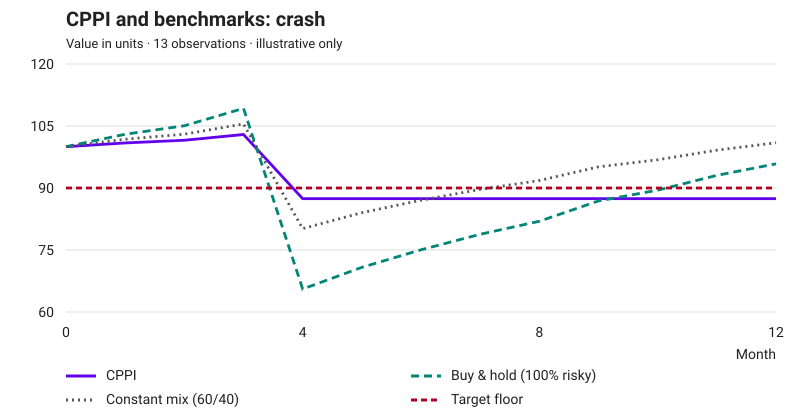

Month   CPPI      Buy/hold  Mix60/40  Floor     Risky target  Cushion
    0  100.0000  100.0000  100.0000   90.0000      30.0000   10.0000
    1  100.9000  103.0000  101.8000   90.0000      32.7000   10.9000
    2  101.5540  105.0600  103.0216   90.0000      34.6620   11.5540
    3  102.9405  109.2624  105.4941   90.0000      38.8214   12.9405
    4   87.4119   65.5574   80.1755   90.0000       0.0000   -2.5881
    5   87.4119   70.8020   84.0240   90.0000       0.0000   -2.5881
    6   87.4119   75.0502   87.0488   90.0000       0.0000   -2.5881
    7   87.4119   78.8027   89.6603   90.0000       0.0000   -2.5881
    8   87.4119   81.9548   91.8121   90.0000       0.0000   -2.5881
    9   87.4119   86.8721   95.1174   90.0000       0.0000   -2.5881
   10   87.4119   89.4782   96.8295   90.0000       0.0000   -2.5881
   11   87.4119   93.0573   99.1534   90.0000       0.0000   -2.5881
   12   87.4119   95.8491  100.9381   90.0000       0.0000   -2.5881
Month 12 exposure is a formula ta

In [9]:
# Editable controls: rally, crash, whipsaw, or recovery; initial wealth 100.
scenario, floor_pct, multiplier, rate = "crash", 90, 3, 0
result = simulate(scenario=scenario, floor_pct=floor_pct, multiplier=multiplier, rate=rate)
metrics = result["metrics"]
print(f"Scenario={scenario}; terminal floor={floor_pct}%; m={multiplier}; annual continuous rate={rate:.2%}")
print(f"CPPI final={metrics['final']:.6f}; return={metrics['returnPct']:.6f}%; max monthly drawdown={metrics['maxDrawdownPct']:.6f}%")
print(f"Floor breached={metrics['floorBreached']}; cash locked={metrics['locked']}; rebalance turnover={metrics['totalTurnover']:.6f} units")
show_svg(chart_svg(result["rows"], CPPI_SERIES, title=f"CPPI and benchmarks: {scenario}"))
print("Month   CPPI      Buy/hold  Mix60/40  Floor     Risky target  Cushion")
for row in result["rows"]:
    print(f"{row['month']:>5} {row['cppi']:>9.4f} {row['buyHold']:>9.4f} {row['constantMix']:>9.4f} {row['floor']:>9.4f} {row['exposure']:>12.4f} {row['cushion']:>9.4f}")
print("Month 12 exposure is a formula target only; no final trade enters turnover.")
csv_text = cppi_csv(result)  # Optionally save this string to a file of your choice.
print("\nSame parameters, four illustrative paths:")
for path in SCENARIOS:
    comparison = simulate(scenario=path, floor_pct=floor_pct, multiplier=multiplier, rate=rate)
    stats = comparison["metrics"]
    print(f"{path:<10} final={stats['final']:.5f}, breach={stats['floorBreached']}, cash lock={stats['locked']}")

**สมมติฐานของการทดลอง:** ปรับพอร์ตตอนเริ่มและหลังสิ้นเดือนที่ 1–11 โดยใช้เฉพาะข้อมูลที่เกิดขึ้นแล้ว ถือหน่วยลงทุนเป็นเศษส่วนได้ ไม่กู้และไม่ขายชอร์ต ไม่มีค่าธรรมเนียม ภาษี ส่วนต่างราคาซื้อขาย หรือความคลาดเคลื่อนจากราคาส่งคำสั่ง เงินปลอดความเสี่ยงให้ดอกเบี้ย 0% จึงทำให้ Floor ระหว่างทางคงที่ ผลที่แสดงเป็นจุดรายเดือน มูลค่าระหว่างเดือนอาจต่างออกไป

ตัวเปรียบเทียบหนึ่งคือถือสินทรัพย์เสี่ยง 100% ตลอดช่วง อีกตัวคือ **Constant Mix 60/40** ที่ปรับกลับเป็นสินทรัพย์เสี่ยง 60% กับปลอดความเสี่ยง 40% ทุกเดือน ทั้งคู่ใช้เงินตั้งต้น 100 เช่นกัน พอร์ต 60/40 นี้เป็นตัวเปรียบเทียบที่เพิ่มเพื่อการสอน **ต่างจากพอร์ต 50:50 แบบ Passive ในวิทยานิพนธ์** และเส้นทางทั้งสี่ไม่ใช่ผล Monte Carlo จากต้นฉบับ

ค่าซื้อขายสะสมหรือ Turnover นับจำนวนเงินที่ซื้อหรือขายฝั่งสินทรัพย์เสี่ยงในเดือนที่ 1–11 ไม่นับจัดพอร์ตครั้งแรก เป็นหน่วยเงิน ไม่ใช่ค่าธรรมเนียมหรืออัตราร้อยละ ส่วนการหลุด Floor และ Drawdown วัดที่จุดรายเดือน ผลว่าไม่หลุดในเส้นทางหนึ่งจึงยังไม่บอกว่าจะไม่หลุดในเส้นทางอื่น

In [10]:
# A one-period snapshot: F_now=90, not the preceding example's terminal floor.
rate, dt, value_now, floor_now, multiplier = 0.06, 1/12, 100, 90, 3
gross_safe = math.exp(rate*dt)
safe_return = gross_safe - 1
positions = allocate(value_now, floor_now, multiplier)
threshold = -1/multiplier + (multiplier-1)/multiplier*safe_return
close(threshold, -0.3299916527603993)
next_value = positions["exposure"]*(1-0.33) + positions["safe"]*gross_safe
next_floor = floor_now*gross_safe
close(next_value, 90.45087646015807)
close(next_floor, 90.45112687734608)
assert next_value < next_floor
print(f"Monthly gap threshold at 6% continuous annual rate: risky return < {threshold:.6%}")
print(f"After -33%: wealth={next_value:.9f}, floor={next_floor:.9f}, cushion={next_value-next_floor:.9f}")
# Use actual exposure when the cap binds.
capped = allocate(100, 50, 3)
close(capped["exposure"], 100)
capped_threshold = -capped["cushion"]/capped["exposure"]
close(capped_threshold, -0.5)
close(capped["exposure"]*(1+capped_threshold)+capped["safe"], 50)
print(f"With V=100/F=50/m=3/r=0, capped exposure=100 and floor-touch return={capped_threshold:.2%}.")
# Cash lock can grow in money while staying locked relative to the growing floor.
for initial_cushion in [0, -2]:
    assert gross_safe*initial_cushion <= 0


Monthly gap threshold at 6% continuous annual rate: risky return < -32.999165%
After -33%: wealth=90.450876460, floor=90.451126877, cushion=-0.000250417
With V=100/F=50/m=3/r=0, capped exposure=100 and floor-touch return=-50.00%.


<a id="tipp"></a>

## 7. TIPP เพิ่มคำถามว่า กำไรที่เกิดขึ้นควรปกป้องด้วยหรือไม่

ที่ผ่านมาเราใช้ CPPI ที่ตั้ง Floor ปลายทางจากเงินเริ่มต้น หากพอร์ตโตจาก 100 เป็น 120 แล้วลดลงมาเหลือ 95 พอร์ตก็ยังอยู่เหนือเป้าหมายเดิมที่ 90 แต่เงินหายไปจากจุดสูงสุดมากกว่า 20% แล้ว ถ้าเราอยากรักษากำไรที่เกิดขึ้นระหว่างทางด้วย เป้าหมายการป้องกันก็ต้องเปลี่ยนตาม

**[Time Invariant Portfolio Protection หรือ TIPP](../glossary.html#tipp)** ต่อยอดจาก CPPI โดยยก Floor ตามเงื่อนไขเมื่อพอร์ตเติบโต การยก Floor แบบไม่ลดกลับเรียกว่า **[Ratchet](../glossary.html#ratchet)** หลักการคือให้กำไรบางส่วนเข้ามาอยู่ในเป้าหมายป้องกัน [พิมพ์ น. 15–16 / PDF 42–43](#references)

### เขียนกฎให้ครบก่อนใส่ตัวเลข

เพื่อเห็นกลไก เราใช้ **ตัวอย่างการสอนที่ดอกเบี้ย 0%** สังเกตมูลค่าพอร์ตเป็นรอบ ไม่มีค่าซื้อขาย ไม่กู้และไม่ขายชอร์ต กำหนดให้ป้องกันสัดส่วน $\alpha=0.90$ ของมูลค่าสูงสุดที่เคยสังเกตได้ โดยไม่ลด Floor กลับ กฎนี้ใช้ประกอบการเรียน ไม่ใช่การทำซ้ำผล TIPP ในวิทยานิพนธ์

ให้ $H_t$ เป็น **[High-water mark](../glossary.html#high-water-mark)** หรือมูลค่าสูงสุดของพอร์ตจนถึงจุดสังเกต $t$ เริ่มจาก $H_0=V_0=100$ และ $F_0=90$ ในแต่ละรอบมีลำดับดังนี้

1. ปล่อยให้สินทรัพย์ที่ถืออยู่รับผลตอบแทนของรอบนั้น แล้วรวมเป็นมูลค่าพอร์ต $V_t$
2. บันทึกจุดสูงสุดใหม่ด้วย $H_t=\max(H_{t-1},V_t)$
3. ตั้ง Floor เป็น $F_t=\max(F_{t-1},\alpha H_t)$
4. คำนวณ Cushion และจัดเงินเสี่ยงจาก Floor ที่อัปเดตแล้ว

$$
C_t=V_t-F_t,\qquad
E_t=\min\left(V_t,\max(0,mC_t)\right),\qquad
B_t=V_t-E_t.
$$

ภายใต้จุดตั้งต้นและดอกเบี้ย 0% ของตัวอย่างนี้ $F_t=\alpha H_t$ อยู่แล้ว การเขียนค่าสูงสุดกับ Floor เดิมทำให้เห็นชัดว่าไม่ลดระดับป้องกันกลับ อย่าสับสน $H_t$ กับราคาสูงสุดของหุ้น: เราติดตาม **มูลค่าของพอร์ตที่ใช้กลยุทธ์นี้เอง** ซึ่งเปลี่ยนตามจำนวนสินทรัพย์ที่ถือ

ถ้าจะใช้อัตราดอกเบี้ยที่ไม่เป็นศูนย์หรือมีเป้าหมายปลายทางเฉพาะ ต้องกำหนดเพิ่มว่า Floor ที่ยกขึ้นเป็นมูลค่า ณ วันนี้หรือมูลค่าเมื่อครบกำหนด แล้วคิดการเติบโตของส่วนปลอดความเสี่ยงให้สอดคล้องกัน จึงไม่ควรนำกฎดอกเบี้ย 0% นี้ไปต่อกับ Floor แบบคิดลดโดยไม่ระบุวิธี

### มองพอร์ตที่มีมูลค่าเท่ากันก่อน

สมมติพอร์ตสองใบต่างมีมูลค่า 120 และพอร์ต TIPP เพิ่งทำจุดสูงสุดใหม่ ใช้ $m=3$ เท่ากัน

| สิ่งที่คำนวณ | CPPI ที่คง Floor 90 | TIPP ที่ Floor เท่ากับ 90% ของจุดสูงสุด |
|---|---:|---:|
| มูลค่าพอร์ต | 120 | 120 |
| Floor | 90 | 108 |
| Cushion | 30 | 12 |
| เงินเสี่ยงเป้าหมาย | 90 | 36 |
| เงินปลอดความเสี่ยง | 30 | 84 |

ทั้งสองพอร์ตมีเงินเท่ากัน แต่มีจำนวนเงินเสี่ยงต่างกันถึง 54 หน่วย เพราะ TIPP เพิ่มมูลค่าที่ต้องการปกป้อง การยก Floor เป็นการปรับเป้าหมายและย้ายเงินภายในพอร์ต **ไม่ได้สร้างมูลค่าพอร์ตเพิ่มอีก 18 หน่วย**

### เดินตามเส้นทางเดียวกันทีละรอบ

ตัวอย่างก่อนเปรียบเทียบ ณ มูลค่าเดียวกัน ส่วนตัวอย่างนี้เริ่มทั้งสองกลยุทธ์ที่ 100 จริง ๆ แล้วปล่อยให้ผลต่างสะสม เริ่ม Floor 90, $m=3$, เงินเสี่ยง 30 และเงินปลอดความเสี่ยง 70 ทั้งคู่ สินทรัพย์เสี่ยงขึ้น 20% ในรอบแรก แล้วลง 10% ในรอบที่สอง

| จุดสังเกต | CPPI: มูลค่าพอร์ต | CPPI: Floor / เงินเสี่ยงหลังปรับ | TIPP: มูลค่าพอร์ต | TIPP: Floor / เงินเสี่ยงหลังปรับ |
|---|---:|---:|---:|---:|
| เริ่มต้น | 100.00 | 90.00 / 30.00 | 100.00 | 90.00 / 30.00 |
| หลังสินทรัพย์ขึ้น 20% | 106.00 | 90.00 / 48.00 | 106.00 | 95.40 / 31.80 |
| หลังสินทรัพย์ลงอีก 10% | 101.20 | 90.00 / 33.60 | 102.82 | 95.40 / 22.26 |

รอบแรกทั้งคู่มีมูลค่า $30(1.20)+70=106$ เท่ากัน แต่หลังจัดพอร์ต CPPI ต้องการเงินเสี่ยง $3(106-90)=48$ ขณะที่ TIPP ยก Floor เป็น $0.9(106)=95.4$ จึงต้องการเงินเสี่ยงเพียง $3(106-95.4)=31.8$ ส่วนที่เหลือของ TIPP เท่ากับ 74.2

เมื่อตลาดลง 10% ในรอบถัดไป TIPP จึงเหลือ $31.8(0.90)+74.2=102.82$ ซึ่งมากกว่า CPPI ที่เหลือ $48(0.90)+58=101.20$ แต่จุดสูงสุดของ TIPP ยังเป็น 106 จึง **คง Floor ที่ 95.4** ไม่ลดตามมูลค่าที่ถอยลงมา

<a id="figure-tipp-ratchet"></a>



ภาพ 4 — สินทรัพย์เสี่ยงขึ้น 20% แล้วลง 10% ทำให้พอร์ต TIPP เป็น 100 → 106 → 102.82 จุดสูงสุดที่เคยสังเกตยังเป็น 106 จึงคง Floor ที่ 95.4 เส้นเชื่อมแสดงลำดับจุดสังเกต ไม่ใช่ราคาทุกขณะ ตัวอย่างการสอนใช้ m = 3, ดอกเบี้ย 0% ไม่มีต้นทุน ไม่กู้และไม่ขายชอร์ต การยก Floor ยังต้องอาศัยการซื้อขายให้ทัน

สิ่งนี้ไม่ได้แปลว่า TIPP จะจบด้วยเงินมากกว่าเสมอไป ถ้ารอบต่อมาสินทรัพย์ขึ้น 30% CPPI ที่ถือเงินเสี่ยง 33.6 จะมีมูลค่า $101.2+33.6(0.30)=111.28$ ส่วน TIPP ที่ถือเงินเสี่ยง 22.26 จะมีมูลค่า $102.82+22.26(0.30)=109.498$ การถือความเสี่ยงน้อยช่วยในรอบลง แต่ลดการเข้าร่วมรอบขึ้นด้วย

### ยก Floor แล้วรับประกัน Drawdown ได้หรือยัง

ถ้าเรารักษา $V_t\geq0.9H_t$ ได้ที่จุดสังเกตทุกจุด Drawdown ที่วัดจากจุดสังเกตชุดนั้นก็จะไม่เกิน 10% ตามนิยาม หากต้องการครอบคลุมทุกขณะ ต้องใช้ทั้งจุดสูงสุดและเงื่อนไขคุ้มครองตลอดเวลาด้วย แต่ **การตั้งกฎ Floor ให้เป็น 90% ของจุดสูงสุดไม่เท่ากับการทำเงื่อนไขนี้สำเร็จ** ราคาที่ข้ามเกณฑ์ ต้นทุน หรือการซื้อขายไม่ทัน ยังทำให้พอร์ตต่ำกว่า Floor ได้

เวลาอ่านกฎ TIPP เราจึงต้องตามให้ครบว่า ต้องการปกป้องเงินเท่าไร กฎให้ถือสินทรัพย์เท่าไร และเมื่อถึงเวลาซื้อขายจะทำตามนั้นได้หรือไม่ แม้ชื่อจะมีคำว่า Time Invariant ระยะเวลาลงทุน รอบสังเกต และรอบซื้อขายก็ยังมีผลต่อการป้องกัน

ห้องทดลอง 12 เดือนด้านบนจำลอง CPPI เท่านั้น ส่วนตัวอย่าง TIPP หลายรอบนี้มีให้คำนวณซ้ำใน Notebook แยกไว้ชัดเจน ก่อนอ่านผลใดให้ตรวจเสมอว่าใช้ Floor คงที่หรือ Ratchet และใช้จุดสูงสุดของพอร์ตใด

In [11]:
# The chapter's illustrative ratchet rule, not a replication of the thesis.
current_value, high_water_mark, protection_fraction, multiplier = 120, 120, 0.90, 3
fixed_floor = 90
ratchet_floor = protection_fraction*high_water_mark
tipp_allocation = allocate(current_value, ratchet_floor, multiplier)
cppi_allocation = allocate(current_value, fixed_floor, multiplier)
close(ratchet_floor, 108); close(tipp_allocation["exposure"], 36)
close(cppi_allocation["exposure"], 90)
print(f"At wealth 120: TIPP floor={ratchet_floor:.2f}, cushion={tipp_allocation['cushion']:.2f}, risky target={tipp_allocation['exposure']:.2f}")
print(f"Fixed-floor CPPI: floor={fixed_floor:.2f}, cushion={cppi_allocation['cushion']:.2f}, risky target={cppi_allocation['exposure']:.2f}")
print("A higher floor leaves less risky exposure; monthly rebalancing still leaves gap risk.")

# Matched initial wealth/exposure, then each portfolio follows its own rule.
cppi_value = tipp_value = high_water = 100
cppi_floor = tipp_floor = 90
cppi_pos = allocate(cppi_value, cppi_floor, 3)
tipp_pos = allocate(tipp_value, tipp_floor, 3)
expected = [(106, 106, 95.4, 48, 31.8), (101.2, 102.82, 95.4, 33.6, 22.26)]
print("Return | CPPI wealth | TIPP wealth | TIPP floor | CPPI risky | TIPP risky")
for asset_return, answers in zip([0.20, -0.10], expected):
    cppi_value = cppi_pos["exposure"]*(1+asset_return)+cppi_pos["safe"]
    tipp_value = tipp_pos["exposure"]*(1+asset_return)+tipp_pos["safe"]
    high_water = max(high_water, tipp_value)
    tipp_floor = max(tipp_floor, 0.90*high_water)
    cppi_pos = allocate(cppi_value, cppi_floor, 3)
    tipp_pos = allocate(tipp_value, tipp_floor, 3)
    actual = (cppi_value, tipp_value, tipp_floor, cppi_pos["exposure"], tipp_pos["exposure"])
    for result, target in zip(actual, answers):
        close(result, target)
    print(f"{asset_return:>6.0%} | " + " | ".join(f"{x:.3f}" for x in actual))
close(tipp_pos["safe"], 80.56)
cppi_recovery = cppi_value + cppi_pos["exposure"]*0.30
tipp_recovery = tipp_value + tipp_pos["exposure"]*0.30
close(cppi_recovery, 111.28); close(tipp_recovery, 109.498)
print(f"Next +30%: CPPI={cppi_recovery:.3f}, TIPP={tipp_recovery:.3f}.")
print("These are the chapter's illustrative ratchet rules; the website's 12-month lab remains CPPI only.")


At wealth 120: TIPP floor=108.00, cushion=12.00, risky target=36.00
Fixed-floor CPPI: floor=90.00, cushion=30.00, risky target=90.00
A higher floor leaves less risky exposure; monthly rebalancing still leaves gap risk.
Return | CPPI wealth | TIPP wealth | TIPP floor | CPPI risky | TIPP risky
   20% | 106.000 | 106.000 | 95.400 | 48.000 | 31.800
  -10% | 101.200 | 102.820 | 95.400 | 33.600 | 22.260
Next +30%: CPPI=111.280, TIPP=109.498.
These are the chapter's illustrative ratchet rules; the website's 12-month lab remains CPPI only.


<a id="strategies"></a>

## 8. วางสี่กลยุทธ์ข้างกัน แล้วดูว่าต่างกันตรงไหน

ยังมีวิธีง่ายอีกแบบคือ **Stop Loss Portfolio Insurance หรือ SLPI** เริ่มจากถือสินทรัพย์เสี่ยง แล้วขายไปถือสินทรัพย์ปลอดความเสี่ยงเมื่อมูลค่าลดถึงเกณฑ์ ในรุ่นที่วิทยานิพนธ์จำลอง เมื่อขายแล้วจะถือส่วนปลอดความเสี่ยงจนจบช่วงลงทุน จึงอาจพลาดการฟื้นตัว การขายที่เกณฑ์ก็อาจทำไม่ได้หากราคากระโดดผ่าน [พิมพ์ น. 9, 50 / PDF 36, 77](#references)

ถึงตรงนี้เราได้รู้จักวิธีป้องกันสี่แบบแล้ว ลองวางไว้ข้างกันเพื่อดูว่าแต่ละแบบรักษาเงินด้วยวิธีใด และแลกกับอะไรบ้าง

| กลยุทธ์ | กฎหรือสิทธิที่ใช้ | โอกาสเติบโตมาจาก | จุดที่ต้องระวัง |
|---|---|---|---|
| **SLPI** | ขายสินทรัพย์เสี่ยงเมื่อแตะเกณฑ์ | การถือสินทรัพย์เสี่ยงก่อนขาย | อาจขายต่ำกว่าเกณฑ์ และรุ่นไม่กลับเข้าตลาดอาจพลาดการฟื้นตัว |
| **OBPI** | ซื้อ Option หรือปรับพอร์ตเพื่อเลียนแบบ Option | สินทรัพย์เสี่ยงหรือจำนวน Call ที่งบซื้อได้ | ต้องรวมค่า Option ในงบ แยกสิทธิตามสัญญาจากความเสี่ยงการเลียนแบบ |
| **CPPI** | กำหนดเงินเสี่ยงจาก Multiplier × Cushion | เงินเสี่ยงที่เพิ่มเมื่อ Cushion โต | Gap risk, Cash lock และต้นทุนการปรับพอร์ต |
| **TIPP** | กฎแบบ CPPI พร้อมยก Floor | ส่วนเผื่อเหนือ Floor ที่ยกขึ้นแล้ว | ปกป้องกำไรเพิ่ม แต่พื้นที่รับขาขึ้นอาจลดลง และยังเสี่ยงจากการปรับไม่ทัน |

ตารางสรุปกลไกจากบท 2 ไม่ใช่อันดับผลตอบแทน [พิมพ์ น. 9–16 / PDF 36–43](#references) ก่อนบอกว่าแบบใดดีกว่า ต้องทำให้เงินเริ่มต้น ระยะเวลา เป้าหมายป้องกัน และต้นทุนที่รวมอยู่สอดคล้องกัน

### “ถือไว้” กับ “ปรับกลับสัดส่วน” ต่างกันแม้เริ่มพอร์ตเหมือนกัน

การจัดพอร์ต 60/40 ครั้งแรกยังบอกไม่ได้ว่าในอนาคตจะถืออะไร ต้องบอก **กฎหลังราคาเปลี่ยน** ด้วย ตัวอย่างเงิน 100 แบ่งสินทรัพย์เสี่ยง 60 กับเงินปลอดความเสี่ยง 40 ที่ดอกเบี้ย 0% หากสินทรัพย์เสี่ยงขึ้น 10% จะมีเงินเสี่ยง 66 เงินปลอดความเสี่ยง 40 รวม 106

ถ้าถือต่อแบบ Passive จะไม่ทำรายการใด น้ำหนักสินทรัพย์เสี่ยงกลายเป็น $66/106\approx62.26\%$ แต่ถ้าใช้ Constant Mix 60/40 ต้องตั้งเงินเสี่ยงใหม่ที่ $0.60(106)=63.6$ จึงขายออก 2.4 หน่วยและเพิ่มเงินปลอดความเสี่ยงเป็น 42.4

Constant Mix ในตัวอย่างนี้ขายสินทรัพย์เสี่ยงบางส่วนหลังราคาขึ้น เพื่อกลับไปสู่น้ำหนักเดิม ส่วน CPPI ที่มี $m>1$ และยังไม่ติดเพดานจะเพิ่มเงินเสี่ยงตาม Cushion ที่ขยายขึ้น ทั้งคู่ปรับพอร์ต แต่สิ่งที่แต่ละกฎพยายามรักษาทำให้ซื้อขายกันคนละทิศทาง

| วิธีดำเนินงาน | สิ่งที่พยายามรักษา | หลังตลาดขึ้นในตัวอย่างที่ยังไม่ติดข้อจำกัด |
|---|---|---|
| ถือพอร์ตเดิมแบบ Passive | จำนวนหน่วยสินทรัพย์ที่ถือ | ปล่อยน้ำหนักเสี่ยงเพิ่มตามราคา |
| Constant Mix | น้ำหนักสินทรัพย์เสี่ยงต่อมูลค่าพอร์ต | ขายบางส่วนเพื่อกลับสู่น้ำหนักเดิม |
| CPPI | เงินเสี่ยงต่อ Cushion | เพิ่มเงินเสี่ยงตาม Cushion ที่โต |

ในภาวะขึ้นลงสลับกัน Constant Mix กับ CPPI จึงตอบสนองต่างกัน ส่วนในภาวะที่ราคามีแนวโน้มต่อเนื่อง ผลก็อาจเปลี่ยนอีก ไม่มีกฎใดชนะทุกเส้นทางจากคำว่า “ปรับพอร์ต” เพียงอย่างเดียว และการอธิบายกลไกนี้ยังไม่ได้พิสูจน์ว่าเส้นทางแบบใดจะเกิดบ่อยในตลาดจริง

### Stop loss ต้องตอบด้วยว่าคำสั่งเกิดเมื่อไรและขายได้ราคาใด

สมมติเริ่มถือสินทรัพย์เสี่ยงด้วยเงิน 100 ตั้งเกณฑ์ขายที่ 90 แต่ครั้งถัดไปที่ซื้อขายได้สินทรัพย์มีมูลค่า 80 หากขายทั้งพอร์ตที่มูลค่า 80 เงินที่ได้ก็เป็น 80 ไม่ใช่ 90 ตามเกณฑ์ที่ตั้งไว้ และถ้ากฎกำหนดว่าไม่กลับเข้าตลาด เงินนี้จะไม่เพิ่มตามหุ้นที่ฟื้นเป็น 120 ภายหลังเมื่อดอกเบี้ยเป็นศูนย์

ตัวอย่างสมมตินี้แยก **สัญญาณให้ขาย** ออกจาก **ราคาที่ซื้อขายได้** กฎที่มีชื่อคล้ายกันอาจต่างกันอีกในเรื่องเวลาสังเกต การกลับเข้าตลาด และการใช้เงินปลอดความเสี่ยง จึงต้องอ่านรายละเอียดเหล่านี้ก่อนนำผล SLPI จากงานหนึ่งไปเทียบกับอีกงาน

### ต้นทุนการป้องกันมีทั้งเงินที่จ่ายและโอกาสที่เสียไป

ต้นทุนของ Put มองเห็นเป็น Premium ตั้งแต่เริ่ม ส่วนกลยุทธ์ที่ไม่ซื้อ Option ก็อาจมีค่าใช้จ่ายจากการซื้อขายซ้ำ สเปรด และราคาที่เปลี่ยนระหว่างส่งคำสั่ง นอกจากนี้ยังมีการพลาดขาขึ้นเมื่อกันเงินไว้มากหรือเกิด Cash lock ซึ่งไม่ปรากฏเป็นบิลค่าธรรมเนียม แต่มีผลต่อมูลค่าปลายทาง

ให้ $Q_t$ เป็นจำนวนเงินฝั่งสินทรัพย์เสี่ยงที่ซื้อหรือขายในรอบ $t$ โดยนับเป็นจำนวนบวก และ $\kappa$ เป็นอัตราค่าซื้อขายต่อจำนวนเงินนั้น แบบประมาณง่ายให้ต้นทุนเป็น $\kappa Q_t$ หากตลอดช่วงมี [Turnover](../glossary.html#turnover) รวม 60 หน่วย และใช้อัตราสมมติ 0.1% ต้นทุนตรงที่ประมาณได้คือ $0.001(60)=0.06$ หน่วย

ตัวเลขนี้ยังไม่ใช่การจำลองพอร์ตหลังต้นทุนอย่างสมบูรณ์ เพราะการหักเงินจริงในแต่ละรอบทำให้ $V_t$ และ Cushion ลดลง แล้วกระทบเงินเสี่ยงเป้าหมายในรอบต่อไปด้วย ในแบบจำลองที่รวมต้นทุนต้องแก้การจัดสรรและค่าใช้จ่ายให้สอดคล้องกัน ไม่ใช่เพียงหักยอดรวมจากผลปลายทางที่ไม่มีต้นทุน

### จากพอร์ตหนึ่งใบสู่ตลาดที่หลายคนใช้กฎคล้ายกัน

CPPI ในตัวอย่างขายหลังราคาลงและซื้อเพิ่มหลังราคาขึ้น หากผู้ใช้จำนวนมากต้องทำธุรกรรมทิศเดียวกันในตลาดที่สภาพคล่องต่ำ คำสั่งซื้อขายอาจทำได้ยากกว่าที่สูตรสมมติไว้ และผลกระทบต่อราคาอาจย้อนกลับมากระทบกฎป้องกันเอง

บท 3 ของวิทยานิพนธ์ทบทวนประเด็นการซื้อขายตามกฎกับเสถียรภาพตลาด ทั้งสภาพคล่อง ข้อมูลที่ไม่สมบูรณ์ และข้อจำกัดในการป้องกัน Gap risk ประเด็นนี้เตือนว่า “กฎเหมาะกับพอร์ตหนึ่งใบ” ยังไม่ครบสำหรับการประเมินผลเมื่อหลายพอร์ตทำพร้อมกัน งานส่วนนี้เป็นการทบทวนและอภิปราย ไม่ใช่ผลจากเครื่องมือ 12 เดือนในหน้านี้ [พิมพ์ น. 23–36 โดยเฉพาะ น. 32–33 / PDF 50–63, 59–60](#references)

In [12]:
# Passive and constant mix start from the same 60/40 allocation.
held_risky, safe = 60*1.1, 40
total = held_risky + safe
mix_target = 0.6*total
trade = mix_target-held_risky
close(total, 106); close(mix_target, 63.6); close(trade, -2.4)
print(f"Passive risky weight={held_risky/total:.6%}; constant mix sells {-trade:.2f} units.")
estimated_cost = 0.001*60
close(estimated_cost, 0.06)
print(f"60 units of turnover at a hypothetical 0.1% cost -> {estimated_cost:.2f} units of direct cost.")
print("A full cost model must deduct costs when trading and recompute the cushion/exposure, not merely subtract this at maturity.")


Passive risky weight=62.264151%; constant mix sells 2.40 units.
60 units of turnover at a hypothetical 0.1% cost -> 0.06 units of direct cost.
A full cost model must deduct costs when trading and recompute the cushion/exposure, not merely subtract this at maturity.


<a id="study-design"></a>

## 9. วิทยานิพนธ์ทดสอบกลยุทธ์เหล่านี้อย่างไร

ตัวอย่างหนึ่งเส้นทางทำให้เราเห็นว่า CPPI ซื้อขายเมื่อใดและ Floor หลุดได้อย่างไร แต่ยังตอบไม่ได้ว่าเหตุการณ์นั้นเกิดบ่อยเพียงใด หรือเมื่อพิจารณาผลลัพธ์หลายแบบ กลยุทธ์ใดให้สิ่งที่ผู้ลงทุนต้องการมากกว่า งานในบท 4–5 จึงเพิ่มอีกสองชั้น: **สร้างการกระจายของผลลัพธ์** และ **กำหนดเกณฑ์ให้คุณค่าแก่ผลลัพธ์เหล่านั้น**

### จากหนึ่งเส้นทางสู่การกระจายของความมั่งคั่ง

วิธี **Monte Carlo simulation** เริ่มจากกำหนดแบบจำลองตลาด สุ่มเส้นทางราคาหลายเส้น แล้วให้แต่ละกลยุทธ์ลงทุนและปรับพอร์ตตามกฎบนสถานการณ์เดียวกัน เมื่อครบกำหนด จะได้ความมั่งคั่งปลายทางหนึ่งค่าต่อเส้นทาง เช่น $W_T^{(1)},W_T^{(2)},\ldots,W_T^{(N)}$ เราจึงศึกษาได้ทั้งค่ากลาง การกระจาย และผลลัพธ์ด้านขาดทุน

ลำดับการทดลองมีความสำคัญ เพราะเราต้องใช้ข้อมูลที่มีอยู่ในเวลาตัดสินใจจริง

1. ตั้งเงินลงทุน Floor กฎปรับพอร์ต และพารามิเตอร์ตลาดให้ชัด
2. ให้กลยุทธ์เลือกเงินลงทุนเสี่ยงจากข้อมูลปัจจุบัน
3. สุ่มการเคลื่อนไหวของตลาดในช่วงถัดไป แล้วคำนวณมูลค่าของสิ่งที่ถือไว้
4. ปรับพอร์ตตามกฎ ทำซ้ำจนสิ้นปี และเก็บความมั่งคั่งปลายทาง
5. ทำให้ครบทุกเส้นทาง ก่อนนำผลลัพธ์มาคำนวณผลตอบแทนหรือคะแนนความชอบ

การเห็นราคาของวันถัดไปก่อนเลือกพอร์ตจะทำให้การทดลองได้เปรียบอย่างไม่สมจริง ส่วนการใช้เส้นทางตลาดชุดเดียวกันเพื่อเปรียบเทียบกลยุทธ์ช่วยแยกว่า ผลต่างเกิดจากกฎจัดพอร์ตหรือจากการที่แต่ละกลยุทธ์บังเอิญเจอตลาดคนละชุด

### GBM สมมติให้ราคาเคลื่อนอย่างไร

ราคาสินทรัพย์เสี่ยงในงานใช้ **[Geometric Brownian Motion หรือ GBM](../glossary.html#gbm)** ภายใต้พารามิเตอร์คงที่ หากเขียนเป็นสูตรที่ใช้เดินราคาทีละ time step จะได้

$$
S_{t+\Delta t}=S_t\exp\!\left[
\left(\mu-\frac{\sigma^2}{2}\right)\Delta t
+\sigma\sqrt{\Delta t}\,Z_t
\right],\qquad Z_t\sim N(0,1).
$$

$S_t$ คือราคาปัจจุบัน, $\mu$ คือพารามิเตอร์ Drift ต่อปี, $\sigma$ คือความผันผวนต่อปี และ $\Delta t$ วัดเป็นปี สำหรับข้อมูลรายวันในงาน $\Delta t=1/252$ ส่วน $Z_t$ เป็นตัวเลขสุ่มมาตรฐาน โดยค่าของแต่ละ time step เป็นอิสระกัน และสุ่มเส้นทางแต่ละเส้นอย่างอิสระเมื่อสร้างการทดลอง สูตรนี้เป็นการเขียนผลของสมการราคาและ Log return ในต้นฉบับให้อยู่ในรูปคำนวณทีละ step [พิมพ์ น. 48–49 / PDF 75–76](#references)

สังเกตว่าความผันผวนในหนึ่ง step คูณด้วย $\sqrt{\Delta t}$ ไม่ใช่ $\Delta t$ เช่น $\sigma=20\%$ ต่อปี ให้ส่วนเบี่ยงเบนมาตรฐานของ Log return รายวันประมาณ $20\%/\sqrt{252}=1.26\%$ ภายใต้สมมติฐานนี้ ส่วน $\mu=15\%$ เป็นพารามิเตอร์ของกระบวนการราคา ไม่ใช่คำรับรองว่าทุกเส้นทางจะให้ผลตอบแทน 15% หรือว่า Simple return คาดหมายหนึ่งปีต้องเท่ากับ 15% พอดี

เมื่อพารามิเตอร์คงที่ **Log return เป็น Normal และราคาปลายช่วงเป็น Lognormal** ราคาจึงเป็นบวก แบบจำลองพื้นฐานมีเส้นทางต่อเนื่องและไม่มี Price jump แต่การปรับพอร์ตเพียงวันละครั้งยังมีช่วงที่ไม่ได้ซื้อขาย การไม่มี Jump ในแบบจำลองจึงไม่ได้แปลว่าความเสี่ยงจากการปรับพอร์ตไม่ทันเป็นศูนย์

### อ่านชุดทดลองให้ครบก่อนอ่านผู้ชนะ

| องค์ประกอบการทดลอง | ที่ระบุในวิทยานิพนธ์ | เหตุผลที่ต้องทราบ |
|---|---|---|
| ระยะเวลา | 1 ปี, 252 วันซื้อขาย | จำกัดความหมายของผลไว้กับช่วงเวลานี้ |
| จำนวนเส้นทาง | 100,000 เส้นทางต่อสถานการณ์ | ช่วยสำรวจการกระจายภายใต้แบบจำลอง |
| สถานการณ์ | 9 คู่ของ $\mu=5\%,10\%,15\%$ และ $\sigma=10\%,20\%,30\%$ ต่อปี | เปลี่ยนผลตอบแทนที่ตั้งไว้และความผันผวนแยกกัน |
| อัตราปลอดความเสี่ยงฐาน | 5% ต่อปี | กำหนดต้นทุนของการกันเงินไว้ให้ถึง Floor |
| กลยุทธ์ป้องกัน | SLPI, Synthetic OBPI, CPPI $m=1$ และ $m=3$, TIPP | กฎป้องกันและการรับขาขึ้นต่างกัน |
| ตัวเปรียบเทียบ | สินทรัพย์เสี่ยง, เสี่ยง/ปลอดความเสี่ยง 50:50 แบบ Passive, สินทรัพย์ปลอดความเสี่ยง | ใช้เป็นทางเลือกที่กลยุทธ์ต้องแข่งขันด้วย |
| ข้อจำกัด CPPI | เงินลงทุนเสี่ยงอยู่ระหว่างศูนย์กับมูลค่าพอร์ต | $m=3$ ไม่ได้แปลว่าพอร์ตทั้งใบกู้เงินลงทุนสามเท่า |
| ต้นทุนที่ไม่รวม | ภาษี ส่วนต่างราคาซื้อขาย และค่าธรรมเนียมซื้อขาย | กลยุทธ์ที่ซื้อขายบ่อยอาจเปลี่ยนอันดับเมื่อเพิ่มต้นทุน |

ข้อมูลนี้มาจากพิมพ์ น. 48–53 และ 85–86 / PDF 75–80 และ 112–113 [ดูต้นฉบับ](#references) ค่าดังกล่าวเป็นชุดทดลอง ไม่ใช่ประมาณการตลาดปัจจุบัน ในชุดนี้ $\mu=5\%$ เท่ากับอัตราปลอดความเสี่ยงฐาน จึงเป็นกรณีไม่มีส่วนเพิ่มของพารามิเตอร์ผลตอบแทนเหนือสินทรัพย์ปลอดความเสี่ยง ไม่ใช่สมมติฐานว่าหุ้นต้องลดราคา และพอร์ต 50:50 ในงานก็ไม่ได้ปรับกลับเป็น 50:50 ทุกวัน

Floor หลักเท่ากับ 100% ของเงินเริ่มต้น จากนั้นงานเปลี่ยน Floor เป็น 80% เปลี่ยนพารามิเตอร์ CPT และเปลี่ยนอัตราปลอดความเสี่ยงเป็น 3.5% กับ 6.5% การทำเช่นนี้เรียกว่า **Sensitivity analysis**: เปลี่ยนเงื่อนไขสำคัญแล้วตรวจว่าข้อสรุปยังเหมือนเดิมหรือไม่ [พิมพ์ น. 91–98 / PDF 118–125](#references)

### จากผลจำลองไปสู่คะแนน มีอีกหนึ่งขั้นที่ห้ามสลับ

ถ้าต้องการเงินปลายทางเฉลี่ย เราคำนวณ $\frac{1}{N}\sum_j W_T^{(j)}$ แต่ถ้าต้องการ Expected utility ต้องนำ **เงินของแต่ละเส้นทางเข้า Utility ก่อน** แล้วจึงเฉลี่ย

$$
\widehat{\mathbb E[U(W_T)]}
=\frac{1}{N}\sum_{j=1}^{N}U\!\left(W_T^{(j)}\right).
$$

สูตรนี้โดยทั่วไปต่างจากการนำเงินเฉลี่ยเข้า $U$ เพียงครั้งเดียว เพราะ Utility อาจไม่เป็นเส้นตรง ความต่างนี้เองที่ทำให้พอร์ตซึ่งได้เงินเฉลี่ยสูงกว่าไม่ได้เป็นตัวเลือกอันดับหนึ่งสำหรับทุกความชอบ หัวข้อถัดไปจะคำนวณตัวอย่างให้เห็น

<a id="limitations"></a>

### สิ่งที่ผลวิจัยตอบได้ และสิ่งที่ต้องทดลองเพิ่ม

งานนี้ช่วยตอบว่า **เมื่อยอมรับแบบจำลองตลาด กฎลงทุน และความชอบที่กำหนด กลยุทธ์ใดมีคะแนนสูงกว่า** การเพิ่มจำนวนเส้นทางช่วยลด **[Sampling error](../glossary.html#sampling-error)** จากตัวอย่างสุ่มจำกัด แต่ไม่ขจัด **[Model risk](../glossary.html#model-risk)** จากการตั้งสมมติฐานผิด เช่น ความผันผวนคงที่ การไม่ใส่ต้นทุน หรือการใช้เกณฑ์ความชอบที่ไม่ตรงกับผู้ลงทุน

หากอยากขยายข้อสรุปจากหนึ่งปีไปสู่การออมหลายสิบปี ต้องศึกษาระยะเวลายาวขึ้นและเป้าหมายที่เปลี่ยนระหว่างทาง ผู้เขียนระบุความจำเป็นนี้สำหรับ CPPI/TIPP และเป้าหมายเกษียณไว้เอง [พิมพ์ น. 49 เชิงอรรถ 7 / PDF 76](#references) หากอยากใช้ผลกับการดำเนินการจริง ยังต้องทดสอบ Price jump ความล่าช้า สภาพคล่อง และต้นทุนซื้อขายเพิ่มเติม การที่ผลต่างมีนัยสำคัญในข้อมูลจำลองไม่ได้ตรวจสอบสมมติฐานเหล่านี้แทนเรา

ห้องทดลอง 12 เดือนในเว็บนี้ทำหน้าที่อีกแบบหนึ่ง: ใช้เส้นทางสมมติที่เขียนไว้ล่วงหน้า เพื่อให้เห็นกลไกและคำนวณตามได้ **ไม่ได้สุ่ม 100,000 เส้นทาง ไม่ได้ใช้ความน่าจะเป็นจากตลาด และไม่ได้ทำซ้ำตารางผลวิจัย** ตัวเปรียบเทียบ Constant Mix 60:40 ที่ปรับทุกเดือนของเว็บก็ต่างจาก Passive 50:50 ในวิทยานิพนธ์ด้วย

In [13]:
# One GBM time step at fixed illustrative shocks, not a Monte Carlo replication.
mu, sigma, dt, spot = 0.15, 0.20, 1/252, 100
daily_log_sd = sigma*math.sqrt(dt)
close(daily_log_sd, 0.01259881576697424)
print(f"Daily log-return standard deviation={daily_log_sd:.6%}")
for z in [-1, 0, 1]:
    next_spot = spot*math.exp((mu-0.5*sigma**2)*dt+sigma*math.sqrt(dt)*z)
    assert next_spot > 0
    print(f"Z={z:+}: next price={next_spot:.6f}")
print(f"Under this constant-parameter GBM, expected one-year simple return=exp(mu)-1={math.expm1(mu):.6%}, not exactly mu.")


Daily log-return standard deviation=1.259882%
Z=-1: next price=98.798976
Z=+0: next price=100.051601
Z=+1: next price=101.320106
Under this constant-parameter GBM, expected one-year simple return=exp(mu)-1=16.183424%, not exactly mu.


<a id="eut-cpt"></a>

## 10. เหตุใดกลยุทธ์ที่ไม่ได้ผลตอบแทนสูงสุดจึงยังน่าดึงดูด

เมื่อเห็นแล้วว่าแต่ละกลยุทธ์สร้างผลลัพธ์แบบใดได้บ้าง เรายังต้องถามต่อว่า **ผู้ลงทุนให้คุณค่ากับผลลัพธ์เหล่านั้นอย่างไร** เงินปลายทางจำนวนเดียวกันอาจมีความหมายต่างกันตามความชอบ ความมั่งคั่ง และสิ่งที่แต่ละคนถือว่าเป็นการขาดทุน วิทยานิพนธ์จึงนำการกระจายผลลัพธ์ที่จำลองได้มาประเมินผ่านทั้ง EUT และ CPT

### EUT: ความมั่งคั่งเท่ากันไม่ได้มีคุณค่าเพิ่มเท่ากันทุกช่วง

**Expected Utility Theory หรือ EUT** ใช้เกณฑ์ค่าสูงสุดของ [อรรถประโยชน์คาดหมาย](../glossary.html#expected-utility)

$$
\mathbb E[U(W_T)]=\sum_i p_iU(W_{T,i}).
$$

$W_{T,i}$ คือความมั่งคั่งปลายทางในผลลัพธ์ที่ $i$, $p_i$ คือโอกาสของผลลัพธ์นั้น และ $U$ เป็นฟังก์ชันบอกคุณค่าของความมั่งคั่ง โอกาสยังเป็นโอกาสเดิม แต่ผู้ลงทุนอาจให้คุณค่าแก่เงินเพิ่ม 10 หน่วยตอนมีเงินน้อย มากกว่าเงินเพิ่ม 10 หน่วยตอนมีเงินมาก

ถ้า $U$ เพิ่มขึ้นแต่โค้งเว้า หรือ **Concave** เงินที่เพิ่มเท่าเดิมจะให้ประโยชน์ได้เท่าเดิมหรือน้อยลงเมื่อเรามีความมั่งคั่งมากขึ้น นี่คือรูปแบบของ **[Risk aversion](../glossary.html#risk-aversion)** ใน EUT เมื่อต้องเลือกระหว่างทางเลือกเสี่ยงกับเงินแน่นอน **ที่มีค่าเท่ากันกับค่าเฉลี่ย** ของทางเลือกนั้น ผู้ลงทุนจะให้คุณค่ากับเงินแน่นอนไม่น้อยกว่า หาก Utility เป็น Strictly concave และผลลัพธ์ไม่ได้มีค่าเดียวแน่นอน ผู้ลงทุนจะให้คุณค่ากับเงินแน่นอนมากกว่า การเปรียบเทียบนี้ผูกอยู่กับเงินแน่นอนที่เท่ากับค่าเฉลี่ย จึงไม่ได้หมายความว่าผู้หลีกเลี่ยงความเสี่ยงต้องปฏิเสธสินทรัพย์เสี่ยงทุกชนิด

สำหรับ Utility แบบเว้า Jensen's inequality ให้

$$
\mathbb E[U(W_T)]\leq U\!\left(\mathbb E[W_T]\right).
$$

หาก $U$ เป็นเส้นตรง ผู้ลงทุนเป็นกลางต่อความเสี่ยงและจัดอันดับตามเงินคาดหมายได้ หาก $U$ โค้งนูนบนช่วงที่พิจารณา จะสะท้อนความชอบความเสี่ยงในความหมายนี้ [แนวคิดในพิมพ์ น. 44–47 / PDF 71–74](#references)

### ตัวอย่าง: เงินเฉลี่ย 110 อาจน่าดึงดูดน้อยกว่าเงินแน่นอน 100

ตัวอย่างต่อไปแต่งขึ้นเพื่อสอนการคำนวณ ทั้งสองทางเลือกใช้ต้นทุนเริ่มต้นเท่ากันและสิ้นสุดเวลาเดียวกัน ไม่ใช่ผลจำลองของวิทยานิพนธ์

| ทางเลือก | ความมั่งคั่งปลายทาง | เงินปลายทางคาดหมาย |
|---|---|---:|
| A | ได้ 100 แน่นอน | 100 |
| B | ได้ 50 หรือ 170 โดยมีโอกาสอย่างละ 50% | 110 |

ถ้าสนใจเงินคาดหมายอย่างเดียว B สูงกว่า 10 หน่วย แต่เมื่อใช้ $U(W)=\ln W$ จะได้

$$
\mathbb E[U(W_A)]=\ln100\approx4.6052,
$$

$$
\mathbb E[U(W_B)]
=\tfrac12\ln50+\tfrac12\ln170
\approx4.5239.
$$

ผู้ลงทุนตาม Utility นี้จึงเลือก A เหตุผลคือการเสียความมั่งคั่งไปถึง 50 มีผลต่อ Utility มากกว่าที่ค่าเฉลี่ยเงินเพียงตัวเดียวบอก คะแนน Utility เหล่านี้ใช้จัดอันดับภายใต้ฟังก์ชันเดียวกัน ไม่ใช่จำนวนเงิน ไม่ใช่เปอร์เซ็นต์ผลตอบแทน และไม่ควรนำคะแนนจาก Utility คนละรูปมาเทียบตรง ๆ

เราสามารถแปลงกลับเป็น **[Certainty equivalent](../glossary.html#certainty-equivalent)** หรือจำนวนเงินแน่นอนที่มี Utility เท่าทางเลือกเสี่ยง โดยแก้ $U(CE)=\mathbb E[U(W_B)]$ สำหรับ Log utility นี้

$$
CE=e^{\mathbb E[\ln W_B]}=\sqrt{50\times170}\approx92.20.
$$

จึงตีความได้ว่า ผู้ลงทุนตามแบบจำลองให้คุณค่ากับ B เท่าการรับ 92.20 แน่นอน ซึ่งต่ำกว่า 100 ของ A ส่วนต่าง $110-92.20=17.80$ เป็นค่าชดเชยความเสี่ยงในความหมายของ Certainty equivalent ไม่ใช่ค่า Option premium หรือการประมาณผลตอบแทนส่วนเกินของหุ้น

Log utility ใช้กับความมั่งคั่งบวก ตัวอย่างนี้จึงเลือกผลลัพธ์ที่มากกว่าศูนย์ทั้งหมด การนำฟังก์ชันไปใช้กับผลลัพธ์นอกขอบเขตของมันโดยตรงจะทำให้การจัดอันดับใช้ไม่ได้

### EUT ในงานวิจัยให้ข้อสรุปแค่ไหน

บท 5 ใช้ $U(W)=\ln W$, $U(W)=W$ และ $U(W)=W^2$ เป็นตัวแทนความหลีกเลี่ยง ความเป็นกลาง และความชอบความเสี่ยงตามลำดับบนช่วงความมั่งคั่งบวก ผลของตาราง 5.1 ไม่ได้แสดงว่า Portfolio Insurance เป็นตัวเลือกอันดับแรกโดยทั่วไป จึงยังอธิบายความนิยมของผลิตภัณฑ์ได้ไม่ดีภายใต้กรณีที่เลือก [พิมพ์ น. 86–89 / PDF 113–116](#references)

ต้องแยกข้อสรุปนี้ออกจากคำกล่าวว่า “EUT ใช้อธิบาย Portfolio Insurance ไม่ได้เลย” เพราะบท 4 ทดลอง Utility และระดับ Risk aversion หลายแบบ และพบว่าความผันผวน ผลตอบแทนที่ตั้งไว้ และระดับความหลีกเลี่ยงความเสี่ยงเปลี่ยนการเลือกกลยุทธ์ได้ [พิมพ์ น. 76–78 / PDF 103–105](#references) การตอบว่าผลิตภัณฑ์หนึ่งน่าดึงดูดจึงต้องระบุด้วยว่าน่าดึงดูดสำหรับความชอบแบบใด

### CPT: เริ่มจากจุดอ้างอิง ก่อนแยกกำไรออกจากขาดทุน

**[Cumulative Prospect Theory หรือ CPT](../glossary.html#cpt)** เปลี่ยนมุมมองมาให้คุณค่ากับผลลัพธ์เทียบ **[Reference point](../glossary.html#reference-point)** หรือจุดอ้างอิง แทนการมองระดับความมั่งคั่งอย่างเดียว ให้ $R$ เป็นจุดอ้างอิงและกำหนด

$$
x=W_T-R.
$$

งานใช้เงินเริ่มต้น 100 เป็นจุดอ้างอิง แม้ในกรณีลด Floor เหลือ 80 จุดอ้างอิงก็ยังเป็น 100 พอร์ตปลายทาง 90 จึงสำเร็จเมื่อวัดว่าอยู่เหนือ Floor แต่ยังมี $x=-10$ เมื่อวัดกำไรขาดทุนใน CPT **Floor เป็นเป้าหมายของกลยุทธ์ ส่วน Reference point เป็นฐานประเมินผลลัพธ์** ทั้งสองอาจตรงกันหรือแตกต่างกันได้ [พิมพ์ น. 84–85, 90, 95 / PDF 111–112, 117, 122](#references)

Value function ที่ใช้ในงานคือ

$$
v(x)=\begin{cases}
x^\alpha,&x\geq0,\\
-\lambda(-x)^\beta,&x<0.
\end{cases}
$$

$\alpha$ และ $\beta$ ควบคุมความไวต่อขนาดกำไรและขาดทุน ส่วน $\lambda$ ควบคุม **[Loss aversion](../glossary.html#loss-aversion)** หรือความไวต่อการสูญเสียเทียบกำไรขนาดเดียวกัน ค่าฐานคือ $\alpha=\beta=0.88$ และ $\lambda=2.25$ ตามวรรณกรรมที่งานอ้าง ไม่ใช่ค่าที่ประมาณจากผู้ใช้เว็บรายใด [พิมพ์ น. 84 / PDF 111](#references)

เมื่อเลขชี้กำลังต่ำกว่าหนึ่ง ความเปลี่ยนแปลงใกล้จุดอ้างอิงมีผลมากกว่าความเปลี่ยนแปลงขนาดเดียวกันที่ไกลออกไป และเมื่อ $\lambda>1$ ด้านขาดทุนจะชันกว่าอีกด้าน **Risk aversion กับ Loss aversion จึงคนละแนวคิด**: อย่างแรกเปรียบเทียบทางเลือกเสี่ยงกับเงินแน่นอน อย่างหลังเปรียบเทียบน้ำหนักของขาดทุนกับกำไรเทียบจุดอ้างอิง

### ตัวอย่าง: กำไร 10 กับขาดทุน 10 ไม่หักล้างกันใน Value function

สมมติลงทุนแล้วได้ $x=+10$ หรือ $x=-10$ อย่างละ 50% เงินเปลี่ยนแปลงคาดหมายเป็นศูนย์ แต่เมื่อใช้พารามิเตอร์ฐานข้างต้น

$$
v(10)=10^{0.88}\approx7.5858,
\qquad v(-10)=-2.25(10^{0.88})\approx-17.0680.
$$

ค่าเฉลี่ยของ Value function เท่ากับ

$$
0.5v(10)+0.5v(-10)\approx-4.7411.
$$

ตัวเลขติดลบแสดงว่า ภายใต้เกณฑ์นี้การได้รับกำไรและขาดทุนขนาดเท่ากันไม่ได้ชดเชยกันพอดี นี่เป็น **ตัวอย่างสมมติของค่าเฉลี่ย Value function** และยังไม่ใช่ CPT ครบรูปแบบ เพราะยังเหลือการคำนวณน้ำหนักการตัดสินใจ

### คำว่า Cumulative เพิ่มอะไรเข้ามา

นอกจากให้คุณค่ากับจำนวนเงินแล้ว CPT ยังใช้ **[Probability weighting](../glossary.html#probability-weighting)** เพื่ออธิบายว่าโอกาสเกิดเหตุการณ์กับน้ำหนักที่เราใช้ตัดสินใจอาจต่างกัน เช่น เหตุการณ์ที่มีโอกาสเกิดน้อยอาจมีผลต่อการเลือกมากกว่าที่โอกาสเกิดจริงบอก งานนี้ใช้ฟังก์ชัน

$$
w(p;\eta)=\frac{p^\eta}{\left[p^\eta+(1-p)^\eta\right]^{1/\eta}},
$$

โดยด้านกำไรใช้ $\eta=0.61$ และด้านขาดทุนใช้ $\eta=0.69$ จากนั้นเรียงผลลัพธ์และคำนวณ **ผลต่างของน้ำหนักความน่าจะเป็นสะสม** ไม่ใช่นำ $w(p_i)$ ไปคูณทุกผลลัพธ์อย่างอิสระ [พิมพ์ น. 83–84, สมการ 5.3–5.6 / PDF 110–111](#references)

ตัวอย่างที่มีแต่กำไรสองระดับช่วยให้เห็นขั้นตอนนี้ชัด: หากได้กำไร 10 ด้วยโอกาส 90% และกำไร 100 ด้วยโอกาส 10% น้ำหนักของผลลัพธ์สูงสุดคือ $w^+(0.1)\approx0.1863$ ส่วนน้ำหนักของกำไร 10 คือ $w^+(1)-w^+(0.1)\approx0.8137$ เพราะโอกาสได้กำไรอย่างน้อย 10 รวมแล้วเป็นหนึ่ง การสะสมจึงอาศัยทั้ง **อันดับและโอกาส** ของผลลัพธ์

สำหรับตัวอย่างกำไร/ขาดทุนอย่างละ 10 ที่มีเพียงหนึ่งผลลัพธ์ในแต่ละด้าน น้ำหนักจึงลดรูปเป็น $w^+(0.5)\approx0.4206$ และ $w^-(0.5)\approx0.4540$ ทำให้คะแนน CPT ประมาณ

$$
0.4206v(10)+0.4540v(-10)\approx-4.5578.
$$

ค่าขวามือคำนวณจากน้ำหนักก่อนปัดเศษ ทั้งคะแนนตัวอย่างนี้และคะแนนตารางวิจัยเป็นสเกลคุณค่าของแบบจำลอง **น้ำหนักการตัดสินใจไม่ใช่ความน่าจะเป็นตลาดที่แก้ใหม่** และในกรณีมีทั้งกำไรและขาดทุน ไม่จำเป็นต้องรวมกันได้หนึ่ง ตัวอย่างทั้งหมดในหัวข้อนี้เป็นตัวอย่างสอนใหม่ ไม่ใช่การทำซ้ำข้อมูลหรือผลประมาณของวิทยานิพนธ์

<a id="findings"></a>

### อ่านตาราง 5.2 ทีละชั้น เพื่อรู้ว่าอะไรทำให้อันดับเปลี่ยน

ตาราง 5.2 ใช้ Floor 100% และแยกเป็นสาม Panel โดยเปลี่ยนเกณฑ์ประเมินผลลัพธ์

| Panel | เกณฑ์ที่ใช้ | คำถามที่กำลังตรวจ |
|---|---|---|
| A | ค่าเฉลี่ย Value function โดย $\lambda=1$ | หากกำไรและขาดทุนสมมาตรกัน จะจัดอันดับอย่างไร |
| B | ค่าเฉลี่ย Value function โดย $\lambda=2.25$ | การให้น้ำหนักขาดทุนมากขึ้นเปลี่ยนอันดับหรือไม่ |
| C | CPT โดย $\lambda=2.25$ พร้อม Cumulative weighting | เมื่อเพิ่มน้ำหนักการตัดสินใจจากความน่าจะเป็นสะสม อันดับเปลี่ยนต่ออย่างไร |

Panel A/B ยังไม่ได้เพิ่ม Cumulative weighting จึงไม่ควรเรียกทั้งสาม Panel ว่าเป็นการคำนวณ CPT แบบเดียวกัน และการเทียบข้าม Panel คือการเปลี่ยนเกณฑ์ความชอบ ไม่ใช่การที่ผลตอบแทนของกลยุทธ์เพิ่มขึ้น

ตัวอย่างต่อไปคัดจาก **Panel C**

| สถานการณ์จำลอง | SLPI | CPPI $m=3$ | ถือสินทรัพย์เสี่ยง |
|---|---:|---:|---:|
| $\mu=15\%$, $\sigma=30\%$ ต่อปี | 17.04 | 11.61 | 6.96 |
| $\mu=15\%$, $\sigma=10\%$ ต่อปี | 15.50 | 6.58 | 15.83 |

**ตัวเลขเป็นคะแนน Cumulative prospect value ไม่ใช่ผลตอบแทนร้อยละหรือจำนวนเงิน** แถวแรก SLPI ได้คะแนนสูงกว่าทั้งสองทางเลือก เมื่อคงพารามิเตอร์ Drift ไว้และลดความผันผวนในแถวที่สอง การถือสินทรัพย์เสี่ยงกลับสูงกว่า SLPI การที่พารามิเตอร์ตลาดเปลี่ยนเพียงด้านเดียวแล้วอันดับเปลี่ยน ชี้ว่าคำว่า “กลยุทธ์ดีที่สุด” ต้องมีเงื่อนไขกำกับ

ในตารางฐานนี้ SLPI ได้คะแนนสูงสุด 8 จาก 9 สถานการณ์ ข้อยกเว้นคือ Drift สูงกับความผันผวนต่ำ [พิมพ์ น. 90–91 / PDF 117–118](#references) ดาวในต้นฉบับหมายถึงนัยสำคัญของ **Paired t-test** ซึ่งทดสอบว่าคะแนนของกลยุทธ์ป้องกันเท่ากับ Benchmark ที่มีคะแนนสูงสุดหรือไม่ ไม่ใช่ระดับความคุ้มครอง จำนวนดาวจึงใช้แทนขนาดผลต่างหรือความเหมาะสมไม่ได้

เมื่อลด Floor เป็น 80% อันดับเปลี่ยนและ CPPI มีบทบาทมากขึ้นในหลายสถานการณ์ ผู้เขียนจึงเสนอว่า CPT **อาจช่วยอธิบายความนิยม** ของ Portfolio Insurance แต่การเลือกกลยุทธ์ยังขึ้นกับเงื่อนไขตลาดและการออกแบบ อีกทั้งผู้เขียนระบุว่าควรศึกษาระยะเวลา ต้นทุน และภาษีเพิ่ม [พิมพ์ น. 95, 97–98 / PDF 122, 124–125](#references)

ข้อสรุปนี้เป็นคำอธิบายทางทฤษฎีว่าความคุ้มครองอาจมีคุณค่าอย่างไร ไม่ใช่หลักฐานว่าลูกค้าจริงทุกคนใช้พารามิเตอร์เหล่านี้ตัดสินใจหรือว่ากลยุทธ์คะแนนสูงจะให้ผลตอบแทนสูงสุด ความน่าดึงดูดในแบบจำลอง ผลการลงทุน และความสามารถรักษา Floor ในการดำเนินการจริงยังต้องตรวจแยกกัน

In [14]:
# New teaching examples, separate from the thesis tables.
utility_a = math.log(100)
utility_b = 0.5*math.log(50)+0.5*math.log(170)
certainty_equivalent = math.exp(utility_b)
close(utility_b, 4.523910721239204)
close(certainty_equivalent, 92.19544457292888)
assert (50+170)/2 > 100 and utility_b < utility_a
print(f"EUT: sure 100 utility={utility_a:.6f}; risky 50/170 utility={utility_b:.6f}; CE={certainty_equivalent:.6f}")

def prospect_value(change, alpha=0.88, beta=0.88, loss_aversion=2.25):
    return change**alpha if change >= 0 else -loss_aversion*(-change)**beta

def decision_weight(probability, eta):
    assert 0 <= probability <= 1 and eta > 0
    return probability**eta/(probability**eta+(1-probability)**eta)**(1/eta)

gain_value, loss_value = prospect_value(10), prospect_value(-10)
mean_value = (gain_value+loss_value)/2
gain_weight, loss_weight = decision_weight(0.5, 0.61), decision_weight(0.5, 0.69)
mixed_cpt = gain_weight*gain_value + loss_weight*loss_value
close(gain_value, 7.5857757502918375)
close(loss_value, -17.067995438156636)
close(mean_value, -4.741109843932399)
close(mixed_cpt, -4.557781610517452)
print(f"v(+10)={gain_value:.6f}; v(-10)={loss_value:.6f}; mean value={mean_value:.6f}")
print(f"Mixed CPT: gain weight={gain_weight:.6f}; loss weight={loss_weight:.6f}; score={mixed_cpt:.6f}")
high_gain_weight = decision_weight(0.10, 0.61)
low_gain_weight = decision_weight(1, 0.61)-high_gain_weight
close(high_gain_weight, 0.18630256637717418)
close(low_gain_weight, 0.8136974336228258)
close(low_gain_weight+high_gain_weight, 1)
print(f"Gains 10(p=.9)/100(p=.1): cumulative weights={low_gain_weight:.6f}/{high_gain_weight:.6f}.")
print("Weights are decision weights, not recalibrated market probabilities. Mixed gain/loss weights need not add to one.")


EUT: sure 100 utility=4.605170; risky 50/170 utility=4.523911; CE=92.195445
v(+10)=7.585776; v(-10)=-17.067995; mean value=-4.741110
Mixed CPT: gain weight=0.420639; loss weight=0.453988; score=-4.557782
Gains 10(p=.9)/100(p=.1): cumulative weights=0.813697/0.186303.
Weights are decision weights, not recalibrated market probabilities. Mixed gain/loss weights need not add to one.


<a id="robo-advisors"></a>

## 11. ถ้าให้แบบสอบถามเลือกพอร์ตแทนเรา จะวัดความเสี่ยงได้ครบหรือไม่

EUT และ CPT ทำให้เห็นว่าคำตอบว่า “อยากได้ผลตอบแทนสูงไหม” ยังช่วยเลือกพอร์ตได้ไม่มาก เราต้องรู้ด้วยว่าผู้ลงทุนให้คุณค่ากับความคุ้มครองเพียงใด ต้องใช้เงินเมื่อไร และมองอะไรเป็นการขาดทุน เมื่อรู้ความต้องการเหล่านี้แล้ว คำถามถัดมาคือ **แบบสอบถามแปลงความต้องการเหล่านั้นเป็นพอร์ตได้สอดคล้องกันเพียงใด** ซึ่งเป็นโจทย์ที่บท 6 ของวิทยานิพนธ์นำมาศึกษา

### คำว่า “รับความเสี่ยงได้” ซ่อนคำถามหลายแบบ

วิทยานิพนธ์จัดคำถามออกเป็นสี่ด้าน ได้แก่ ความคาดหวัง ความสามารถรับความเสี่ยง ความชอบความเสี่ยง และความตระหนักถึงความเสี่ยง [พิมพ์ น. 108–110 / PDF 135–137](#references) เพื่อให้เห็นความต่าง ลองแปลเป็นคำถามที่พอร์ตต้องตอบ ตัวอย่างในตารางนี้เป็นการเรียบเรียงเพื่อสอน ไม่ใช่แบบสอบถามหรือเครื่องมือให้คะแนนจากแพลตฟอร์มใด

| ด้านที่ต้องรู้ | ตัวอย่างคำถาม | ถ้าไม่รู้ จะพลาดอะไร |
|---|---|---|
| ความคาดหวัง | ต้องการเงินเท่าไร ภายในเมื่อไร | ไม่รู้ว่าพอร์ตต้องบรรลุเป้าหมายใด |
| ความสามารถรับความเสี่ยง | หากเงินลดลง ยังจ่ายภาระที่ครบกำหนดได้หรือไม่ | อาจวางเงินจำเป็นไว้ในสินทรัพย์ที่ต้องรอการฟื้นตัว |
| ความชอบความเสี่ยง | เมื่อพอร์ตลดลง ผู้ลงทุนยอมถือกฎเดิมต่อได้เพียงใด | กฎที่ดูดีในแบบจำลองอาจถูกยกเลิกกลางทาง |
| ความตระหนักถึงความเสี่ยง | เข้าใจหรือไม่ว่า Floor เป็นเป้าหมายของกฎหรือข้อผูกพันตามสัญญา | อาจคาดหวังความคุ้มครองที่ผลิตภัณฑ์ไม่ได้ให้ |

**[Risk capacity](../glossary.html#risk-capacity)** หรือความสามารถรับความเสี่ยง ต่างจาก **[Risk tolerance](../glossary.html#risk-tolerance)** หรือความเต็มใจยอมรับความเสี่ยง คนสองคนอาจตอบว่ายอมเห็นพอร์ตลดลง 20% เท่ากัน แต่คนแรกต้องใช้เงินนั้นจ่ายภาระในหกเดือน ส่วนคนที่สองมีเงินสำรองแยกไว้และยังไม่ต้องใช้เงินลงทุนอีกหลายปี ความจำเป็นทางการเงินของสองคนนี้ต่างกัน แม้ความรู้สึกต่อการแกว่งของราคาใกล้เคียงกัน

ความชอบรับความเสี่ยงมากก็ไม่ได้เพิ่มความสามารถจ่ายหนี้ และความต้องการผลตอบแทนสูงก็ไม่ได้ทำให้ตลาดสร้างผลตอบแทนนั้นให้ได้โดยอัตโนมัติ การแปลงคำตอบเป็นพอร์ตจึงต้องตรวจความสอดคล้องของหลายด้านร่วมกัน

### ผู้วิจัยเปรียบเทียบแพลตฟอร์มอย่างไร

งานเลือก **5 แพลตฟอร์ม** จากบริการที่เข้าถึงกระบวนการเปิดบัญชีและข้อมูลการประเมินความเสี่ยงได้ในช่วงจัดทำวิทยานิพนธ์ แล้วสร้างโปรไฟล์สมมติ Conservative, Moderate และ Aggressive เพื่อบันทึกพอร์ตที่แต่ละแห่งเสนอ การศึกษานี้จึงมีทั้งข้อจำกัดจากการเข้าถึงและการใช้บุคคลสมมติ ไม่ใช่การสุ่มผู้ลงทุนจริงจากประชากร [พิมพ์ น. 108–110 / PDF 135–137](#references)

จากนั้นผู้วิจัยดำเนินการเป็นลำดับ

1. อ่านคำถามและกำหนดคำตอบตามโปรไฟล์สมมติ
2. บันทึกสัดส่วนสินทรัพย์ที่แต่ละแพลตฟอร์มเสนอ
3. จับคู่สินทรัพย์กับ ETF หรือดัชนีที่มีข้อมูล หากระบุสินทรัพย์กว้าง ๆ หรือประวัติราคาไม่พอ ก็เลือกตัวแทนที่ใกล้เคียง
4. ใช้ประวัติราคาประมาณ 10 ปี สร้างผลตอบแทนรายเดือนตามน้ำหนักพอร์ต และสมมติให้นำเงินปันผลกับกระแสเงินสดระหว่างทางกลับไปลงทุน
5. ประเมินผลตอบแทน ความผันผวน และตัวชี้วัดด้านขาดทุน เพื่อดูว่าพอร์ตที่ได้มีลักษณะสอดคล้องกับโปรไฟล์เพียงใด

งานรายงานผลตอบแทนช่วงหนึ่งและห้าปี ความผันผวนหลายช่วงเวลา รวมถึงผลตอบแทนแย่ที่สุดในช่วงข้อมูล Historical VaR ที่ 5% และ 10% และ Sharpe ratio [พิมพ์ น. 111–113 / PDF 138–140](#references) Historical VaR ใช้ข้อมูลย้อนหลังหาขอบเขตในหางด้านขาดทุนของการกระจาย ยังมีผลลัพธ์ที่แย่กว่าขอบเขตนั้นได้ ส่วน Sharpe ratio เทียบผลตอบแทนส่วนเกินเหนืออัตราปลอดความเสี่ยงกับความผันผวน การอ่านจึงต้องดูความถี่และนิยามร่วมด้วย โดยเฉพาะผลตอบแทนช่วงแย่ที่สุดซึ่งไม่ใช่ตัวเดียวกับ Maximum drawdown และ VaR ซึ่งไม่ได้บอกขนาดการสูญเสียสูงสุด

### การใช้สินทรัพย์ตัวแทนทำให้ผลสะท้อนอะไร

หากแพลตฟอร์มบอกเพียง “หุ้นสหรัฐฯ” ผู้วิจัยต้องเลือกดัชนีหรือ ETF มาสร้างประวัติผลตอบแทน การเลือกนั้นช่วยให้คำนวณได้ แต่เพิ่มสมมติฐานเกี่ยวกับสิ่งที่แพลตฟอร์มจะลงทุนจริง ผลย้อนหลังที่คำนวณจึงเป็นผลของ **พอร์ตที่สร้างขึ้นเพื่อประเมิน** ไม่ใช่ผลดำเนินการจริงของบัญชีลูกค้าที่ซื้อขายตามแพลตฟอร์มมาตลอดสิบปี

ต้นฉบับยกกรณีใช้ SPY แทนช่วงข้อมูลที่ VOO ยังไม่มีประวัติราคา [พิมพ์ น. 111 เชิงอรรถ 4 / PDF 138](#references) แม้สินทรัพย์ตัวแทนอาจมีความเสี่ยงใกล้เคียงกัน รายละเอียดค่าธรรมเนียม การติดตามดัชนี และการดำเนินการจริงก็ไม่เหมือนกันทุกอย่าง การใช้ข้อมูลย้อนหลังยาวขึ้นจึงไม่ได้ลบความไม่แน่นอนจากการเลือกตัวแทนออกไป

### เหตุใดสมมติฐานเรื่อง Correlation จึงมีผลต่อคำตอบ

ในการแยกประเภทความเสี่ยง งานกำหนดตัวขับเคลื่อนความเสี่ยงหลักหนึ่งประเภทต่อดัชนีหรือ ETF และสมมติความสัมพันธ์ระหว่างประเภทความเสี่ยงเป็นศูนย์ ทั้งที่สินทรัพย์เดียวอาจมีทั้งความเสี่ยงหุ้น อัตราดอกเบี้ย เงินเฟ้อ หรืออัตราแลกเปลี่ยนพร้อมกันได้ [พิมพ์ น. 111–113 / PDF 138–140](#references)

ตัวอย่างสมมติต่อไปแสดงว่าทำไมสมมติฐานดังกล่าวมีความหมาย หากลงทุนสองสินทรัพย์น้ำหนักอย่างละครึ่ง แต่ละสินทรัพย์มีความผันผวน 20% ต่อปี ความผันผวนพอร์ตขึ้นกับ Correlation $\rho$

$$
\sigma_p^2=(0.5)^2(0.2)^2+(0.5)^2(0.2)^2
+2(0.5)(0.5)(0.2)(0.2)\rho.
$$

เมื่อ $\rho=0$ ความผันผวนพอร์ตประมาณ 14.14% แต่เมื่อ $\rho=1$ จะเท่ากับ 20% ตัวอย่างนี้เป็นสูตรพอร์ตสองสินทรัพย์เพื่ออธิบายผลของสมมติฐาน ไม่ใช่การทำซ้ำวิธีแยกความเสี่ยงของวิทยานิพนธ์ สำหรับน้ำหนักบวกทั้งสองตัวในตัวอย่างนี้ Correlation ที่สูงขึ้นทำให้ความผันผวนพอร์ตสูงขึ้น หากค่าจริงเป็นบวก การสมมติเป็นศูนย์จึงอาจประเมินความเสี่ยงต่ำไป แต่ถ้าค่าจริงเป็นลบ การสมมติเป็นศูนย์อาจประเมินสูงไปแทน

### ผลที่พบควรนำไปตั้งคำถามอะไรต่อ

ผู้วิจัยพบว่าพอร์ตจากโปรไฟล์ชื่อเดียวกันมีการจัดสรรและลักษณะ Risk–return ต่างกัน จึงตั้งข้อกังวลเรื่องความสอดคล้องระหว่างสิ่งที่ผู้ลงทุนต้องการกับพอร์ตที่ได้รับ [พิมพ์ น. 114–117, 120–121 / PDF 141–144, 147–148](#references) ข้อค้นพบนี้มีประโยชน์ในฐานะสัญญาณให้ตรวจวิธีประเมินความเสี่ยง แต่พอร์ตต่างกันเพียงอย่างเดียวยังไม่พิสูจน์ว่าพอร์ตใดไม่เหมาะสม เพราะนิยามโปรไฟล์ สมมติฐาน เป้าหมาย และข้อจำกัดของแต่ละบริการอาจต่างกัน

เราจึงควรอ่านงานนี้เป็น **กรณีศึกษาจากปี 2018** ที่เปิดให้ตรวจความเชื่อมโยงระหว่างคำตอบกับพอร์ต ไม่ใช่การจัดอันดับแพลตฟอร์มปัจจุบัน หรือหลักฐานว่า Robo-advisors ทุกแห่งมีปัญหาเดียวกัน งานไม่ได้สุ่มแบ่งลูกค้าไปใช้บริการต่างกันแล้ววัดผลเชิงสาเหตุ และการวิเคราะห์พอร์ตย้อนหลังย่อมตอบไม่ได้โดยตรงว่าเจ้าของพอร์ตจริงจะทำตามกฎต่อหรือยกเลิกเมื่อเจอขาดทุน

สำหรับ Portfolio Insurance จุดตรวจที่เชื่อมกลับมาจากบทนี้คือ: เป้าหมายใช้เงินและ Floor ตรงกันหรือไม่ ผู้ลงทุนเข้าใจ Gap risk และ Cash lock หรือไม่ และยอมแลกผลขาขึ้นกับรูปแบบความคุ้มครองนั้นได้เพียงใด การตอบเพียงว่า Conservative หรือ Aggressive ยังไม่ละเอียดพอที่จะกำหนด Floor, Multiplier และกฎปรับพอร์ตทั้งหมด

In [15]:
# Two-asset teaching illustration, not the thesis risk decomposition.
weight_a = weight_b = 0.5
sigma_a = sigma_b = 0.20
for correlation, expected_sigma in [(0, math.sqrt(0.02)), (1, 0.20)]:
    variance = weight_a**2*sigma_a**2 + weight_b**2*sigma_b**2
    variance += 2*weight_a*weight_b*sigma_a*sigma_b*correlation
    sigma_portfolio = math.sqrt(variance)
    close(sigma_portfolio, expected_sigma)
    print(f"Correlation={correlation}: portfolio annual volatility={sigma_portfolio:.6%}")


Correlation=0: portfolio annual volatility=14.142136%
Correlation=1: portfolio annual volatility=20.000000%


<a id="how-to-compare"></a>

## 12. ทบทวนสิ่งที่ต้องรู้ก่อนบอกว่าการป้องกันคุ้มค่า

เราเริ่มจากงบ 100 และความต้องการรักษาเงิน 90 แต่คำตอบเปลี่ยนไปตามวิธีดำเนินงาน การซื้อ Option มีต้นทุนชัดเจน ส่วนการปรับพอร์ตตามกฎมีความเสี่ยงที่ราคาเคลื่อนที่เร็วกว่ารอบซื้อขาย TIPP เพิ่มความคุ้มครองกำไรระหว่างทาง แต่ก็ลดส่วนเผื่อที่ใช้รับการเติบโตได้

เวลาประเมินผล ควรวางอย่างน้อยสี่ด้านไว้ข้างกัน

| สิ่งที่กำลังวัด | ช่วยตอบคำถามใด |
|---|---|
| ผลตอบแทนปลายทาง | เงินตั้งต้นเติบโตหรือลดลงเท่าไร |
| การหลุด Floor | ต่ำกว่าเป้าหมายหรือไม่ ต่ำกว่าเท่าไร และเกิดเมื่อใด |
| Maximum drawdown | ลดลงจากจุดสูงสุดก่อนหน้ามากเท่าไร |
| ต้นทุนและการซื้อขาย | ต้องแลกด้วยค่า Option ค่าซื้อขาย และการปรับพอร์ตมากเพียงใด |

### ความถี่ของการหลุด Floor กับขนาดความเสียหายเป็นคนละตัวเลข

ให้ $L_T=\max(F_T-V_T,0)$ เป็น **[Shortfall](../glossary.html#shortfall)** หรือเงินที่ขาดจากเป้าหมายเมื่อครบกำหนด ถ้าต้องการดูการป้องกันให้ครบ ควรถามทั้งโอกาสที่ $L_T$ เป็นบวกและขนาดของมัน

$$
p_{\mathrm{breach}}=\Pr(V_T<F_T),\qquad
\mathbb{E}[L_T],\qquad
\mathbb{E}[L_T\mid V_T<F_T].
$$

ค่าตัวกลางเฉลี่ยเงินที่ขาดโดยนับทุกกรณี รวมกรณีที่ไม่ขาดเป็นศูนย์ ส่วนค่าหลังเฉลี่ยเฉพาะกรณีที่หลุด Floor เมื่อโอกาสหลุดเป็นบวกจะมีความสัมพันธ์

$$
\mathbb{E}[L_T]
=p_{\mathrm{breach}}\,\mathbb{E}[L_T\mid V_T<F_T].
$$

ลองใช้ **ตัวอย่างสมมติห้าผลลัพธ์ที่ให้น้ำหนักเท่ากันเพื่อฝึกคำนวณ** พอร์ต A และ B เริ่มด้วยเงิน 100 และมี Floor ปลายทาง 90 เท่ากัน ผลลัพธ์เหล่านี้สร้างขึ้นเพื่อการสอน ไม่ใช่เส้นทางจากห้องทดลองหรือข้อมูลวิทยานิพนธ์

| กรณี | มูลค่าปลายทาง A | เงินขาดจาก Floor ของ A | มูลค่าปลายทาง B | เงินขาดจาก Floor ของ B |
|---|---:|---:|---:|---:|
| 1 | 70 | 20 | 80 | 10 |
| 2 | 90 | 0 | 95 | 0 |
| 3 | 100 | 0 | 100 | 0 |
| 4 | 110 | 0 | 105 | 0 |
| 5 | 130 | 0 | 120 | 0 |

ทั้งคู่มีมูลค่าปลายทางเฉลี่ย 100 และหลุด Floor หนึ่งในห้ากรณี หรือ 20% เท่ากัน แต่ A มีเงินขาดเฉลี่ยทุกกรณี $20/5=4$ ขณะที่ B มี $10/5=2$ หากเฉลี่ยเฉพาะกรณีที่หลุดจะได้ 20 และ 10 ตามลำดับ ค่าเฉลี่ยผลตอบแทนกับความถี่การหลุดเพียงสองค่าอาจซ่อนความเสียหายที่ต่างกันมาก

ถึง B จะมีเงินขาดจาก Floor น้อยกว่า เราก็ยังเลือกแทนผู้ลงทุนทุกคนไม่ได้ เพราะ A มีขาขึ้นสูงกว่าในกรณีที่ 5 ด้วย เราต้องรู้ว่าผู้ลงทุนให้น้ำหนักกับความเสียหายที่หนักขึ้นและโอกาสได้เงินมากขึ้นอย่างไร คำถามนี้จึงพาเรากลับไปที่ EUT และ CPT ในหัวข้อก่อนหน้า

กรณีมูลค่าพอร์ตเท่ากับ Floor พอดีถือว่า **แตะ Floor แต่ยังไม่หลุด** ตามนิยาม $V_T<F_T$ ของบทนี้ อย่างไรก็ตาม CPPI อาจมี Cushion เป็นศูนย์และเข้าสู่ Cash lock ได้แม้ไม่มีเงินขาดจาก Floor

### Drawdown ต้องใช้ข้อมูลระหว่างทาง

กำหนด $H_t=\max_{0\leq s\leq t}V_s$ แล้วขนาด [Drawdown](../glossary.html#drawdown) ณ จุดสังเกต $t$ คือ

$$
D_t=1-\frac{V_t}{H_t},\qquad
\mathrm{MDD}=\max_t D_t.
$$

สำหรับเส้นทาง $100\rightarrow120\rightarrow108$ เราได้ผลตอบแทนรวม $108/100-1=8\%$ แต่ MDD เท่ากับ $1-108/120=10\%$ ส่วนเส้นทาง $100\rightarrow105\rightarrow108$ ให้ผลตอบแทนปลายทาง 8% เช่นกันและไม่เกิด Drawdown ที่จุดสังเกตทั้งสามจุด

จึงไม่สามารถคำนวณ MDD จากตารางมูลค่าปลายทาง A/B ข้างบนได้ และถ้าบันทึกเฉพาะรายเดือน MDD ที่วัดได้อาจต่ำกว่าการลดลงจริงระหว่างเดือน การหลุด Floor ระหว่างทางกับการหลุดเมื่อครบกำหนดก็อาจให้คำตอบต่างกัน: พอร์ตอาจต่ำกว่า Floor แล้วฟื้นกลับได้ หรือแตะเป้าหมายปลายทางโดยผ่านช่วงขาดทุนหนักมาก่อน

### วิธีใช้ห้องทดลองให้ได้ข้อสรุปที่ตรวจซ้ำได้

เริ่มด้วยคำถามหนึ่งข้อ เช่น “Floor ที่สูงขึ้นลดเงินเสี่ยงตั้งต้นเท่าไร และทำให้เข้าร่วมการฟื้นตัวต่างอย่างไร” จากนั้นคงเส้นทางและ Multiplier ไว้ เปลี่ยน Floor เพียงตัวเดียว บันทึกพารามิเตอร์และ CSV ของทั้งสองกรณี แล้วดูทั้งมูลค่าปลายทาง ช่วงที่ลดเงินเสี่ยง การหลุด Floor และ Turnover

รอบถัดไปจึงคง Floor ไว้แล้วเปลี่ยน Multiplier การเปลี่ยนทุกตัวพร้อมกันทำให้บอกไม่ได้ว่าผลต่างเกิดจากอะไร หากพบรูปแบบที่น่าสนใจ ให้ตรวจอีกเส้นทางหนึ่งเพื่อดูว่าคำอธิบายยังใช้ได้หรือขึ้นกับเหตุการณ์ที่เลือก

เส้นทางสี่แบบในหน้าเว็บไม่มีความน่าจะเป็นกำกับ จึงใช้สอน **กลไกภายใต้แต่ละเหตุการณ์** แต่ห้ามนับว่า “หลุดสองจากสี่เส้นทาง แปลว่ามีโอกาสหลุด 50% ในตลาด” การประเมินความน่าจะเป็นต้องมีวิธีสร้างหรือถ่วงน้ำหนักเหตุการณ์ที่เหมาะกับคำถามนั้นก่อน

### ลองอธิบายด้วยคำของตนเอง

ลองตอบก่อนเปิดแนวคำตอบ หากยังอธิบายข้อใดไม่ได้ ให้กลับไปดูตัวอย่างหรือเปลี่ยนค่าทีละตัวในเครื่องมือ เพื่อเชื่อมผลที่เห็นกับเงินที่ถืออยู่จริง

**1. หุ้นราคา 100 บวก Put ราคา 4 ที่ K = 90 มีมูลค่าปลายทางอย่างน้อย 90 แล้วเหตุใดจึงยังขาดทุน 14 ได้**

เพราะมูลค่าปลายทางกับเงินลงทุนตั้งต้นเป็นคนละจำนวน ผู้ซื้อจ่าย 104 หน่วย หากมูลค่ารวมปลายทางเป็น 90 ผลขาดทุนคือ 90 − 104 = −14 หน่วย การมีพื้นของ Payoff จึงไม่ได้แปลว่าป้องกันต้นทุนทั้งหมด

**2. พอร์ต 100, Floor 90 และ m = 3 ถือสินทรัพย์เสี่ยงเท่าไร ถ้าสินทรัพย์เสี่ยงลง 10% ต้องขายเพิ่มเท่าไร**

Cushion เริ่มต้นคือ 10 จึงถือสินทรัพย์เสี่ยง 30 หน่วย เมื่อลง 10% เงินเสี่ยงเหลือ 27 และพอร์ตรวมเป็น 97 Cushion ใหม่คือ 7 กฎต้องการเงินเสี่ยง 21 จึงขาย 6 หน่วยไปเพิ่มเงินปลอดความเสี่ยง

**3. เหตุใดกฎที่ลดหุ้นหลังตลาดลงจึงยังทำให้พอร์ตหลุด Floor และพลาดการฟื้นตัวได้**

เพราะราคาสามารถผ่านเกณฑ์ก่อนรอบซื้อขาย การร่วง 40% จากเงินเสี่ยง 30 ทำให้พอร์ตรวมเหลือ 88 ต่ำกว่า Floor 90 ไปแล้ว จากนั้น Cushion ติดลบและกฎลดเงินเสี่ยงเป็นศูนย์ ที่ดอกเบี้ย 0% พอร์ตจึงไม่เข้าร่วมการฟื้นตัวภายหลัง

**4. คะแนน CPT สูงสุดบอกว่ากลยุทธ์ให้ผลตอบแทนสูงที่สุดด้วยหรือไม่**

ไม่จำเป็น คะแนน CPT สะท้อน Value function จุดอ้างอิง และน้ำหนักการตัดสินใจที่เลือก กลยุทธ์ที่ได้คะแนนสูงอาจให้ความคุ้มครองที่มีคุณค่าตามเกณฑ์นั้น โดยไม่ได้มีผลตอบแทนคาดหมายสูงที่สุด และคะแนนก็ไม่ได้รับรองการรักษา Floor ในทุกเงื่อนไข

**5. ถ้าเป้าหมายสิ้นปีเป็น 90 และดอกเบี้ยทบต้นต่อเนื่อง 5% ต้องกันเงินวันนี้เท่าไร ถ้ากันไว้ 90 เต็มจำนวนจะได้เท่าไร**

คิดลดเป้าหมายก่อน: $F_0=90e^{-0.05}\approx85.6106$ หน่วย เงินนี้โตด้วยอัตราเดียวกันเป็น $85.6106e^{0.05}\approx90$ เมื่อครบปี ถ้ากันไว้ 90 ตั้งแต่วันนี้จะมี $90e^{0.05}\approx94.6144$ เมื่อครบปี จึงเป็นคนละงบกับการกันเพียงมูลค่าปัจจุบันของเป้าหมาย

เมื่อเงินเริ่มต้นเป็น 100 การใช้ Floor คิดลดจะให้ Cushion ประมาณ 14.3894 แต่การเอาเงินจำนวนนี้คูณ Multiplier ไม่ได้แปลว่า CPPI ถือเงินปลอดความเสี่ยงเท่ากับ Floor เสมอไป ต้องกลับไปดู $B_0=V_0-E_0$ ด้วย

**6. TIPP เคยมีจุดสูงสุด 106 แต่วันนี้เหลือ 102.82 ถ้าป้องกัน 90% และ m = 3 เงินเสี่ยงเป้าหมายเป็นเท่าไร**

ที่ดอกเบี้ย 0% และกฎไม่ลด Floor กลับ จุดสูงสุดยังเป็น 106 จึงได้ Floor $0.9(106)=95.4$ ไม่ใช่ $0.9(102.82)=92.538$ Cushion เท่ากับ $102.82-95.4=7.42$ และเงินเสี่ยงเท่ากับ $3(7.42)=22.26$ หน่วย อีก 80.56 อยู่ในสินทรัพย์ปลอดความเสี่ยง

หากเผลอใช้ 90% ของมูลค่าปัจจุบันทุกครั้ง จะลด Floor ตามพอร์ตขาลงและกลายเป็นอีกกฎหนึ่ง จึงไม่ได้ปกป้องจุดสูงสุดตามที่ตั้งใจ

**7. พอร์ต A และ B มีเงินปลายทางเฉลี่ยเท่ากันและหลุด Floor บ่อยเท่ากัน เหตุใดจึงยังสรุปว่าป้องกันได้เท่ากันไม่ได้**

เพราะยังไม่รู้ขนาดเงินที่ขาดเมื่อหลุด ในตัวอย่างห้ากรณี A ขาด 20 หน่วยในหนึ่งกรณี ส่วน B ขาด 10 หน่วยในหนึ่งกรณี ทั้งคู่หลุด 20% แต่เงินขาดเฉลี่ยทุกกรณีต่างกันที่ 4 กับ 2 หน่วย ต้องดูความลึกของผลเสียพร้อมโอกาสเกิด และหากต้องการประเมิน Drawdown ต้องมีเส้นทางระหว่างทางเพิ่มด้วย

**8. ห้องทดลองไม่มีเส้นทางใดหลุด Floor ที่พารามิเตอร์ชุดหนึ่ง แล้วสรุปได้หรือไม่ว่าการป้องกันสำเร็จแน่นอน**

สรุปได้เพียงว่าที่จุดรายเดือนของเส้นทางสมมติที่ตรวจนั้นไม่พบการหลุด ยังไม่ได้ครอบคลุมเหตุการณ์ที่ไม่ได้ใส่ไว้ การเคลื่อนที่ระหว่างเดือน หรือค่าใช้จ่ายที่โมเดลละไว้ และเส้นทางทั้งสี่ไม่มีน้ำหนักความน่าจะเป็นที่บอกโอกาสเกิดในตลาด การเพิ่มจำนวนกรณีทดสอบช่วยตรวจกลไกได้ แต่ไม่เปลี่ยนสมมติฐานให้ถูกต้องโดยตัวมันเอง

คำถามเหล่านี้ช่วยให้เราอ่านผลวิจัยโดยรู้ว่ากำลังมองหาอะไร: **คุณค่าของ Portfolio Insurance ขึ้นกับสิ่งที่ต้องการป้องกัน สิ่งที่ยอมแลก และเงื่อนไขที่ทำให้กลไกทำงาน** เมื่อเห็นว่ากลยุทธ์หนึ่งได้ผลดี เราจึงย้อนดูได้ว่าเกิดจากกลไกใด ใช้ต้นทุนเท่าไร และอาศัยสมมติฐานอะไรบ้าง

In [16]:
# Compare parameter choices on a fixed path; this is not a strategy ranking.
print("Crash path, initial=100, terminal floor=90%, r=0:")
for m in [1, 2, 2.5, 3, 6]:
    experiment = simulate(multiplier=m)
    stats = experiment["metrics"]
    print(f"m={m:<3}: final={stats['final']:>9.5f}, max drawdown={stats['maxDrawdownPct']:>8.4f}%, breach={stats['floorBreached']}, lock={stats['locked']}")
print("A larger multiplier can also increase gap exposure. No scenario here supplies event probabilities.")

# Equal-probability toy outcomes for measurement; not the four lab scenarios.
terminal_sets = {"A": [70, 90, 100, 110, 130], "B": [80, 95, 100, 105, 120]}
for name, terminal_values in terminal_sets.items():
    losses = [max(90-v, 0) for v in terminal_values]
    positive_losses = [loss for loss in losses if loss > 0]
    probability = len(positive_losses)/len(losses)
    expected_loss = sum(losses)/len(losses)
    conditional_loss = sum(positive_losses)/len(positive_losses) if positive_losses else None
    close(sum(terminal_values)/len(terminal_values), 100)
    close(probability, 0.2)
    close(expected_loss, 4 if name == "A" else 2)
    close(conditional_loss, 20 if name == "A" else 10)
    close(expected_loss, probability*conditional_loss)
    print(f"{name}: mean=100, breach={probability:.0%}, mean shortfall={expected_loss:.2f}, conditional shortfall={conditional_loss:.2f}")

def sampled_max_drawdown(values):
    peak, max_loss = values[0], 0
    for value in values:
        peak = max(peak, value)
        max_loss = max(max_loss, 1-value/peak)
    return max_loss

close(sampled_max_drawdown([100, 120, 108]), 0.1)
close(sampled_max_drawdown([100, 105, 108]), 0)
print("Both sample paths end at +8%; sampled MDD is 10% versus 0%. Terminal outcomes alone cannot supply MDD.")


Crash path, initial=100, terminal floor=90%, r=0:
m=1  : final= 99.58491, max drawdown=  4.3304%, breach=False, lock=False
m=2  : final= 94.99504, max drawdown=  9.3466%, breach=False, lock=False
m=2.5: final= 90.00000, max drawdown= 12.1233%, breach=False, lock=True
m=3  : final= 87.41190, max drawdown= 15.0850%, breach=True, lock=True
m=6  : final= 67.05702, max drawdown= 36.9693%, breach=True, lock=True
A larger multiplier can also increase gap exposure. No scenario here supplies event probabilities.
A: mean=100, breach=20%, mean shortfall=4.00, conditional shortfall=20.00
B: mean=100, breach=20%, mean shortfall=2.00, conditional shortfall=10.00
Both sample paths end at +8%; sampled MDD is 10% versus 0%. Terminal outcomes alone cannot supply MDD.


<a id="references"></a>

## 13. แหล่งที่มาและแนวทางอ่านต่อ

<a id="source"></a>

**Paulo José Martins Jorge da Silva (2018). *Portfolio Insurance Strategies: Friend or Foe?*.** วิทยานิพนธ์ปริญญาเอกด้าน Management, Instituto Superior de Economia e Gestão, Universidade de Lisboa. อาจารย์ที่ปรึกษา Raquel Maria Medeiros Gaspar. [ระเบียนและ PDF ที่คลังมหาวิทยาลัย](https://hdl.handle.net/10400.5/16515)

ไฟล์ที่ใช้ตรวจมี 169 หน้า PDF เนื้อหาพิมพ์หน้า 1 เริ่มที่หน้า PDF 28 ดังนั้นสำหรับเนื้อหาหลัก **หน้า PDF = หน้าพิมพ์ + 27** เช่น “พิมพ์ น. 90 / PDF 117” หมายถึงหน้าเดียวกัน

| เนื้อหาที่อ่านต่อ | ส่วนในวิทยานิพนธ์ | หน้าพิมพ์ | หน้า PDF |
|---|---|---:|---:|
| กลไกของ SLPI, OBPI, CPPI และ TIPP | บท 2, หัวข้อ 2.2 | 7–16 | 34–43 |
| การซื้อขายตามกฎและเสถียรภาพตลาด | บท 3 | 23–36 | 50–63 |
| วิธีจำลองและกฎจำกัดเงินลงทุน | บท 4, หัวข้อ 4.3 | 48–53 | 75–80 |
| ความชอบภายใต้ Utility หลายแบบ | บท 4, หัวข้อ 4.5 | 76–78 | 103–105 |
| EUT เทียบกับ CPT และการทดสอบความไว | บท 5 | 79–98 | 106–125 |
| Robo-advisors และ Risk profile | บท 6 | 99–121 | 126–148 |
| ข้อสรุปและงานที่ยังต้องทำ | บท 7 | 122–124 | 149–151 |

บทเรียนนี้เป็นการเรียบเรียงเพื่อการศึกษา ไม่ใช่ฉบับแปลเต็มเล่ม ตัวเลขคะแนน CPT ที่นำมาแสดงตรวจเทียบตาราง 5.2 Panel C กับภาพหน้าต้นฉบับแล้ว ส่วนตัวอย่าง Put และงบ OBPI, CPPI หลายรอบ, กฎ TIPP ที่ใช้สอน, ตัวอย่าง EUT/CPT, Shortfall และเส้นทาง 12 เดือนเป็นตัวอย่างเพิ่มเติมของบทเรียน ไม่ใช่ผลทดลองที่นำมาจากวิทยานิพนธ์

ภาพอธิบาย CPPI เพิ่มเติมใช้แนวคิดจากสไลด์ *Dynamic Portfolio Management* ของ QUANTSERAS ในไฟล์ *Quant Winter s.pdf* หน้า PDF 56–60 จากทั้งหมด 88 หน้า ภาพในบทเรียนวาดขึ้นใหม่และใช้ตัวเลขสมมติชุดเดิมของบทนี้ เพื่อเชื่อมการแบ่งพอร์ตกับการซื้อขายจริง ส่วนภาพ Gap risk และ TIPP เป็นการแสดงตัวอย่างของบทเรียน ไม่ใช่ผลทดลองที่คัดมาจากสไลด์

ผู้เขียนต้นฉบับเสนอการศึกษาต่อเรื่องระยะเวลาลงทุน ต้นทุน ภาษี แบบจำลองระยะยาว และการประเมิน Risk profile เพื่อช่วยลดช่องว่างระหว่างสิ่งที่ผู้ลงทุนต้องการกับสิ่งที่กลยุทธ์ส่งมอบ [พิมพ์ น. 98, 123–124 / PDF 125, 150–151](#source)

## ตรวจผลคำนวณ

เซลล์นี้ตรวจตัวอย่างที่ทราบคำตอบ การหลุด floor การติด cash lock การคิดลด และการใช้เฉพาะข้อมูลที่มีอยู่ ณ เวลาจัดพอร์ต ผลตรวจอ้างอิงค่าเริ่มต้นของตัวอย่าง จึงแยกจากตัวควบคุมที่แก้ได้ข้างต้น

In [17]:
# Independent analytic checks. These do not depend on your editable controls above.
flat = [0.0]*12
close(simulate(returns=flat)["metrics"]["final"], 100)
close(simulate()["metrics"]["final"], 87.411904)
assert simulate()["metrics"]["floorBreached"] and simulate()["metrics"]["locked"]
gap = simulate(returns=[-0.4, 0.5]+[0]*10)
close(gap["rows"][1]["cppi"], 88)
assert all(row["exposure"] == 0 and row["cppi"] == 88 for row in gap["rows"][1:])
touch = simulate(multiplier=2, returns=[-0.5, 1]+[0]*10)
assert touch["metrics"]["locked"] and not touch["metrics"]["floorBreached"]
assert not simulate(scenario="whipsaw")["metrics"]["locked"]
safe = simulate(multiplier=0, rate=0.06, returns=flat)
close(safe["rows"][0]["floor"], 90*math.exp(-0.06))
close(safe["rows"][-1]["floor"], 90)
close(safe["metrics"]["final"], 100*math.exp(0.06))
no_lookahead_a = simulate(returns=[0.1, -0.1, 0.05]+[0.05]*9)
no_lookahead_b = simulate(returns=[0.1, -0.1, 0.05]+[-0.15]*9)
assert no_lookahead_a["rows"][:4] == no_lookahead_b["rows"][:4]
one = simulate(multiplier=1, rate=0.04)
reserve = 90*math.exp(-0.04)
for row in one["rows"]:
    close(row["cppi"], reserve*math.exp(0.04*row["month"]/12)+(100-reserve)*row["asset"]/100)
close(one["metrics"]["totalTurnover"], 0)
put_check = protective_put()
for key, expected in {"putPayoff": 10, "terminalWealth": 90, "initialCost": 104, "profit": -14}.items():
    close(put_check[key], expected)
assert len(list(csv.reader(io.StringIO(cppi_csv(simulate()))))) == 14
for invalid in [dict(initial=0), dict(floor_pct=101), dict(multiplier=-1), dict(returns=[-1.1]+[0]*11)]:
    try:
        simulate(**invalid)
    except ValueError:
        pass
    else:
        raise AssertionError(f"Invalid inputs accepted: {invalid}")
print("All analytic checks passed: gap risk, cash lock, floor discounting, no lookahead, payoff vs profit, and CSV.")
print("Default crash CPPI = 87.411904; default put payoff / wealth / profit = 10 / 90 / -14.")

All analytic checks passed: gap risk, cash lock, floor discounting, no lookahead, payoff vs profit, and CSV.
Default crash CPPI = 87.411904; default put payoff / wealth / profit = 10 / 90 / -14.
